# Film RS-FFF checkpoint diagnostics

This notebook evaluates a **film-model committee** (`docs/fff_film.md`, `src/ff/film/`). Point
`COMMITTEE` at a committee directory -- the active-learning train stage's output -- and every
figure regenerates; each member is rebuilt from the config its own checkpoint carries, so there
is nothing to keep in sync by hand. A plain `.pt` path also works and loads as a one-member
committee. It is the film port of `eda_rsff_plotting.ipynb` (which stays pointed at the v4
fragment-expert model).

**One member drives the figures.** `COMMITTEE_MEMBER` (default 0) selects it, and everything
downstream sees that single model, exactly as before. The committee is never averaged into one
model: the mean of several fits is a surface no member has, and a geometry optimization or a
frequency taken on it is not something any member would produce -- the same split
`active_learning/committee.py` makes between `sampling_checkpoint` (member 0 drives dynamics)
and `Committee.spread` (the committee judges afterwards). What the committee adds here is the
spread figure below, the one diagnostic that is defined where no label exists.

The model in one paragraph. One shared set of geometric primitives is projected through the
atom-to-fragment assignment `C` into internal, environment and cross feature blocks *before*
any nonlinear contraction; a FiLM-conditioned trunk turns them into the parameters of physical
force-field terms, each at two evaluations -- `theta_0` from the internal block alone and
`theta` with the (zero-initialized, bias-free) environment and cross embedders live. The bonded
one-body PES is a **Morse bond + cosine angle** whose parameters the network generates around
learnable per-type tables initialized at pyCMM water; the permanent multipoles are direct heads
on the internal features only (no frozen SQE solve), and the polarization response is solved
*around* them, so an isolated fragment's induction is exactly zero by construction.

The figures cover:

- correlation plots for each fitted energy component, monomer deformation energy, and total
  binding energy
- the per-fragment one-body residual, which is where a size-dependent offset in the deformation
  and binding panels would actually live
- **the isolated/environment split of every channel**, including the share of induction carried
  by the bonded-parameter shift (the learned analogue of pyCMM's field-dependent Morse)
- molecular polarizability, dipole, and quadrupole moment correlations on the monomer anchor
- **the generated parameters at both evaluations**. Static per-element tables (`r0`,
  penetration `Z`/`b`, damping exponents) are deliberately *not* plotted -- they are single
  numbers, not distributions. What is plotted is everything that genuinely varies: the
  permanent multipoles, the response parameters (`eta`, atomic `alpha`, SQE compliance), the
  Pauli/dispersion parameters, and the **bonded Morse/angle parameters** with their pyCMM
  starting values drawn as reference lines -- `theta_0` dashed against `theta` filled, so the
  gap *is* the environment dependence.
- predicted many-body contributions for each energy term
- force correlation for the total-energy gradient


In [274]:
%matplotlib inline

import csv
import os
import sys
from contextlib import contextmanager
from pathlib import Path
from types import SimpleNamespace

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import matplotlib.pyplot as plt
import numpy as np
import torch

# Resolve the repository root no matter where Jupyter starts the kernel.
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
for p in (ROOT / "src", ROOT / "scripts"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from rsfff.ff.film.bonded import DEFAULT_ANGLE_PRIOR, DEFAULT_BOND_PRIOR
from rsfff.ff.many_body import mbe_dataset
from rsfff.ff.molecular_multipoles import fragment_multipoles, reference_multipoles
from rsfff.ff.multipole import spherical_to_cartesian_quadrupole
from rsfff.ff.pairs import intra_fragment_channels
from rsfff.ff.units import BOHR_ANG, KJMOL_PER_HARTREE
from rsfff.md.film_driver import hydrogen_bonds, oh_bond_list
from rsfff.mlip.heads import env_parameters
from rsfff.train.build_film import build_film_model
from rsfff.train.committee import (
    COMMITTEE_MANIFEST, committee_members, data_root_for, localize_data_paths,
)
from rsfff.train.config import load_config
from rsfff.train.data import Batch, load_extxyz, load_reference_energies
from rsfff.train.loss import compute_forces
from rsfff.train.train_eem import resolve_device

In [275]:
# ---- Regeneration knobs ---------------------------------------------------------------
# A committee directory written by the active-learning train stage, or a single `.pt` for
# the iteration-0 case where there is one starting model and no spread to measure. Every
# member is loaded; `COMMITTEE_MEMBER` picks the one the deterministic figures use.
COMMITTEE = "qchem_roundtrip/train/runs/film_committee_100k"
# Which member drives every figure below. The committee is *not* averaged into one model:
# the mean of several fits is a surface no member has, and a minimization or a frequency
# taken on it is not something any member would produce. One member drives, the committee
# puts an uncertainty on it -- the same split `active_learning/committee.py` makes between
# `sampling_checkpoint` (member 0) and `Committee.spread`.
COMMITTEE_MEMBER = 0
# Only a fallback: a checkpoint embeds the full config it was trained under, stage
# overrides already applied, and that is what gets used. Reading a YAML instead let the
# notebook build a *different* model than the weights came from, and the failure looked
# like a bad fit rather than a mismatch.
CONFIG = "configs/water_film_large.yaml"
DEVICE = "cpu"                  # CPU is stable for float64 plots; use "auto" if desired.
EVAL_SPLIT = "all"              # "all" or "validation"; validation is per-file here.
MAX_FRAMES_PER_CLUSTER = None    # e.g. 200 for quick iteration
BATCH_SIZE = 64
FORCE_FRAMES_PER_CLUSTER = 40    # forces need autograd; keep this modest for interactivity.
PARAMETER_FRAMES_PER_CLUSTER = 120
MBE_PER_CLUSTER = 40             # strongest frames per cluster for the MBE plots.
# The MBE evaluates all 2^N fragment subsets, so it stays on the small clusters: 5 fragments
# is 26 subsets per frame, 6 is 57, and w23 would be 8 million.
MBE_MAX_FRAGMENTS = 5
MBE_SORT_KEY = "int"
ISOLATED_SPECIES_REFERENCE = "data/isolated_species_wb97mv.extxyz"
# Written by `scripts/badger_analysis.py` over structures relaxed on this same checkpoint;
# regenerate it after `scripts/optimize_clusters.py` whenever the driving member changes,
# since the geometries, the frequencies and the monomer reference all come from that model.
LOCAL_MODES_CSV = "data/kristina_clusters/all_clusters_film_large_opt_local_modes.csv"
# Where the Badger figure splits the hydrogen-bonded O-H. Below this H...O distance the model
# over-compresses the covalent bond: r_OH keeps growing while the frequency stops following, so
# the short-H-bond population breaks off the line as a group. Move it to find the break.
SHORT_HBOND_CUTOFF = 1.75        # Angstrom
# The geometric hydrogen-bond descriptor, used both by `scripts/badger_analysis.py` (whose
# defaults these are) and by the parameter-split figures below: an O-H donates when an
# oxygen on another fragment is within HBOND_DISTANCE of the H at an O-H...O angle above
# HBOND_ANGLE. Loosen them and watch the confusion matrices move -- the disagreements that
# survive are the ones that are really about the model rather than about the cutoff.
HBOND_DISTANCE = 2.5             # Angstrom, H...O
HBOND_ANGLE = 130.0              # degrees, O-H...O
# Frames per file of the checkpoint's own `data.large_path` stream (w6-w23) to add to the
# hydrogen-bond figures, on top of the w2-w5 every other figure uses. Those are the only
# clusters with interior waters -- fully coordinated, no free O-H -- and without them the
# question gets asked using almost nothing but surface molecules. Ignored by a checkpoint
# that has no large stream; 40 covers every file of the current one.
HBOND_LARGE_FRAMES_PER_CLUSTER = 40
REFERENCE_SPECIES = "H2O"
FIGDIR = Path("notebooks/figures")
FIGDIR.mkdir(parents=True, exist_ok=True)
# FIGPREFIX is set in the load cell below, once the committee is resolved and the driving
# member is known -- figure names carry both, so re-running on another member writes beside
# the old figures instead of over them.

# (channel, eda components summed to make its label, plot title). The label is a *tuple*
# because `induction` is fitted against `eda_pol + eda_ct` -- polarization and charge transfer
# are one term, so no single `eda_*` column supervises it. `_TARGETS` and
# `_INDUCTION_COMPONENTS` in rsfff.train.train_film are what this mirrors.
ENERGY_TERMS = [
    ("onebody", ("fragment_energy",), "monomer deformation energy"),
    ("elst", ("cls_elec",), "frozen electrostatics"),
    ("pauli", ("mod_pauli",), "Pauli repulsion"),
    ("disp", ("disp",), "dispersion"),
    ("induction", ("pol", "ct"), "induction (pol + CT)"),
    ("total", ("energy",), "binding energy"),
]

# Cluster size is an *ordered* quantity, and this checkpoint's data runs w2-w23, so every
# figure keyed by it gets one hue ramp and a colorbar rather than 22 categorical colours and
# a legend taller than the plot. Steps 250-700 of the blue ramp; the light end stops at the
# lightest step that still clears 2:1 against the chart surface.
SIZE_RAMP = ["#86b6ef", "#6da7ec", "#5598e7", "#3987e5", "#2a78d6", "#256abf",
             "#1c5cab", "#184f95", "#104281", "#0d366b"]
ELEMENT = {1: "H", 8: "O"}
ELEMENT_COLOR = {1: "#276ef1", 8: "#d64545"}

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 220,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e8ef",
    "grid.linewidth": 0.7,
    "axes.labelcolor": "#20242c",
    "axes.edgecolor": "#aeb4c0",
    "xtick.color": "#3c4450",
    "ytick.color": "#3c4450",
    "font.size": 9,
})


In [276]:
def torch_load(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def stage_of(cfg):
    """Which stage this checkpoint's run directory belongs to, or None for a single fit."""
    for stage in cfg.stages:
        if cfg.run_name.endswith(f"_{stage.name}"):
            return stage.name
    return None


# `committee_members` and `COMMITTEE_MANIFEST` come from `rsfff.train.committee`, imported
# above, so this notebook and `scripts/hbond_pauli_classifier.py` resolve a committee the same
# way. Three layouts are accepted -- a `committee.json` manifest, `member_NN/<stage>/best.pt`,
# or `member_NN/best.pt` -- and for the staged layout the *last* stage per member is the fitted
# one (`_full` sorts after `_isolated`, whose environment path was never trained).


def load_film_checkpoint(checkpoint, device=DEVICE, config_fallback=CONFIG):
    """Rebuild the film model from the checkpoint's **own** embedded config.

    A checkpoint stores the full `Config` it was trained under, stage overrides already applied,
    so nothing here reads a YAML and there is no stage to infer. `config_fallback` is only used
    for a checkpoint too old to carry one.

    `strict=True` on purpose -- a missing or unexpected tensor means the code has moved since
    the checkpoint was written, and loading anyway would plot a partly-initialized model.

    A checkpoint synced back from a cluster carries **that cluster's** absolute data paths
    (`/global/cfs/cdirs/...` for a Perlmutter fit), so the config is localized before anything
    reads it. `reference_energies` is read right here to rebuild the model, and
    `data.path` / `monomer_path` by the cells below, so without this a synced checkpoint
    cannot be loaded at all. `localize_data_paths` keeps any path that already resolves, so
    a locally trained checkpoint is untouched.
    """
    state = torch_load(checkpoint)
    cfg = state.get("config")
    if cfg is None:
        cfg = load_config(config_fallback)
    localize_data_paths(cfg, data_root_for(checkpoint), Path.cwd())
    torch.set_default_dtype(torch.float64 if cfg.dtype == "float64" else torch.float32)

    neighbor_types = tuple(int(z) for z in state["neighbor_types"])
    reference_energies = load_reference_energies(
        cfg.data.reference_energies, neighbor_types
    ).to(torch.get_default_dtype())
    model = build_film_model(cfg.features, cfg.film, neighbor_types, reference_energies)
    model.load_state_dict(state["model_state"], strict=True)
    model.eval()
    resolved = torch.device("cpu" if device == "cpu" else resolve_device(device, cfg.dtype))
    model.to(resolved)
    return model, cfg, state, stage_of(cfg), resolved


def load_film_committee(path=COMMITTEE, device=DEVICE, config_fallback=CONFIG):
    """Every member, each rebuilt from its own embedded config.

    Returns `(paths, members)`, each member the `load_film_checkpoint` tuple. The dtype check
    is not pedantry: `torch.set_default_dtype` is process-global and `load_film_checkpoint`
    sets it per checkpoint, so a committee mixing precisions would silently leave every
    member but the last built at the wrong one.
    """
    paths = committee_members(path)
    members = [load_film_checkpoint(p, device, config_fallback) for p in paths]
    dtypes = {member_cfg.dtype for _m, member_cfg, _s, _st, _d in members}
    if len(dtypes) > 1:
        raise ValueError(
            f"committee members disagree on dtype ({sorted(dtypes)}); `torch.set_default_dtype` "
            f"is global, so all but one would be built in the wrong precision"
        )
    return paths, members


@torch.no_grad()
def committee_interactions(members, batch, terms=("elst", "pauli", "disp", "induction")):
    """`{term: (K members, B frames)}` in Hartree -- every member's prediction for the batch.

    `total` is the model's own total energy, not a binding energy; the caller subtracts
    whatever reference it wants. A term missing from any member's output (an isolated-stage
    checkpoint has no `induction`) is dropped for the **whole** committee rather than for
    that member alone, so a stacked row is always the same quantity across members and a
    spread is never taken over a ragged set.
    """
    stacks = {term: [] for term in (*terms, "total")}
    for member_model, _cfg, _state, _stage, member_device in members:
        out = member_model(batch.to(member_device))
        stacks["total"].append(to_np(out.energy))
        for term in terms:
            if term in out.interaction:
                stacks[term].append(to_np(out.interaction[term]))
    return {k: np.stack(v) for k, v in stacks.items() if len(v) == len(members)}


@contextmanager
def environment_off(model):
    """Make every parameter come out at `theta_0` for the duration of the block.

    Two switches, and the film model needs both:

    1. zero the environment/cross **embedder weights** (`env_parameters` names exactly those
       two matrices) -- the joined trunk latent then equals the isolated one bitwise, which
       silences every head that reads `z_joined`: eta, alpha, compliance, Pauli, dispersion;
    2. suppress the bonded-delta **gate** (`gate_a0 -> inf`, so `g(a_env) = 0` exactly) -- the
       bonded head's env branch is `g * delta(z_joined)`, and with only the embedders zeroed
       `delta(z_iso)` would still leak through a live gate.

    Inside the block the model answers with `theta_0` everywhere. It is also a live check of
    the model's central claim: `fragment_energy` and the permanent multipoles must come out
    **bitwise identical** either way, because no environment path reaches them.
    `collect_isolated_vs_env` asserts exactly that rather than trusting it.
    """
    saved = [(p, p.detach().clone()) for _name, p in env_parameters(model)]
    saved_a0 = model.network.gate_a0
    try:
        with torch.no_grad():
            for p, _ in saved:
                p.zero_()
        model.network.gate_a0 = float("inf")
        yield model
    finally:
        model.network.gate_a0 = saved_a0
        with torch.no_grad():
            for p, original in saved:
                p.copy_(original)


def cluster_size(tag):
    """`w13` -> 13, and 0 for anything that is not a `wN` tag.

    Sorting the tags as strings puts w10 between w1 and w2, which silently scrambles every
    size-ordered axis and colour ramp in this notebook.
    """
    head = tag.split("/")[0]
    return int(head[1:]) if head[1:].isdigit() else 0


def size_scale(tags):
    """`(tags sorted by size, cmap, norm)` -- the shared cluster-size colour encoding.

    `BoundaryNorm` over the midpoints between the sizes actually present, so each size gets
    its own band whether or not the sizes are contiguous (there is no w15 in this set).
    """
    from matplotlib.colors import BoundaryNorm, ListedColormap

    tags = sorted(set(tags), key=cluster_size)
    sizes = np.array([cluster_size(t) for t in tags], dtype=float)
    cmap = ListedColormap(np.array(SIZE_RAMP)[
        np.linspace(0, len(SIZE_RAMP) - 1, len(tags)).round().astype(int)
    ])
    edges = np.concatenate(([sizes[0] - 0.5], 0.5 * (sizes[:-1] + sizes[1:]), [sizes[-1] + 0.5]))
    return tags, cmap, BoundaryNorm(edges, cmap.N)


def tag_color(tag, scale):
    _tags, cmap, norm = scale
    return cmap(norm(cluster_size(tag)))


def add_size_colorbar(fig, axes, scale, label="water molecules in cluster", **kwargs):
    """One colorbar for the whole figure, replacing a per-tag legend."""
    from matplotlib.cm import ScalarMappable

    tags, cmap, norm = scale
    sizes = [cluster_size(t) for t in tags]
    bar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=axes, **kwargs)
    bar.set_label(label, fontsize=8)
    bar.set_ticks([s for s in sizes if s % 5 == 0 or s in (sizes[0], sizes[-1])])
    bar.ax.tick_params(labelsize=7, length=2)
    bar.outline.set_visible(False)
    return bar


def cluster_tag(path):
    name = Path(path).name
    for token in name.replace("-", "_").split("_"):
        if token.startswith("w") and token[1:].isdigit():
            return token
    return Path(path).stem


def load_cluster_datasets(cfg):
    """`{tag: dataset}` over `cfg.data.path`, with colliding tags disambiguated.

    A dict keyed on the bare `wN` tag **silently drops data** on this checkpoint's file list:
    w4 and w5 appear both in `clusters/original/` (thermally sampled, thousands of frames) and
    in `clusters/benchmark/` (a handful of near-stationary structures), so the second read
    would overwrite the first and one of the two populations would vanish from every figure
    without a word. On a collision the parent directory is appended, which keeps both.
    """
    paths = cfg.data.path if isinstance(cfg.data.path, list) else [cfg.data.path]
    dtype = torch.float64 if cfg.dtype == "float64" else torch.float32
    tags = [cluster_tag(p) for p in paths]
    out = {}
    for path, tag in zip(paths, tags):
        key = tag if tags.count(tag) == 1 else f"{tag}/{Path(path).parent.name}"
        out[key] = load_extxyz(path, dtype=dtype)
    return out


def reference_species_energy(path=ISOLATED_SPECIES_REFERENCE, species=REFERENCE_SPECIES):
    from ase.io import iread

    for atoms in iread(str(path), index=":"):
        if atoms.info.get("name") == species:
            return float(atoms.get_potential_energy())
    raise ValueError(f"no frame named {species!r} in {path}")


def frame_indices(dataset, cfg):
    n = len(dataset)
    idx = np.arange(n)
    if EVAL_SPLIT == "validation":
        rng = np.random.default_rng(cfg.data.seed)
        perm = rng.permutation(n)
        n_val = max(1, int(round(n * cfg.data.holdout_fraction)))
        idx = np.sort(perm[:n_val])
    elif EVAL_SPLIT != "all":
        raise ValueError("EVAL_SPLIT must be 'all' or 'validation'")
    if MAX_FRAMES_PER_CLUSTER is not None:
        idx = idx[:MAX_FRAMES_PER_CLUSTER]
    return idx.tolist()


def to_np(x):
    return x.detach().cpu().numpy()


def fragment_to_system(batch):
    if batch.fragment_to_batch is not None:
        return batch.fragment_to_batch
    f2b = batch.batch_idx.new_zeros(batch.n_fragments)
    return f2b.scatter_(0, batch.fragment_idx, batch.batch_idx)


def fragments_per_frame(batch):
    f2b = fragment_to_system(batch)
    return torch.bincount(f2b, minlength=batch.n_systems).to(batch.positions.dtype)


def pool_fragments_to_frames(values, batch):
    f2b = fragment_to_system(batch)
    return values.new_zeros(batch.n_systems).index_add_(0, f2b, values)


In [277]:
committee_paths, committee = load_film_committee()
model, cfg, state, stage_name, device = committee[COMMITTEE_MEMBER]

# One member drives every deterministic figure in this notebook; the committee's job is to
# put an uncertainty on those numbers, which the next cell does. Figure names carry both the
# committee and the member so a re-run on another member does not overwrite the last one.
CHECKPOINT = str(committee_paths[COMMITTEE_MEMBER])
FIGPREFIX = f"{Path(COMMITTEE).name}_member{COMMITTEE_MEMBER:02d}"

datasets = load_cluster_datasets(cfg)
anchor = load_extxyz(cfg.data.monomer_path, dtype=torch.get_default_dtype()) if cfg.data.monomer_path else None
h2o_reference_energy = reference_species_energy()

n_all = sum(p.numel() for p in model.parameters())
n_env = sum(p.numel() for _n, p in env_parameters(model))

print(f"committee: {COMMITTEE}    {len(committee)} member(s)")
for i, (path, (_m, member_cfg, member_state, member_stage, _d)) in enumerate(
    zip(committee_paths, committee)
):
    mark = "->" if i == COMMITTEE_MEMBER else "  "
    val = member_state.get("val_loss", float("nan"))
    print(f" {mark}[{i}] {path}")
    print(f"       run_name={member_cfg.run_name}  stage={member_stage or 'single'}  "
          f"epoch={member_state.get('epoch', '?')}  val_loss={val:.6g}")
if len(committee) == 1:
    print("  (one member: every spread below is identically zero, by construction)")
print()
print(f"figures use member {COMMITTEE_MEMBER}    FIGPREFIX: {FIGPREFIX}")
print(f"checkpoint: {CHECKPOINT}")
print(f"stage: {stage_name or 'single'}    run_name: {cfg.run_name}")
print(f"epoch: {state.get('epoch', 'unknown')}    val_loss: {state.get('val_loss', float('nan')):.6g}")
print(f"device: {device}    dtype: {cfg.dtype}")
print(f"conditioning_mode: {cfg.film.conditioning_mode}    gate_a0: {cfg.film.gate_a0}    "
      f"induction: {model.induction}")
print(f"parameters: {n_all}, of which {n_env} in the env/cross embedders")
print(f"env_penalty_weight: {cfg.film.env_penalty_weight}    "
      f"bonded_variance_weight: {cfg.film.bonded_variance_weight}")

# Where the learnable bonded tables have moved relative to their pyCMM initialization: the
# geometry-independent part of each Morse/angle parameter, one line per (element pair | apex).
head = model.network.bonded_head
r_eq0, d0, k0 = DEFAULT_BOND_PRIOR[(1, 8)]
t0, kt0 = DEFAULT_ANGLE_PRIOR[8]
oh = head.bond_table.detach()[0, 1].exp()   # species order (H, O): [H][O] row
apex_o = head.angle_table.detach()[1]
print(f"O-H table:  r_eq {float(oh[0]):.4f} bohr (pyCMM {r_eq0:.4f})   "
      f"D {float(oh[1]):.4f} Ha (pyCMM {d0:.4f})   k {float(oh[2]):.4f} (pyCMM {k0:.4f})")
print(f"HOH table:  theta_eq {float(torch.tanh(apex_o[0]).arccos()):.4f} rad (pyCMM {t0:.4f})   "
      f"k_theta {float(apex_o[1].exp()):.4f} Ha (pyCMM {kt0:.4f})")
print(f"{REFERENCE_SPECIES} reference: {h2o_reference_energy:.12f} Ha from {ISOLATED_SPECIES_REFERENCE}")
print("datasets:", {tag: len(ds) for tag, ds in datasets.items()})
if anchor is not None:
    print(f"monomer anchor: {len(anchor)} frames from {cfg.data.monomer_path}")


committee: qchem_roundtrip/train/runs/film_committee_100k    4 member(s)
 ->[0] qchem_roundtrip/train/runs/film_committee_100k/member_00/member_00_full/best.pt
       run_name=member_00_full  stage=full  epoch=79  val_loss=79.6292
   [1] qchem_roundtrip/train/runs/film_committee_100k/member_01/member_01_full/best.pt
       run_name=member_01_full  stage=full  epoch=79  val_loss=96.1962
   [2] qchem_roundtrip/train/runs/film_committee_100k/member_02/member_02_full/best.pt
       run_name=member_02_full  stage=full  epoch=74  val_loss=92.8753
   [3] qchem_roundtrip/train/runs/film_committee_100k/member_03/member_03_full/best.pt
       run_name=member_03_full  stage=full  epoch=79  val_loss=91.2351

figures use member 0    FIGPREFIX: film_committee_100k_member00
checkpoint: qchem_roundtrip/train/runs/film_committee_100k/member_00/member_00_full/best.pt
stage: full    run_name: member_00_full
epoch: 79    val_loss: 79.6292
device: cpu    dtype: float64
conditioning_mode: film    gate_a0: 0

## What the committee disagrees about

Every other figure in this notebook is one member's answer. This one is the committee's, and
it is the only diagnostic here that can speak about a region **no label covers**: a residual
needs a reference, so it can only score frames that were computed, while the member spread is
defined everywhere and is what the active-learning loop selects on
(`active_learning/sampling.py`).

The spread is taken per channel rather than only on the total, because the channels fail
differently and the total can agree by cancellation. Reported per frame, in kJ/mol, with
`ddof=1` -- the members are a sample of the fits the data admits, not a population.

A one-member committee makes every bar zero by construction; that is the iteration-0 case,
not a converged one.


      elst: spread mean    0.051  95th    0.123  max    0.635 kJ/mol per molecule
     pauli: spread mean    0.088  95th    0.183  max    0.543 kJ/mol per molecule
      disp: spread mean    0.016  95th    0.037  max    0.104 kJ/mol per molecule
 induction: spread mean    0.118  95th    0.235  max    0.753 kJ/mol per molecule
     total: spread mean    0.255  95th    0.514  max    1.478 kJ/mol per molecule


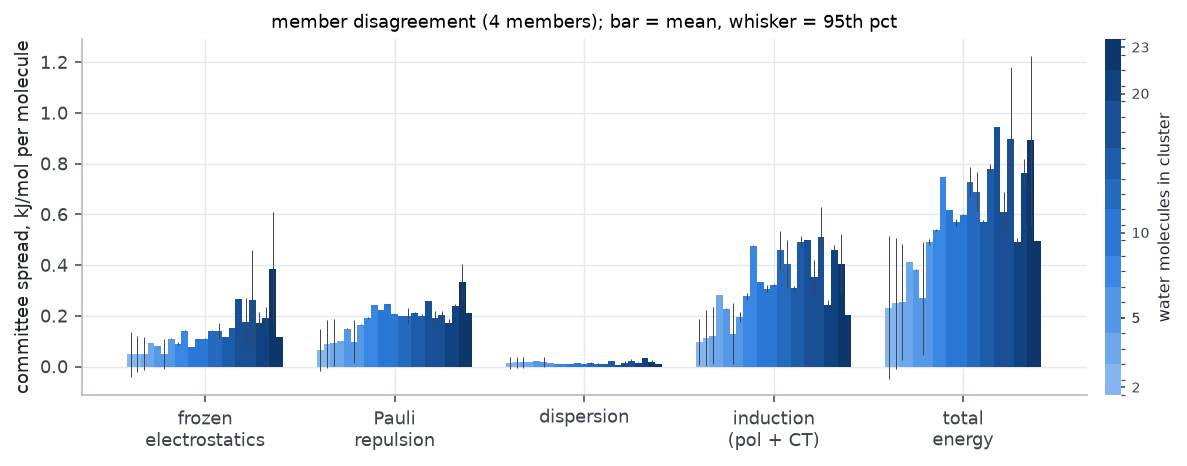

In [278]:
SPREAD_TERMS = ["elst", "pauli", "disp", "induction", "total"]
#: Axis labels for the panel; keyed separately from `ENERGY_TERMS` in the knobs cell,
#: which carries the *EDA label* of each channel rather than its display name.
ENERGY_TERMS_LABEL = [
    ("elst", "frozen\nelectrostatics"), ("pauli", "Pauli\nrepulsion"),
    ("disp", "dispersion"), ("induction", "induction\n(pol + CT)"), ("total", "total\nenergy"),
]



def collect_committee_spread(members, datasets, cfg, batch_size=BATCH_SIZE):
    """Per-frame committee mean and standard deviation of each channel, in kJ/mol."""
    rows = {term: {"mean": [], "sd": [], "tag": []} for term in SPREAD_TERMS}
    for tag, ds in datasets.items():
        indices = frame_indices(ds, cfg)
        for start in range(0, len(indices), batch_size):
            batch = ds.flat_batch(indices[start:start + batch_size])
            stacks = committee_interactions(members, batch)
            # Per molecule, like every other extensive quantity here: the spread of a sum over
            # 23 fragments is not comparable with the spread of a sum over 2.
            n_frag = to_np(fragments_per_frame(batch))
            for term, values in stacks.items():
                if term not in rows:
                    continue
                kj = values * KJMOL_PER_HARTREE / n_frag
                rows[term]["mean"].append(kj.mean(axis=0))
                # ddof=1 needs at least two members; a lone member has no spread at all.
                rows[term]["sd"].append(
                    kj.std(axis=0, ddof=1) if len(members) > 1 else np.zeros(kj.shape[1])
                )
                rows[term]["tag"].extend([tag] * kj.shape[1])
    return {
        term: {
            "mean": np.concatenate(d["mean"]),
            "sd": np.concatenate(d["sd"]),
            "tag": np.array(d["tag"]),
        }
        for term, d in rows.items() if d["mean"]
    }


def plot_committee_spread(spread, path=None):
    terms = [t for t in SPREAD_TERMS if t in spread]
    scale = size_scale(spread[terms[0]]["tag"])
    tags, _cmap, _norm = scale
    sizes = [cluster_size(t) for t in tags]

    fig, ax = plt.subplots(figsize=(1.55 * len(terms) + 1.6, 3.4))
    width = 0.82 / max(len(tags), 1)
    x = np.arange(len(terms), dtype=float)
    for k, tag in enumerate(tags):
        heights, errs = [], []
        for term in terms:
            sd = spread[term]["sd"][spread[term]["tag"] == tag]
            heights.append(float(sd.mean()) if sd.size else 0.0)
            # The mean understates the risk; the tail is what the loop actually selects on.
            errs.append(max(float(np.percentile(sd, 95)) - heights[-1], 0.0) if sd.size else 0.0)
        ax.bar(x + (k - 0.5 * (len(tags) - 1)) * width, heights, width,
               color=tag_color(tag, scale), lw=0, zorder=3,
               yerr=errs, error_kw={"lw": 0.5, "ecolor": "#3c4450", "capsize": 0})
    ax.set_xticks(x)
    ax.set_xticklabels([dict(ENERGY_TERMS_LABEL).get(t, t) for t in terms])
    ax.set_ylabel("committee spread, kJ/mol per molecule")
    ax.set_title(f"member disagreement ({len(committee)} members); bar = mean, whisker = 95th pct",
                 fontsize=9)
    add_size_colorbar(fig, ax, scale, pad=0.015, aspect=22)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


if len(committee) > 1:
    committee_spread = collect_committee_spread(committee, datasets, cfg)
    for term in (t for t in SPREAD_TERMS if t in committee_spread):
        sd = committee_spread[term]["sd"]
        print(f"{term:>10s}: spread mean {sd.mean():8.3f}  95th {np.percentile(sd, 95):8.3f}  "
              f"max {sd.max():8.3f} kJ/mol per molecule")
    plot_committee_spread(committee_spread, path=FIGDIR / f"{FIGPREFIX}_committee_spread.png")
else:
    committee_spread = None
    print("one member: no spread to plot (iteration-0 committee)")


In [279]:
def collect_energy_predictions(model, datasets, cfg, device, monomer_ref_energy, batch_size=BATCH_SIZE):
    rows = {term: {"ref": [], "pred": [], "tag": [], "n_frag": []}
            for term, _, _ in ENERGY_TERMS}
    for tag, ds in datasets.items():
        indices = frame_indices(ds, cfg)
        for start in range(0, len(indices), batch_size):
            batch = ds.flat_batch(indices[start:start + batch_size]).to(device)
            with torch.no_grad():
                out = model(batch)
            # Every term here is *extensive*: it is a sum over fragments or over inter-fragment
            # pairs, so a w23 frame carries an order of magnitude more of it than a dimer does.
            # Carrying the count lets the panels divide, which is what makes an error bar
            # comparable across the w2-w23 range this checkpoint was fitted on.
            frame_n_frag = fragments_per_frame(batch)

            for term, target, _label in ENERGY_TERMS:
                if term == "total":
                    n_frag = frame_n_frag
                    pred = out.energy - monomer_ref_energy * n_frag
                    ref = batch.energy - monomer_ref_energy * n_frag
                elif term == "onebody":
                    if batch.fragment_energy is None:
                        continue
                    pred = pool_fragments_to_frames(out.fragment_energy - monomer_ref_energy, batch)
                    ref = pool_fragments_to_frames(batch.fragment_energy - monomer_ref_energy, batch)
                else:
                    # `target` is a tuple: induction's label is the sum of two EDA columns.
                    # Skip the channel unless the model has it *and* every component of its
                    # label is on the batch -- an isolated-stage checkpoint has no `induction`
                    # in `out.interaction`, which is what drops the panel rather than an error.
                    if term not in out.interaction or batch.eda is None:
                        continue
                    if any(k not in batch.eda for k in target):
                        continue
                    pred = out.interaction[term]
                    ref = sum(batch.eda[k] for k in target)
                rows[term]["pred"].append(to_np(pred) * KJMOL_PER_HARTREE)
                rows[term]["ref"].append(to_np(ref) * KJMOL_PER_HARTREE)
                rows[term]["tag"].extend([tag] * len(pred))
                rows[term]["n_frag"].append(to_np(frame_n_frag))
    packed = {}
    for term, data in rows.items():
        if data["pred"]:
            packed[term] = {
                "pred": np.concatenate(data["pred"]),
                "ref": np.concatenate(data["ref"]),
                "tag": np.asarray(data["tag"]),
                "n_frag": np.concatenate(data["n_frag"]),
            }
    return packed


def per_molecule(d):
    """`(ref, pred)` divided by the fragment count, the scale these panels are read on."""
    n = d["n_frag"]
    return d["ref"] / n, d["pred"] / n


def metrics(ref, pred):
    err = pred - ref
    if len(ref) > 1 and np.std(ref) > 0 and np.std(pred) > 0:
        r2 = float(np.corrcoef(ref, pred)[0, 1] ** 2)
    else:
        r2 = np.nan
    return float(np.abs(err).mean()), float(np.sqrt(np.mean(err ** 2))), r2


energy = collect_energy_predictions(model, datasets, cfg, device, h2o_reference_energy)
# Both scales, because they answer different questions and the pooled one is the one that
# misleads: a per-fragment error that is flat in cluster size still grows linearly per frame,
# so `per frame` degrading from w2 to w23 is the expected arithmetic, not a worse fit.
print(f"{'term':<12}{'n':>8}{'MAE/frame':>12}{'MAE/mol':>11}{'RMSE/mol':>11}{'R2':>10}")
for term, _target, label in ENERGY_TERMS:
    if term not in energy:
        continue
    mae_f, _, _ = metrics(energy[term]["ref"], energy[term]["pred"])
    ref_m, pred_m = per_molecule(energy[term])
    mae, rmse, r2 = metrics(ref_m, pred_m)
    print(f"{term:<12}{len(energy[term]['ref']):>8}{mae_f:>12.4f}{mae:>11.4f}{rmse:>11.4f}"
          f"{r2:>10.5f}  {label}")


term               n   MAE/frame    MAE/mol   RMSE/mol        R2
onebody         9660      1.8878     0.5222     0.5908   0.99067  monomer deformation energy
elst            9660      5.1418     1.2851     1.5904   0.99722  frozen electrostatics
pauli           9660      1.0663     0.2745     0.3477   0.99968  Pauli repulsion
disp            9660      0.4438     0.1273     0.1630   0.99505  dispersion
induction       9660      0.7287     0.1792     0.2471   0.99816  induction (pol + CT)
total           9660      6.4771     1.6467     1.8711   0.98328  binding energy


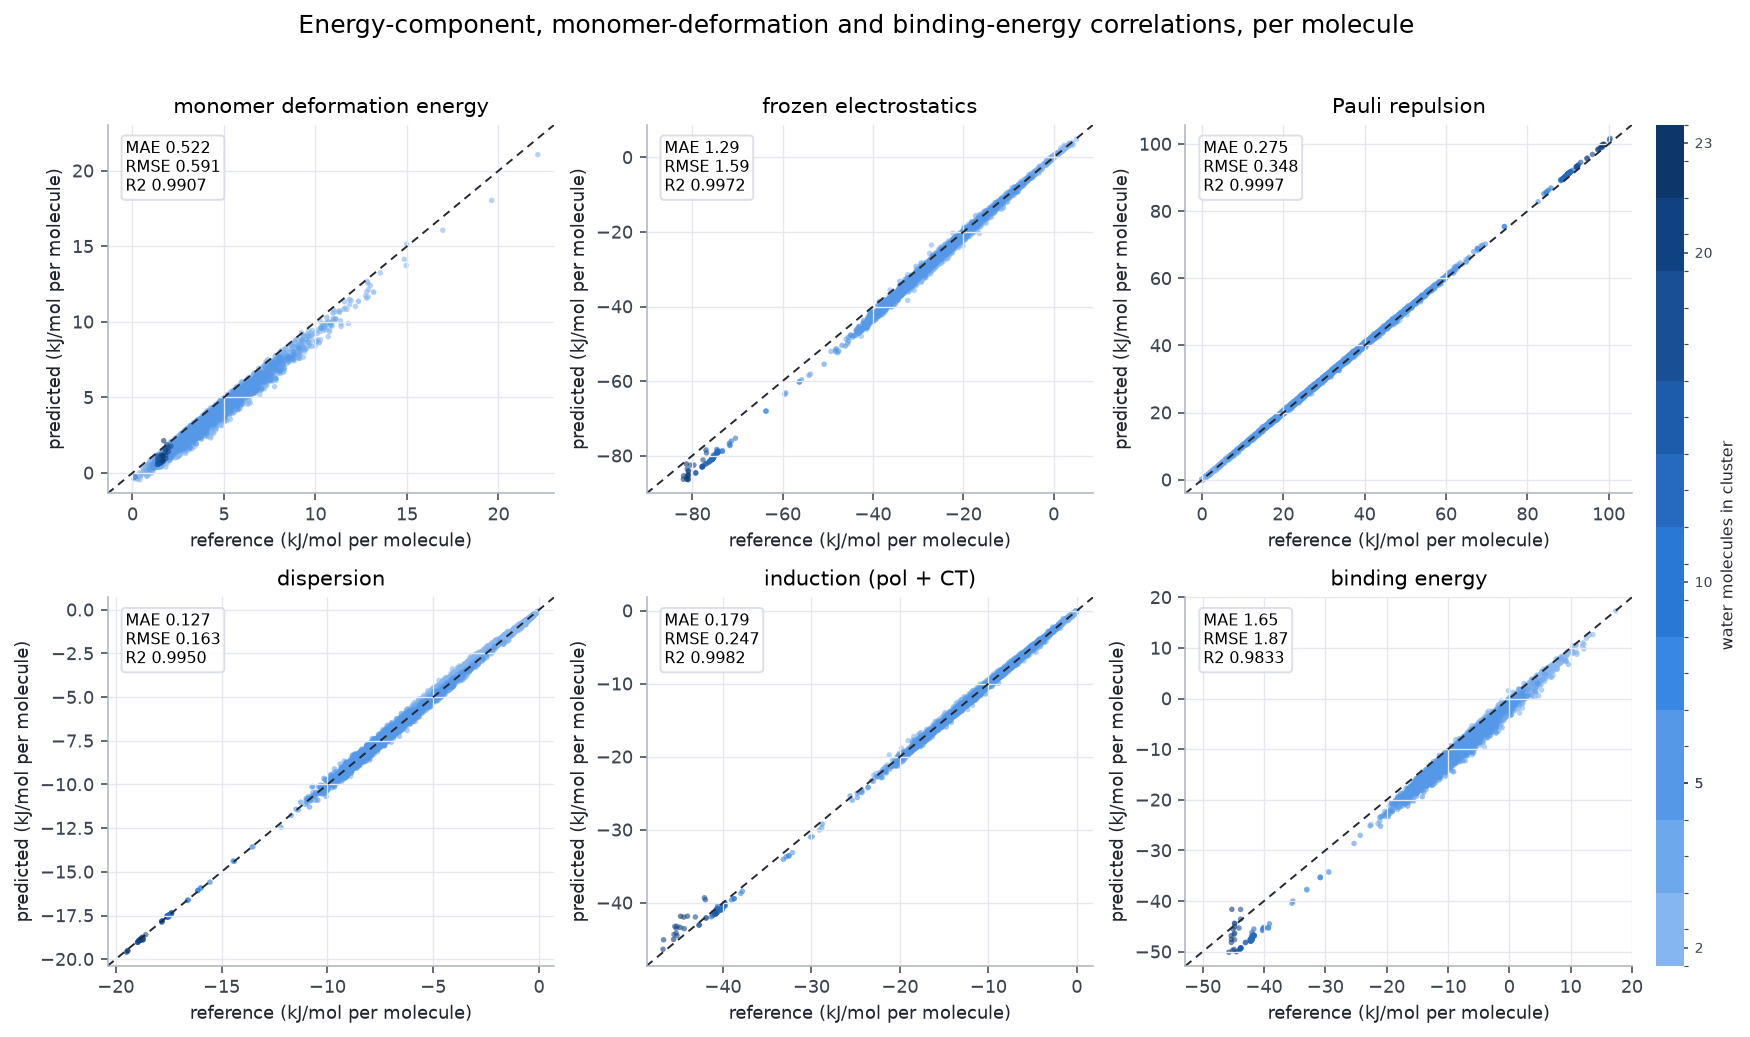

In [280]:
def plot_parity_grid(data, labels, *, title, unit, path=None, ncols=3, per_mol=True):
    """Parity per term, points coloured by cluster size.

    `per_mol` divides every term by the frame's fragment count. All of these are extensive --
    sums over fragments or over inter-fragment pairs -- so on the raw scale a w23 point sits an
    order of magnitude out along the diagonal from a dimer, and the panel becomes a plot of
    how big the clusters are rather than of how well the model does. Per molecule the whole
    w2-w23 range is on one comparable footing.
    """
    keys = [k for k, _ in labels if k in data]
    nrows = int(np.ceil(len(keys) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.1 * ncols, 3.6 * nrows), squeeze=False)
    for ax in axes.ravel():
        ax.set_visible(False)
    scale = size_scale(data[keys[0]]["tag"])
    shown = f"{unit} per molecule" if per_mol else unit
    for ax, key in zip(axes.ravel(), keys):
        ax.set_visible(True)
        d = data[key]
        tags = d.get("tag")
        ref, pred = (per_molecule(d) if per_mol and "n_frag" in d else (d["ref"], d["pred"]))
        lo = min(np.min(ref), np.min(pred))
        hi = max(np.max(ref), np.max(pred))
        pad = 0.04 * (hi - lo if hi > lo else 1.0)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="#242934", lw=1.0, ls=(0, (4, 3)))
        if tags is None:
            ax.scatter(ref, pred, s=8, alpha=0.65, lw=0, color="#276ef1")
        else:
            # Biggest last: the large clusters are a handful of frames against thousands of
            # dimers, and drawing them in tag order buries them.
            order = np.argsort([cluster_size(t) for t in tags], kind="stable")
            ax.scatter(ref[order], pred[order], s=8, alpha=0.6, lw=0,
                       color=[tag_color(t, scale) for t in tags[order]])
        mae, rmse, r2 = metrics(ref, pred)
        ax.text(0.04, 0.96, f"MAE {mae:.3g}\nRMSE {rmse:.3g}\nR2 {r2:.4f}",
                transform=ax.transAxes, ha="left", va="top", fontsize=8,
                bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
        ax.set_title(dict(labels)[key])
        ax.set_xlabel(f"reference ({shown})")
        ax.set_ylabel(f"predicted ({shown})")
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
    fig.suptitle(title, y=1.02, fontsize=13)
    fig.tight_layout()
    add_size_colorbar(fig, [ax for ax in axes.ravel() if ax.get_visible()], scale,
                      fraction=0.02, pad=0.015, aspect=30)
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig

energy_labels = [(term, label) for term, _target, label in ENERGY_TERMS]
fig = plot_parity_grid(
    energy,
    energy_labels,
    title="Energy-component, monomer-deformation and binding-energy correlations, per molecule",
    unit="kJ/mol",
    path=FIGDIR / f"{FIGPREFIX}_energy_correlations.png",
)
plt.show()


## Where the size-dependent offset comes from

The deformation-energy and binding-energy panels above are pooled **per frame**, so a
constant per-*fragment* error is drawn as `n_fragments` times itself: a pure constant looks
like a size-dependent offset. This section separates the two. It reports the one-body
residual per fragment, which is where the constant actually lives, and then replots the two
pooled panels with that single number removed.

Read it as: `bias` is the constant, `MAE - |bias|` is the geometry-dependent part that the
model genuinely gets wrong, and `n_frag * bias` is the offset the pooled plots show.

In the film model the one-body constant lives in the **learnable bonded tables** -- chiefly
the well depth `D`, since `fragment_energy = sum E0 - sum_bonds D + ...` near equilibrium --
so the fit can reach it directly and a residual constant here should be small. If it is not,
compare the `O-H table` line printed at the top against pyCMM: a table that refuses to move
while a constant bias persists means something else is pinning it (`bonded_variance_weight`
only penalizes the *feature-dependent* deviation, never the table).

In [281]:
def onebody_residual_by_fragment(model, datasets, cfg, device, batch_size=BATCH_SIZE):
    """Per-fragment `fragment_energy` residual, kept per fragment rather than per frame.

    `collect_energy_predictions` pools fragments to frames because that is the scale the
    binding energy lives on. That pooling is also what turns a constant into a slope, so this
    deliberately does not do it -- the per-fragment residual is the quantity a constant offset
    is constant in.
    """
    rows = {}
    for tag, ds in datasets.items():
        indices = frame_indices(ds, cfg)
        err, n_frag = [], []
        for start in range(0, len(indices), batch_size):
            batch = ds.flat_batch(indices[start:start + batch_size]).to(device)
            with torch.no_grad():
                out = model(batch)
            e = (out.fragment_energy - batch.fragment_energy) * KJMOL_PER_HARTREE
            err.append(to_np(e))
            n_frag.append(to_np(fragments_per_frame(batch)))
        rows[tag] = {"err": np.concatenate(err), "n_frag": np.concatenate(n_frag)}
    return rows


onebody_res = onebody_residual_by_fragment(model, datasets, cfg, device)
pooled = np.concatenate([d["err"] for d in onebody_res.values()])
BIAS = float(pooled.mean())

print("per-fragment one-body residual (kJ/mol)")
print(f"{'cluster':>8}{'n_frag':>8}{'bias':>10}{'MAE':>10}{'std':>10}{'frame offset':>14}")
for tag in sorted(onebody_res):
    d = onebody_res[tag]
    e, nf = d["err"], float(d["n_frag"][0])
    print(f"{tag:>8}{nf:>8.0f}{e.mean():>+10.4f}{np.abs(e).mean():>10.4f}"
          f"{e.std():>10.4f}{nf * e.mean():>+14.4f}")
print(f"\npooled over {len(pooled)} fragments: bias {BIAS:+.4f}  "
      f"MAE {np.abs(pooled).mean():.4f}  std {pooled.std():.4f}")
print(f"with the constant removed:      MAE {np.abs(pooled - BIAS).mean():.4f}  "
      f"RMSE {np.sqrt(((pooled - BIAS) ** 2).mean()):.4f}")


per-fragment one-body residual (kJ/mol)
 cluster  n_frag      bias       MAE       std  frame offset
     w10      10   -0.8205    0.8205    0.2201       -8.2050
     w11      11   -0.7990    0.7990    0.2201       -8.7894
     w12      12   -0.8044    0.8044    0.1728       -9.6529
     w13      13   -0.8080    0.8225    0.2566      -10.5037
     w14      14   -0.8064    0.8064    0.1816      -11.2889
     w16      16   -0.7956    0.7956    0.1546      -12.7291
     w17      17   -0.3327    1.1570    1.8436       -5.6556
     w18      18   -0.5794    0.8728    0.8815      -10.4297
     w19      19   -0.4235    1.1681    2.0917       -8.0456
      w2       2   -0.5166    0.5212    0.4079       -1.0333
     w20      20   -0.5744    0.9989    1.2996      -11.4886
     w21      21   -0.4122    1.2435    2.1362       -8.6552
     w22      22   -0.0484    1.3536    2.7069       -1.0644
     w23      23   -0.8169    0.8169    0.1873      -18.7894
      w3       3   -0.5255    0.5300    0.421

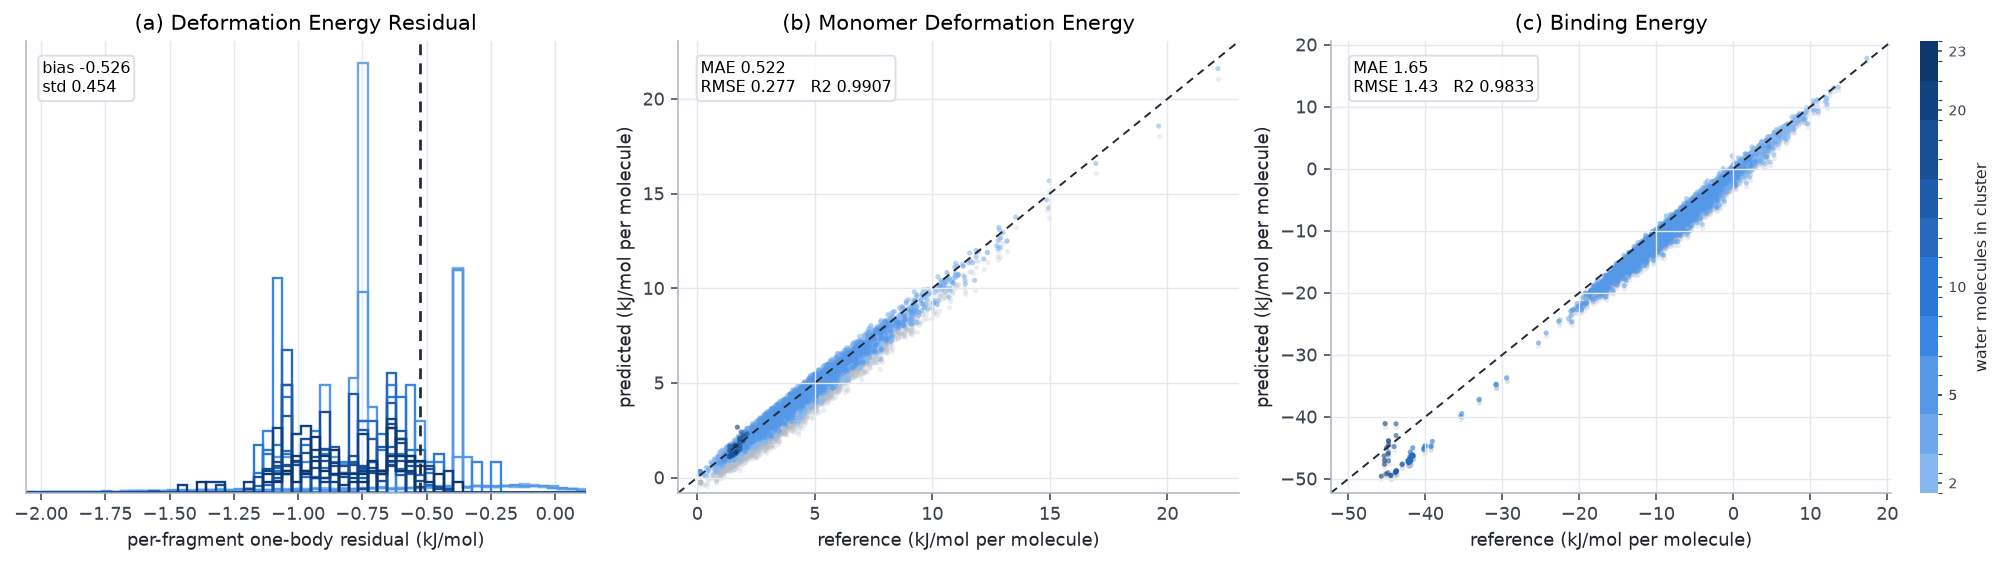

In [282]:
def plot_onebody_offset(onebody_res, energy, bias, path=None):
    """Left: the residual is a constant. Right/centre: the pooled panels with it removed."""
    tags = sorted(onebody_res, key=cluster_size)
    scale = size_scale(tags)
    fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.1))

    ax = axes[0]
    # Binned on a shared, percentile-clipped range. A per-tag `bins=40` over each tag's own
    # min/max draws every distribution at a different resolution, and on a well-fitted
    # checkpoint a handful of outliers stretch the range until the bulk is one spike.
    pooled_err = np.concatenate([onebody_res[t]["err"] for t in tags])
    span = np.percentile(pooled_err, [0.5, 99.5])
    bins = np.linspace(span[0], span[1], 60)
    for tag in tags:
        ax.hist(onebody_res[tag]["err"], bins=bins, density=True, histtype="step", lw=1.2,
                color=tag_color(tag, scale))
    ax.set_xlim(*span)
    ax.axvline(bias, color="#242934", lw=1.4, ls=(0, (4, 3)))
    # In axes coordinates, not at the line: the distribution is sharply peaked right where the
    # line falls, so anchoring the label to the data would drop it on top of the spike.
    ax.text(0.03, 0.96, f"bias {bias:+.3f}\nstd {np.concatenate([onebody_res[t]['err'] for t in tags]).std():.3f}",
            transform=ax.transAxes, ha="left", va="top", fontsize=8,
            bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
    ax.set_xlabel("per-fragment one-body residual (kJ/mol)")
    ax.set_yticks([])
    ax.set_title("(a) Deformation Energy Residual")

    # The pooled panels, before and after removing n_frag * bias. `energy` was collected with
    # the same frame ordering, so `n_frag` lines up term by term.
    for ax, term, label in ((axes[1], "onebody", "Monomer Deformation Energy"),
                            (axes[2], "total", "Binding Energy")):
        if term not in energy:
            ax.set_visible(False)
            continue
        d = energy[term]
        tag_arr = d["tag"]
        # Per molecule, which is what makes the correction a *constant*: the pooled residual is
        # `n_frag * bias`, so dividing by `n_frag` leaves a single number to subtract whatever
        # the cluster size. That is the whole claim of this figure, drawn on the scale where it
        # is visible rather than on the one where it looks like a slope.
        ref, pred = per_molecule(d)
        corrected = pred - bias
        lo = min(ref.min(), corrected.min())
        hi = max(ref.max(), corrected.max())
        pad = 0.04 * (hi - lo if hi > lo else 1.0)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="#242934", lw=1.0,
                ls=(0, (4, 3)))
        order = np.argsort([cluster_size(t) for t in tag_arr], kind="stable")
        ax.scatter(ref[order], pred[order], s=7, alpha=0.25, lw=0, color="#b6bcc7")
        ax.scatter(ref[order], corrected[order], s=7, alpha=0.6, lw=0,
                   color=[tag_color(t, scale) for t in tag_arr[order]])
        mae0, _, _ = metrics(ref, pred)
        mae1, rmse1, r21 = metrics(ref, corrected)
        ax.text(0.04, 0.96,
                f"MAE {mae0:.3g}\n"
                f"RMSE {rmse1:.3g}   R2 {r21:.4f}",
                transform=ax.transAxes, ha="left", va="top", fontsize=8,
                bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d6dae3",
                      "alpha": 0.85})
        ax.set_xlabel("reference (kJ/mol per molecule)")
        ax.set_ylabel("predicted (kJ/mol per molecule)")
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_title(f"({'b' if term == 'onebody' else 'c'}) {label}")

    fig.tight_layout()
    add_size_colorbar(fig, list(axes), scale, fraction=0.02, pad=0.015, aspect=26)
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


fig = plot_onebody_offset(onebody_res, energy, BIAS,
                          path=FIGDIR / f"{FIGPREFIX}_onebody_offset.png")
plt.show()


## Isolated parameters versus the environment

Every channel here is `gate * e_classical`, with no neural term added on top. Each parameter
exists at two values: `theta_0`, generated from the internal feature block alone, and `theta`,
with the environment and cross blocks live. Running a batch twice -- once inside
`environment_off`, which zeroes the env/cross embedders *and* suppresses the bonded-delta gate
-- splits each channel's energy the same way. `iso` is what the model would produce with every
fragment treated as isolated; `env` is what only appears because of what is nearby.

That is the effective many-body content, and it is where it *should* be. `eda_cls_elec` is the
Coulomb interaction between superimposed frozen monomer densities, which is rigorously
pairwise; in the film model its `env` bar is zero **by construction twice over** -- the
permanent multipoles have no environment path at all, and the penetration parameters read
per-element tables. The modified Pauli term and the dispersion are not pairwise, and a
quenched `C6` is what that content looks like here.

**The one-body panel is a live check, not a plot.** `fragment_energy` and the permanent
multipoles must be bitwise identical between the two runs. The cell asserts both.

Induction keeps a third number. Its bonded contribution is `E_bonded(theta) -
E_bonded(theta_0)` -- the Morse/angle parameters re-read in the medium, the learned analogue
of pyCMM's field-dependent Morse -- and it is a route to the label needing no charge to move
and no multipole to relax. In an earlier two-level model the parameter half was 100% of the
`ct` channel while every printed metric looked healthy. It is reported, not penalised: some of
it is real charge transfer, and the size is what says how much.

Everything is normalised **per fragment** so the four cluster sizes are directly comparable.
The one-body bucket gets its own axis because it is two orders of magnitude larger; `E_0`, the
fixed atomic reference, is left out since it is neither fitted nor environment-dependent.

In [283]:
SPLIT_TERMS = [
    ("elst", "frozen\nelectrostatics"),
    ("pauli", "Pauli\nrepulsion"),
    ("disp", "dispersion"),
    ("induction", "induction\n(pol + CT)"),
]
ISO_COLOR = "#3c4450"
ENV_COLOR = "#e07a3f"


def collect_isolated_vs_env(model, datasets, cfg, device, batch_size=BATCH_SIZE):
    """Per-fragment isolated and environment halves of every channel.

    Two forwards per batch: one as trained, one inside `environment_off`. The difference is the
    energy that exists only because of the surroundings.

    The one-body sector is asserted rather than plotted -- `fragment_energy` reads `theta_0`
    and the permanent multipoles read the internal block only, so the two runs must agree
    bitwise on both. If either assertion ever fires, the routing has a leak and every isolated
    number in the notebook is meaningless. The iso run's own `env_shift` is asserted to be an
    exact zero for the same reason: it is what says `environment_off` actually reached every
    parameter family.
    """
    rows = {"tag": []}
    for tag, ds in datasets.items():
        indices = frame_indices(ds, cfg)
        for start in range(0, len(indices), batch_size):
            batch = ds.flat_batch(indices[start:start + batch_size]).to(device)
            with torch.no_grad():
                out = model(batch)
                with environment_off(model):
                    iso = model(batch)
            n_frag = fragments_per_frame(batch)

            def per_fragment(x):
                return to_np(x / n_frag) * KJMOL_PER_HARTREE

            assert torch.equal(out.fragment_energy, iso.fragment_energy), (
                "fragment_energy moved when the environment was switched off -- the one-body "
                "sector is reading the environment somewhere it must not"
            )
            assert torch.equal(out.parameters.q_perm, iso.parameters.q_perm), (
                "the permanent charges moved when the environment was switched off -- the "
                "permanent/polarization separation has a leak"
            )
            for name, shift in iso.env_shift.items():
                assert float(shift.abs().max()) == 0.0, (
                    f"environment_off left a live env path in {name}; the split below would "
                    f"be measuring the wrong thing"
                )

            for name in out.interaction:
                rows.setdefault(f"{name}|iso", []).append(per_fragment(iso.interaction[name]))
                rows.setdefault(f"{name}|env", []).append(
                    per_fragment(out.interaction[name] - iso.interaction[name])
                )

            # The bonded-parameter half of induction: `E_bonded` at `theta` minus at
            # `theta_0`, exactly the difference the model books into the induction channel.
            if out.energy_bonded_env is not None:
                swap = pool_fragments_to_frames(
                    out.energy_bonded_env - out.energy_bonded, batch
                )
                rows.setdefault("induction|swap", []).append(per_fragment(swap))

            rows.setdefault("onebody|intra", []).append(
                per_fragment(pool_fragments_to_frames(out.energy_intra, batch)))
            rows.setdefault("onebody|bonded", []).append(
                per_fragment(pool_fragments_to_frames(out.energy_bonded, batch)))
            rows["tag"].extend([tag] * batch.n_systems)
    return {k: (np.asarray(v) if k == "tag" else np.concatenate(v)) for k, v in rows.items()}


split = collect_isolated_vs_env(model, datasets, cfg, device)
print(f"{'component':<12}{'isolated':>12}{'environment':>13}{'env share':>11}"
      f"{'bonded half':>13}{'/env':>9}   (kJ/mol per fragment)")
for key, _label in SPLIT_TERMS:
    if f"{key}|iso" not in split:
        continue
    iso, env = split[f"{key}|iso"], split[f"{key}|env"]
    share = np.abs(env).mean() / max(np.abs(iso).mean() + np.abs(env).mean(), 1e-30)
    swap = split.get(f"{key}|swap")
    if swap is None:
        tail = f"{'-':>13}{'-':>9}"
    else:
        frac = np.abs(swap).mean() / max(np.abs(env).mean(), 1e-30)
        tail = f"{swap.mean():>+13.4f}{100 * frac:>8.1f}%"
    print(f"{key:<12}{iso.mean():>+12.4f}{env.mean():>+13.4f}{100 * share:>10.1f}%{tail}")
print(f"\n{'onebody':<12}"
      f"intra classical {split['onebody|intra'].mean():>+8.3f}   "
      f"bonded (Morse + angle) {split['onebody|bonded'].mean():>+10.3f}")
print("environment share of the one-body sector: 0.0% exactly, by construction (asserted above)")


component       isolated  environment  env share  bonded half     /env   (kJ/mol per fragment)
elst            -23.1408      +0.0000       0.0%            -        -
pauli           +27.0207      +0.7640       3.4%            -        -
disp             -5.8560      +0.0516       0.9%            -        -
induction        -3.1726      -6.1216      65.9%      -6.0394    98.7%

onebody     intra classical   -0.226   bonded (Morse + angle)   -962.099
environment share of the one-body sector: 0.0% exactly, by construction (asserted above)


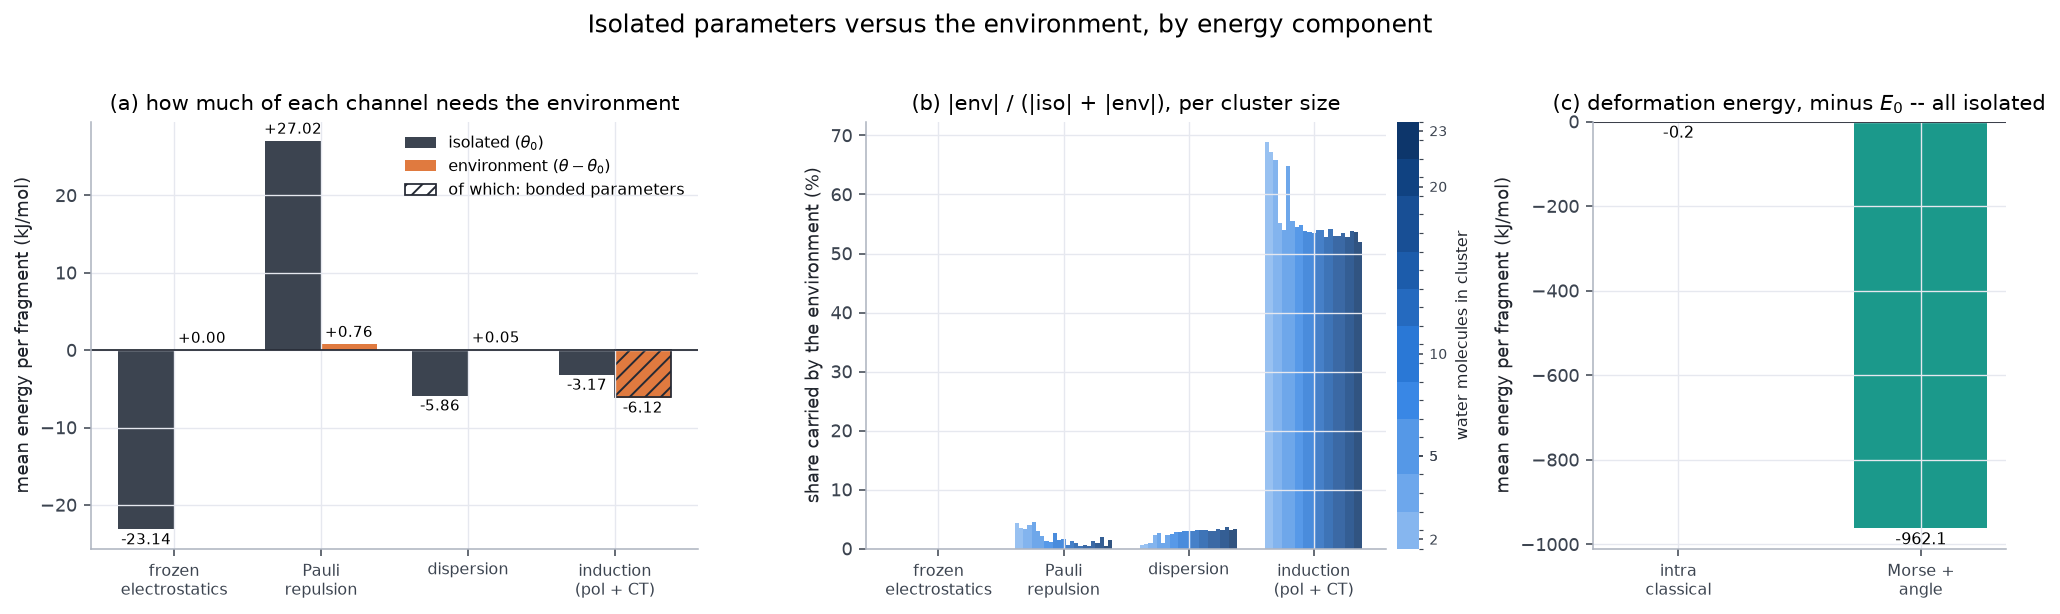

In [284]:
def plot_isolated_vs_env(split, path=None):
    tags = sorted(set(split["tag"]), key=cluster_size)
    scale = size_scale(tags)
    terms = [(k, l) for k, l in SPLIT_TERMS if f"{k}|iso" in split]
    x = np.arange(len(terms))
    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2),
                             gridspec_kw={"width_ratios": [1.25, 1.15, 0.85]})

    ax = axes[0]
    width = 0.38
    iso = [split[f"{k}|iso"].mean() for k, _ in terms]
    env = [split[f"{k}|env"].mean() for k, _ in terms]
    ax.bar(x - width / 2, iso, width, color=ISO_COLOR, label=r"isolated ($\theta_0$)")
    ax.bar(x + width / 2, env, width, color=ENV_COLOR, label=r"environment ($\theta-\theta_0$)")
    # Drawn over the environment bar rather than beside it, because it is a *part* of it: the
    # share carried by the bonded parameters rather than by a relaxation of the multipoles.
    swap_drawn = False
    for xi, (k, _label) in enumerate(terms):
        if f"{k}|swap" not in split:
            continue
        ax.bar(xi + width / 2, split[f"{k}|swap"].mean(), width, facecolor="none",
               edgecolor="#242934", hatch="///", lw=0.9,
               label=None if swap_drawn else "of which: bonded parameters")
        swap_drawn = True
    for xi, (a, b) in enumerate(zip(iso, env)):
        for dx, v in ((-width / 2, a), (width / 2, b)):
            ax.annotate(f"{v:+.2f}", (xi + dx, v), ha="center", fontsize=7.5,
                        va="bottom" if v >= 0 else "top",
                        xytext=(0, 2 if v >= 0 else -2), textcoords="offset points")
    ax.axhline(0.0, color="#242934", lw=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels([l for _, l in terms], fontsize=8)
    ax.set_ylabel("mean energy per fragment (kJ/mol)")
    ax.set_title("(a) how much of each channel needs the environment")
    ax.legend(frameon=False, fontsize=8)

    ax = axes[1]
    width = 0.78 / max(1, len(tags))
    for j, tag in enumerate(tags):
        m = split["tag"] == tag
        share = []
        for k, _ in terms:
            a = np.abs(split[f"{k}|iso"][m]).mean()
            b = np.abs(split[f"{k}|env"][m]).mean()
            share.append(100.0 * b / max(a + b, 1e-30))
        ax.bar(x + (j - (len(tags) - 1) / 2) * width, share, width,
               color=tag_color(tag, scale), alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([l for _, l in terms], fontsize=8)
    ax.set_ylabel("share carried by the environment (%)")
    # A share that *grows* with cluster size is the signature of real many-body physics; one
    # that is already large on w2, where there is none, is the environment sector doing
    # two-body work the isolated parameters should be doing.
    ax.set_title("(b) |env| / (|iso| + |env|), per cluster size")
    add_size_colorbar(fig, ax, scale, fraction=0.05, pad=0.02, aspect=20)

    ax = axes[2]
    pieces = [("onebody|intra", "intra\nclassical", "#7f8794"),
              ("onebody|bonded", "Morse +\nangle", "#1b998b")]
    values = [split[k].mean() for k, _, _ in pieces]
    ax.bar(np.arange(len(pieces)), values, 0.55, color=[c for _, _, c in pieces])
    for i, v in enumerate(values):
        ax.annotate(f"{v:+.1f}", (i, v), ha="center", fontsize=8,
                    va="bottom" if v >= 0 else "top",
                    xytext=(0, 2 if v >= 0 else -2), textcoords="offset points")
    ax.axhline(0.0, color="#242934", lw=0.9)
    ax.set_xticks(np.arange(len(pieces)))
    ax.set_xticklabels([l for _, l, _ in pieces], fontsize=8)
    ax.set_ylabel("mean energy per fragment (kJ/mol)")
    # No environment bar here, and that is the point: every term in this panel reads theta_0,
    # and there is no frozen-solve E_internal any more -- the bonded terms carry that energy.
    ax.set_title("(c) deformation energy, minus $E_0$ -- all isolated")

    fig.suptitle("Isolated parameters versus the environment, by energy component",
                 y=1.03, fontsize=13)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


fig = plot_isolated_vs_env(split, path=FIGDIR / f"{FIGPREFIX}_isolated_vs_environment.png")
plt.show()


In [285]:
def collect_response_properties(model, anchor, device, batch_size=BATCH_SIZE):
    if anchor is None:
        raise ValueError("cfg.data.monomer_path is not set, so no polarizability/multipole anchor is available")
    chunks = {
        "polarizability": {"ref": [], "pred": [], "component": []},
        "dipole": {"ref": [], "pred": [], "component": []},
        "quadrupole": {"ref": [], "pred": [], "component": []},
    }
    tri = np.triu_indices(3)
    alpha_labels = np.array(["xx", "xy", "xz", "yy", "yz", "zz"])
    dip_labels = np.array(["x", "y", "z"])
    quad_labels = alpha_labels

    for start in range(0, len(anchor), batch_size):
        batch = anchor.flat_batch(range(start, min(start + batch_size, len(anchor)))).to(device)
        with torch.no_grad():
            # `with_induction=False` is an optimization here, not a correctness need: the
            # film model's isolated-fragment induction is exactly zero by construction (the
            # coupled solve's drive vanishes at the permanent multipoles), so this only skips
            # a solve whose answer is known. `out.charges/mu/quad_s` ARE the permanent
            # multipoles -- there is no frozen solve for them to come off.
            out = model(batch, with_polarizability=True, with_induction=False)
        if out.polarizability is not None and batch.polarizability is not None:
            pred_a = to_np(out.polarizability)[:, tri[0], tri[1]] / (BOHR_ANG ** 2)
            ref_a = to_np(batch.polarizability)[:, tri[0], tri[1]] / (BOHR_ANG ** 2)
            chunks["polarizability"]["pred"].append(pred_a.ravel())
            chunks["polarizability"]["ref"].append(ref_a.ravel())
            chunks["polarizability"]["component"].extend(np.tile(alpha_labels, pred_a.shape[0]))

        if batch.fragment_dipole is not None and batch.fragment_second_moment is not None:
            quad_c = None if out.quad_s is None else spherical_to_cartesian_quadrupole(out.quad_s)
            frag_q = batch.fragment_charge if batch.fragment_charge is not None else batch.positions.new_zeros(batch.n_fragments)
            pred_d, pred_q = fragment_multipoles(
                out.charges, batch.positions, batch.atomic_numbers, batch.fragment_idx,
                batch.n_fragments, frag_q, out.mu, quad_c,
            )
            ref_d, ref_q = reference_multipoles(
                batch.fragment_dipole, batch.fragment_second_moment, batch.positions,
                batch.atomic_numbers, batch.fragment_idx, batch.n_fragments, frag_q,
            )
            pred_d, ref_d = to_np(pred_d), to_np(ref_d)
            pred_q, ref_q = to_np(pred_q)[:, tri[0], tri[1]], to_np(ref_q)[:, tri[0], tri[1]]
            chunks["dipole"]["pred"].append(pred_d.ravel())
            chunks["dipole"]["ref"].append(ref_d.ravel())
            chunks["dipole"]["component"].extend(np.tile(dip_labels, pred_d.shape[0]))
            chunks["quadrupole"]["pred"].append(pred_q.ravel())
            chunks["quadrupole"]["ref"].append(ref_q.ravel())
            chunks["quadrupole"]["component"].extend(np.tile(quad_labels, pred_q.shape[0]))

    packed = {}
    for key, data in chunks.items():
        if data["pred"]:
            packed[key] = {
                "pred": np.concatenate(data["pred"]),
                "ref": np.concatenate(data["ref"]),
                "component": np.asarray(data["component"]),
            }
    return packed


properties = collect_response_properties(model, anchor, device) if anchor is not None else {}
for key, d in properties.items():
    mae, rmse, r2 = metrics(d["ref"], d["pred"])
    print(f"{key:<16} n={len(d['ref']):<6} MAE={mae:.5g} RMSE={rmse:.5g} R2={r2:.5f}")


polarizability   n=2994   MAE=0.098934 RMSE=0.17906 R2=0.99870
dipole           n=1497   MAE=0.011705 RMSE=0.017189 R2=0.99833
quadrupole       n=2994   MAE=0.031272 RMSE=0.049935 R2=0.99912


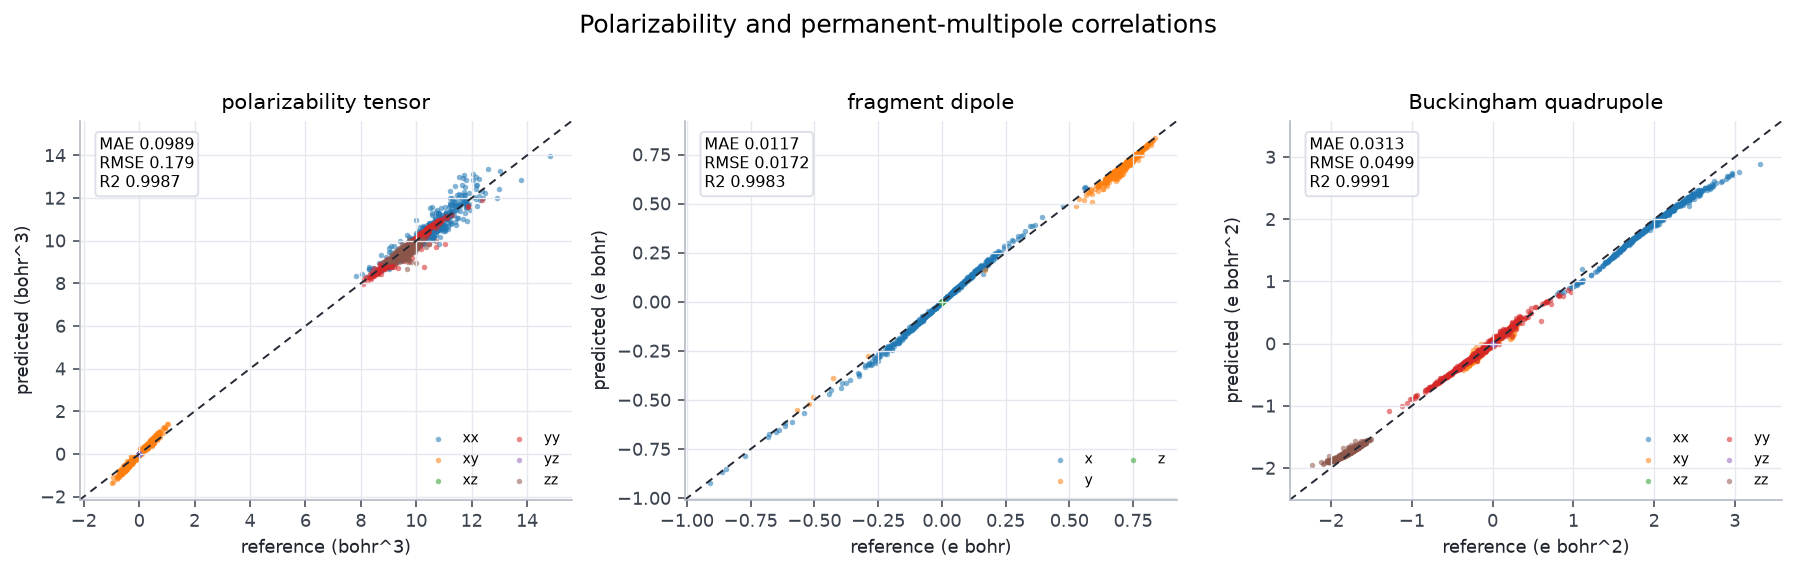

In [286]:
def plot_property_correlations(properties, path=None):
    labels = {
        "polarizability": ("polarizability tensor", "bohr^3"),
        "dipole": ("fragment dipole", "e bohr"),
        "quadrupole": ("Buckingham quadrupole", "e bohr^2"),
    }
    keys = [k for k in labels if k in properties]
    fig, axes = plt.subplots(1, len(keys), figsize=(4.3 * len(keys), 3.9), squeeze=False)
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    for ax, key in zip(axes.ravel(), keys):
        d = properties[key]
        ref, pred, comp = d["ref"], d["pred"], d["component"]
        lo = min(ref.min(), pred.min())
        hi = max(ref.max(), pred.max())
        pad = 0.05 * (hi - lo if hi > lo else 1.0)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="#242934", lw=1, ls=(0, (4, 3)))
        for i, c in enumerate(sorted(set(comp))):
            m = comp == c
            ax.scatter(ref[m], pred[m], s=8, alpha=0.55, lw=0, color=colors[i % len(colors)], label=c)
        mae, rmse, r2 = metrics(ref, pred)
        ax.text(0.04, 0.96, f"MAE {mae:.3g}\nRMSE {rmse:.3g}\nR2 {r2:.4f}",
                transform=ax.transAxes, ha="left", va="top", fontsize=8,
                bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
        ax.set_title(labels[key][0])
        ax.set_xlabel(f"reference ({labels[key][1]})")
        ax.set_ylabel(f"predicted ({labels[key][1]})")
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.legend(frameon=False, fontsize=7, ncol=2)
    fig.suptitle("Polarizability and permanent-multipole correlations", y=1.03, fontsize=13)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig

if properties:
    fig = plot_property_correlations(properties, path=FIGDIR / f"{FIGPREFIX}_response_property_correlations.png")
    plt.show()


## The generated parameters, at both evaluations

The film forward already carries every parameter at both evaluations (`FilmParameters`), so
nothing here re-runs a head: `theta_0` is the starred field, `theta` the unstarred one, and
their gap is the environment dependence -- the same per-quantity numbers the training log's
`env_*` columns report, here resolved per atom / bond / angle / channel instead of averaged.

What is deliberately **not** plotted, unlike the v4 notebook: the per-element tables. `r0`
(all three channels), the penetration `Z`/`b`, and the damping exponents `b_disp`/`b_pauli`
are element-indexed lookups in this model -- one number per element by design, so a
"distribution" of them is a vertical line and plotting sixteen vertical lines was noise.
Their values print below instead.

What is new, because the model is new:

- **the bonded Morse/angle parameters** `r_eq`, `D`, `k` (and the derived `beta`), `theta_eq`,
  `k_theta` -- per bond/angle, with the pyCMM water constants as reference lines. Their
  `theta - theta_0` gap is the bonded half of induction; their `theta_0` spread around the
  table is what `bonded_variance_weight` disciplines.
- **the response family**: `eta` and the atomic polarizability (isotropic part), now genuinely
  dual-valued -- the environment conditions how a fragment responds, which is where the
  many-body polarization physics lives in this model.
- **the SQE compliance**, per intra-fragment channel, split by endpoint pair (O-H against
  H-H): the learned bond topology of the charge flow.
- the **permanent multipoles** `q`, `|mu|`, `|Theta|` -- single-valued *by architecture* (no
  environment path exists), drawn filled only.

In [287]:
def _bond_kind(z_i, z_j):
    pair = sorted([int(z_i), int(z_j)])
    return "-".join(ELEMENT.get(z, str(z)) for z in pair)


def hydrogen_bond_labels(batch, max_distance=HBOND_DISTANCE, min_angle=HBOND_ANGLE):
    """Per-atom hydrogen-bond count, from the same geometric descriptor the Badger figure uses.

    `rsfff.md.film_driver.hydrogen_bonds` classifies each intramolecular O-H as donating when an
    oxygen on *another* fragment sits within `max_distance` of the H at an O-H...O angle above
    `min_angle`. Projected onto atoms that is 0/1 for a hydrogen, and for an oxygen the number
    of hydrogens from other fragments that donate *to it* -- a count, not a bit, and usually
    1 or 2 but not capped at 2.

    Frames are unpacked one at a time because the descriptor is per structure, and
    `fragment_idx` comes off the batch rather than being re-derived from distances, so the O-H
    bonds are the same topology the model itself used.
    """
    pos, z = to_np(batch.positions), to_np(batch.atomic_numbers)
    frag, frame = to_np(batch.fragment_idx), to_np(batch.batch_idx)
    counts = np.zeros(len(z), dtype=np.int64)
    for f in range(batch.n_systems):
        atoms_f = np.flatnonzero(frame == f)
        local_frag = frag[atoms_f] - frag[atoms_f].min()
        bonds = oh_bond_list(local_frag, z[atoms_f])
        d = hydrogen_bonds(pos[atoms_f], bonds, local_frag, z[atoms_f],
                           max_distance=max_distance, min_angle=min_angle)
        donating = d["is_donor"]
        counts[atoms_f[bonds[donating, 1]]] = 1
        np.add.at(counts, atoms_f[d["acceptor"][donating]], 1)
    return counts


def collect_film_parameters(model, datasets, device, n_frames=PARAMETER_FRAMES_PER_CLUSTER,
                            batch_size=BATCH_SIZE):
    """Every varying generated parameter at both evaluations, straight off the forward.

    Four tables, one per index set: atoms, bonds, angles, SQE channels. Keys with an `_iso`
    twin are dual-valued; the permanent multipoles have no twin because no env-dressed
    evaluation of them exists.
    """
    atoms = {}
    bonds = {}
    angles = {}
    channels = {}

    def push(store, **kv):
        for k, v in kv.items():
            store.setdefault(k, []).append(v)

    for tag, ds in datasets.items():
        take = min(n_frames, len(ds))
        for start in range(0, take, batch_size):
            batch = ds.flat_batch(range(start, min(start + batch_size, take))).to(device)
            with torch.no_grad():
                out = model(batch)
            p = out.parameters
            z = to_np(batch.atomic_numbers)

            def iso_trace(alpha):
                return to_np(torch.diagonal(alpha, dim1=-2, dim2=-1).mean(-1))

            push(
                atoms,
                tag=np.repeat(tag, len(z)), Z=z,
                q_perm=to_np(p.q_perm),
                mu_perm=to_np(p.mu_perm.norm(dim=-1)),
                quad_perm=to_np(p.quad_perm.norm(dim=-1)),
                eta=to_np(p.response.eta), eta_iso=to_np(p.response0.eta),
                alpha_iso_part=iso_trace(p.response.alpha),
                alpha_iso_part_iso=iso_trace(p.response0.alpha),
                c6=to_np(p.disp[0]), c6_iso=to_np(p.disp0[0]),
                q_pauli=to_np(p.pauli[0]), q_pauli_iso=to_np(p.pauli0[0]),
                mu_pauli=to_np(p.pauli[2].norm(dim=-1)),
                mu_pauli_iso=to_np(p.pauli0[2].norm(dim=-1)),
                quad_pauli=to_np(p.pauli[3].norm(dim=-1)),
                quad_pauli_iso=to_np(p.pauli0[3].norm(dim=-1)),
                a_env=to_np(out.a_env), gate=to_np(p.gate),
                env_norm=to_np(out.env_norm),
                hb_count=hydrogen_bond_labels(batch),
            )

            topo = out.topology
            def beta(b):
                return to_np(torch.sqrt(b.k / (2.0 * b.d)))
            push(
                bonds,
                tag=np.repeat(tag, topo.bond_index.shape[1]),
                kind=np.array([
                    _bond_kind(z[i], z[j])
                    for i, j in zip(*[to_np(t) for t in topo.bond_index])
                ]),
                r_eq=to_np(p.bonded.r_eq) * BOHR_ANG,
                r_eq_iso=to_np(p.bonded0.r_eq) * BOHR_ANG,
                d=to_np(p.bonded.d), d_iso=to_np(p.bonded0.d),
                k=to_np(p.bonded.k), k_iso=to_np(p.bonded0.k),
                beta=beta(p.bonded), beta_iso=beta(p.bonded0),
            )
            push(
                angles,
                tag=np.repeat(tag, topo.angle_index.shape[1]),
                theta_eq=np.degrees(to_np(p.bonded.cos_theta_eq.clamp(-1, 1).arccos())),
                theta_eq_iso=np.degrees(to_np(p.bonded0.cos_theta_eq.clamp(-1, 1).arccos())),
                k_theta=to_np(p.bonded.k_theta), k_theta_iso=to_np(p.bonded0.k_theta),
            )

            # The compliance rows align with the model's own channel graph: the complete
            # intra-fragment enumeration (union_channels at cutoff 0 *is* this list).
            ch, _ = intra_fragment_channels(batch.fragment_idx)
            push(
                channels,
                tag=np.repeat(tag, ch.shape[1]),
                kind=np.array([
                    _bond_kind(z[i], z[j]) for i, j in zip(*[to_np(t) for t in ch])
                ]),
                s=to_np(p.response.compliance),
                s_iso=to_np(p.response0.compliance),
            )

    pack = lambda d: {k: np.concatenate(v) for k, v in d.items()}
    return pack(atoms), pack(bonds), pack(angles), pack(channels)


atoms, bonds, angles, channels = collect_film_parameters(model, datasets, device)
print(f"parameter rows: {len(atoms['Z'])} atoms, {len(bonds['r_eq'])} bonds, "
      f"{len(angles['theta_eq'])} angles, {len(channels['s'])} channels")

# The static per-element tables, printed rather than plotted: one number each by design.
species_z = sorted(int(z) for z in state["neighbor_types"])   # species index order
species_idx = torch.arange(len(species_z))
r0_all, alpha_all = model.range_heads(torch.zeros(len(species_z), 0), species_idx)
def _per_element(table):
    return ", ".join(f"{ELEMENT.get(z, z)} {float(table[i]):.3f}"
                     for i, z in enumerate(species_z))
print("\nstatic per-element tables (not plotted):")
for name in r0_all:
    print(f"  r0_{name:<6} {_per_element(r0_all[name])}  A    "
          f"alpha {float(alpha_all[name]):.1f} 1/A")
rh = model.network.response_heads
print(f"  {'Z_pen':<9} {_per_element((rh.log_z_prior + rh.d_log_z).exp())}")
print(f"  {'b_pen':<9} {_per_element((rh.log_b_prior + rh.d_log_b).exp())}")

print(f"\n{'parameter':<12}{'index':>8}{'theta_0':>12}{'theta':>12}{'mean |shift|':>14}")
for store, key, idx in ((atoms, "eta", "atom"), (atoms, "c6", "atom"),
                        (atoms, "q_pauli", "atom"), (bonds, "r_eq", "bond"),
                        (bonds, "d", "bond"), (bonds, "k", "bond"),
                        (angles, "k_theta", "angle"), (channels, "s", "channel")):
    a, b = store[f"{key}_iso"], store[key]
    print(f"{key:<12}{idx:>8}{a.mean():>12.4g}{b.mean():>12.4g}{np.abs(b - a).mean():>14.5g}")


parameter rows: 8376 atoms, 5584 bonds, 2792 angles, 8376 channels

static per-element tables (not plotted):
  r0_elst   H 1.581, O 0.944  A    alpha 36.3 1/A
  r0_pauli  H 1.568, O 0.953  A    alpha 36.2 1/A
  r0_disp   H 1.553, O 0.972  A    alpha 36.2 1/A
  Z_pen     H 0.956, O 3.593
  b_pen     H 2.268, O 2.184

parameter      index     theta_0       theta  mean |shift|
eta             atom      0.3107      0.3168     0.0067449
c6              atom       15.49       15.21       0.28586
q_pauli         atom       2.397        2.39     0.0076103
r_eq            bond      0.9638      0.9685     0.0056819
d               bond      0.1836      0.1859     0.0023132
k               bond       0.535      0.5256      0.038198
k_theta        angle      0.1718      0.1688     0.0034579
s            channel       2.284       3.034       0.76878


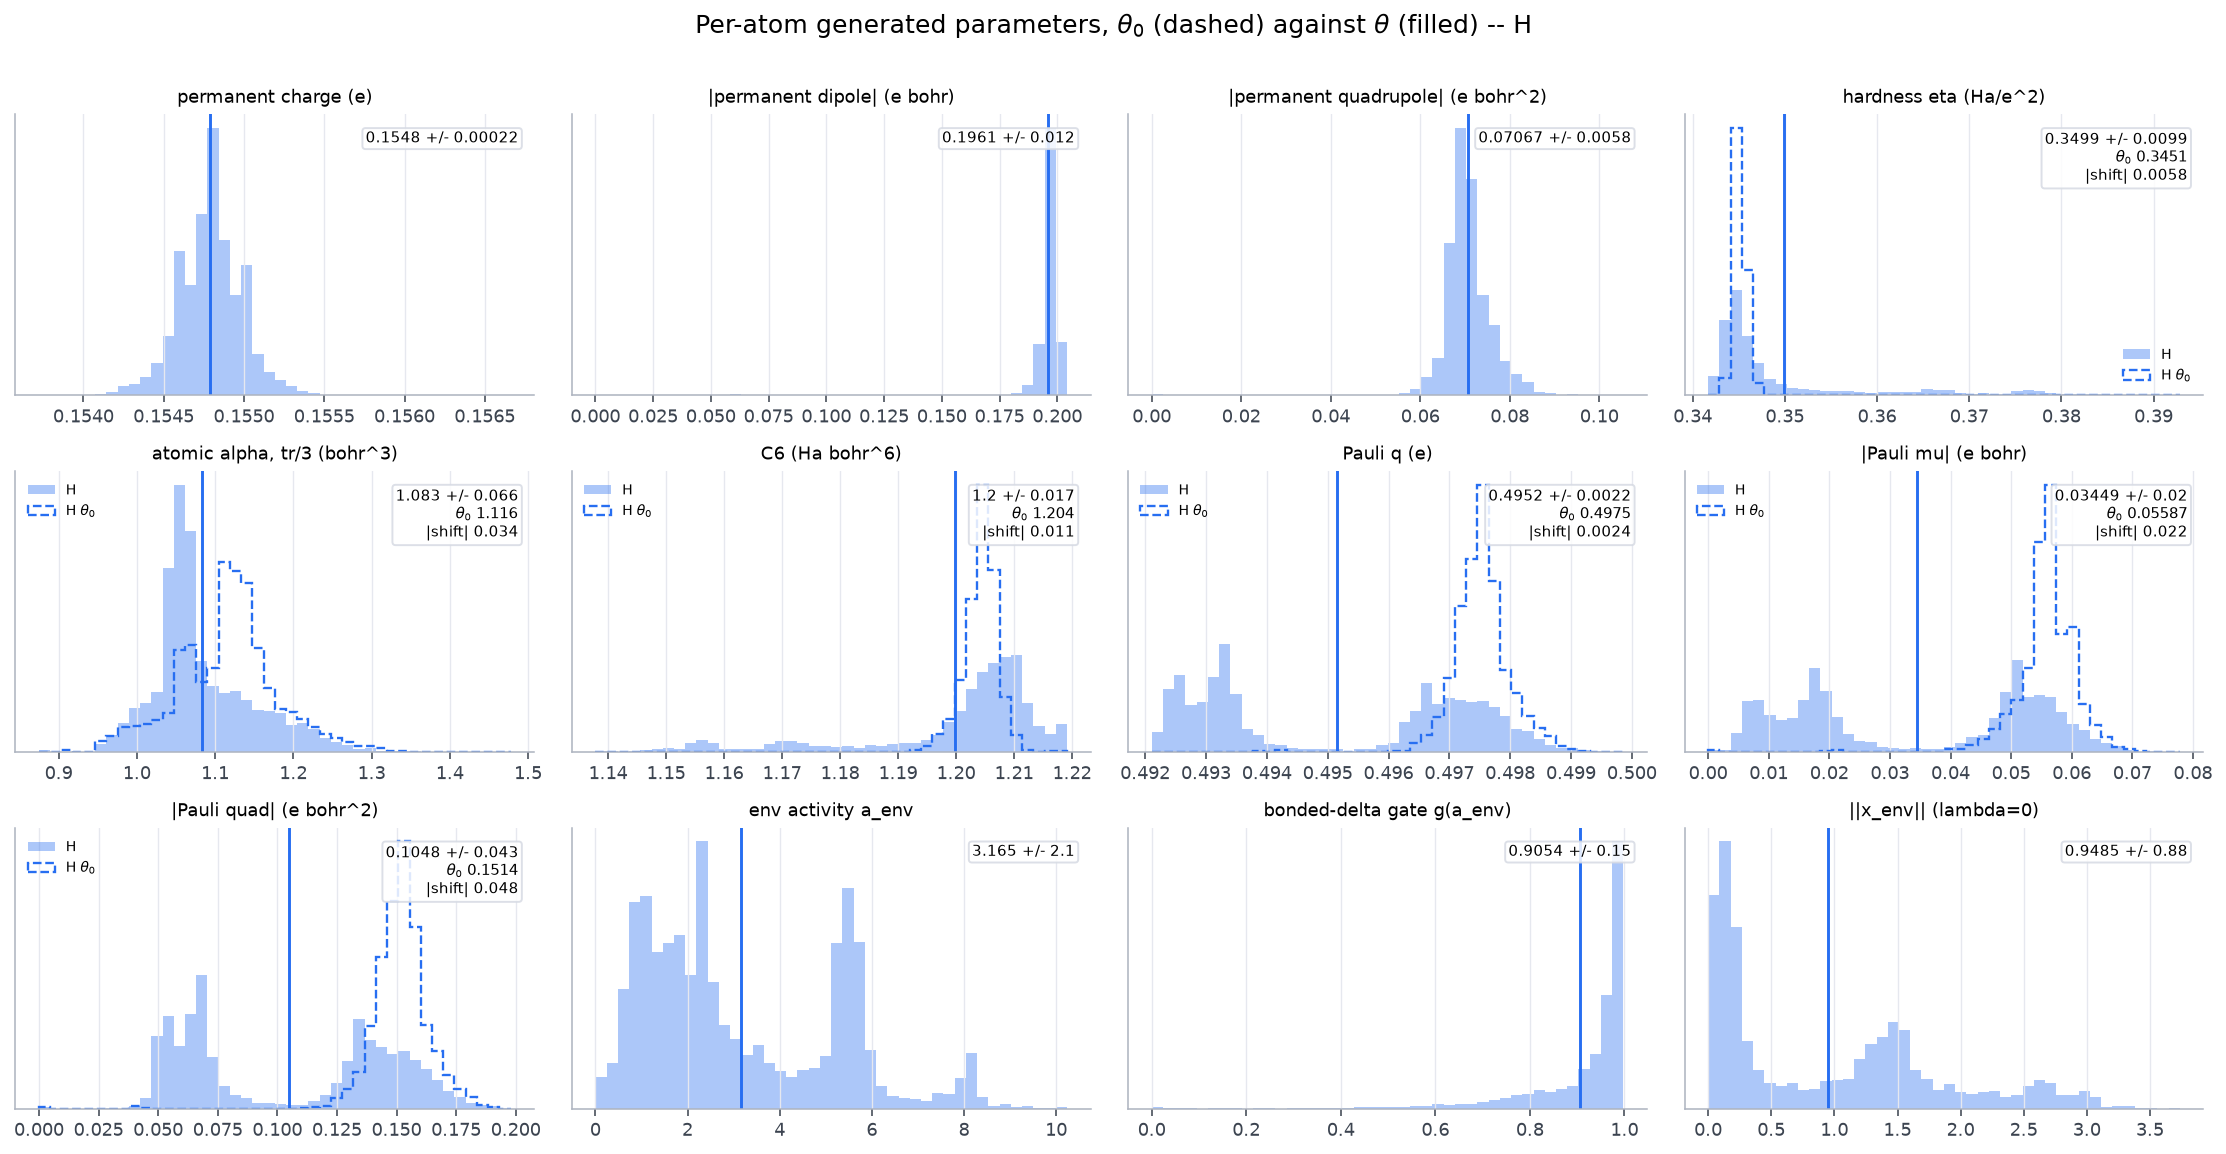

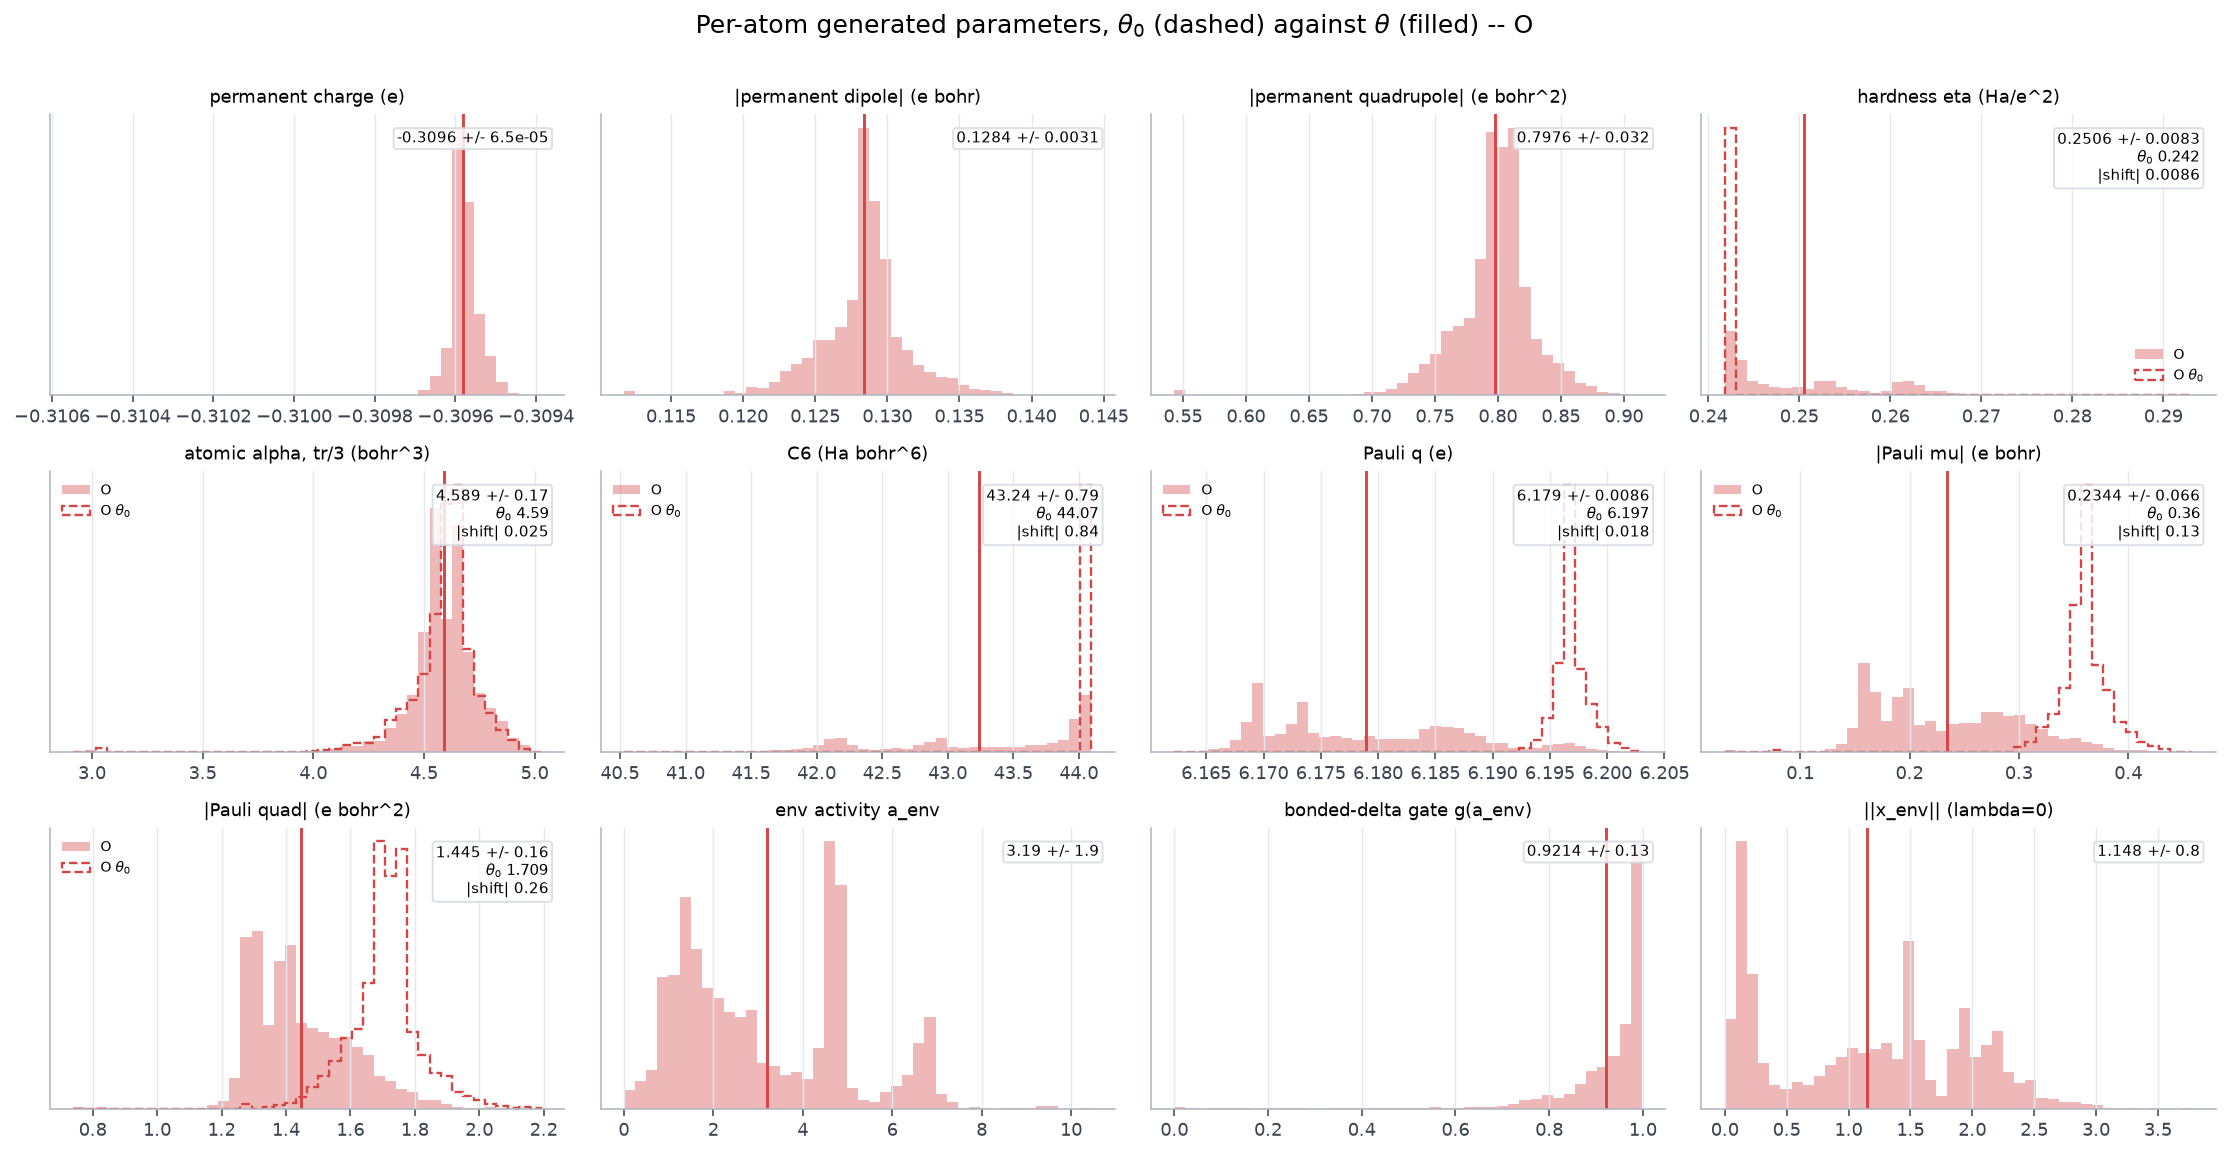

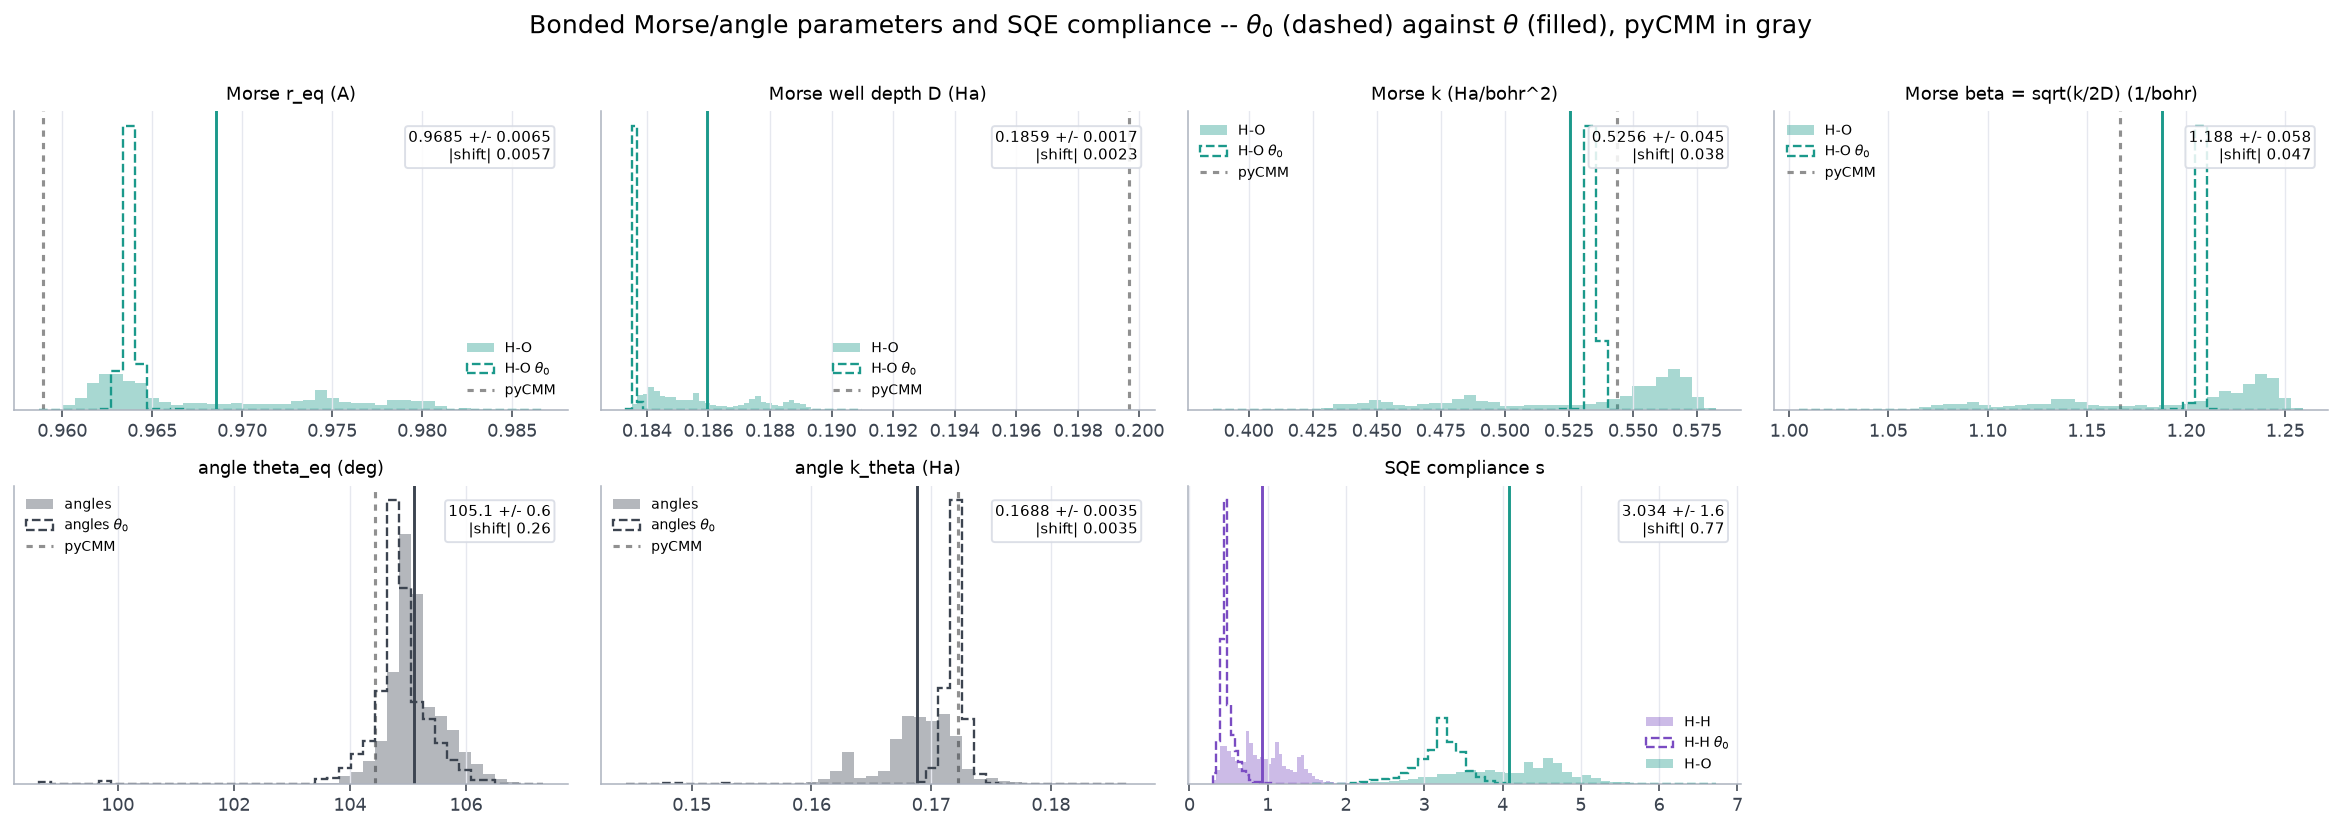

In [288]:
#: pyCMM water constants for the reference lines, in the units each panel plots.
_R_EQ, _D, _K = DEFAULT_BOND_PRIOR[(1, 8)]
_THETA, _KTHETA = DEFAULT_ANGLE_PRIOR[8]
PYCMM_LINES = {
    "r_eq": _R_EQ * BOHR_ANG, "d": _D, "k": _K,
    "beta": float(np.sqrt(_K / (2 * _D))),
    "theta_eq": float(np.degrees(_THETA)), "k_theta": _KTHETA,
}

#: (key, label, dual?) for the per-atom figure, one figure per element.
ATOM_SPECS = [
    ("q_perm", "permanent charge (e)", False),
    ("mu_perm", "|permanent dipole| (e bohr)", False),
    ("quad_perm", "|permanent quadrupole| (e bohr^2)", False),
    ("eta", "hardness eta (Ha/e^2)", True),
    ("alpha_iso_part", "atomic alpha, tr/3 (bohr^3)", True),
    ("c6", "C6 (Ha bohr^6)", True),
    ("q_pauli", "Pauli q (e)", True),
    ("mu_pauli", "|Pauli mu| (e bohr)", True),
    ("quad_pauli", "|Pauli quad| (e bohr^2)", True),
    ("a_env", "env activity a_env", False),
    ("gate", "bonded-delta gate g(a_env)", False),
    ("env_norm", "||x_env|| (lambda=0)", False),
]

#: (store-name, key, label) for the bonded/compliance figure; every entry is dual.
BONDED_SPECS = [
    ("bonds", "r_eq", "Morse r_eq (A)"),
    ("bonds", "d", "Morse well depth D (Ha)"),
    ("bonds", "k", "Morse k (Ha/bohr^2)"),
    ("bonds", "beta", "Morse beta = sqrt(k/2D) (1/bohr)"),
    ("angles", "theta_eq", "angle theta_eq (deg)"),
    ("angles", "k_theta", "angle k_theta (Ha)"),
    ("channels", "s", "SQE compliance s"),
]


def _dual_hist(ax, vals, iso_vals, color, name, first):
    """theta filled, theta_0 dashed outline, both on shared bins; means as vlines."""
    lo = min(vals.min(), iso_vals.min())
    hi = max(vals.max(), iso_vals.max())
    if hi - lo <= 1e-12:
        ax.axvline(float(vals[0]), color=color, lw=2.0, label=name)
        ax.set_xlim(lo - max(abs(lo) * 0.05, 1e-3), hi + max(abs(hi) * 0.05, 1e-3))
        return
    bins = np.linspace(lo, hi, 43)
    ax.hist(vals, bins=bins, density=True, histtype="stepfilled", alpha=0.38,
            color=color, label=name)
    ax.axvline(vals.mean(), color=color, lw=1.5)
    if not np.allclose(iso_vals, vals):
        ax.hist(iso_vals, bins=bins, density=True, histtype="step", color=color,
                lw=1.2, ls="--", label=f"{name} $\\theta_0$" if first else None)


def plot_atom_parameters(atoms, z, path=None, ncols=4):
    """One panel per per-atom parameter, one figure per element.

    Split by element because the two are not on the same scale: C6 is ~2 on H and ~37 on O,
    so a shared axis draws H as a spike at the origin and hides its whole distribution.
    """
    mask = atoms["Z"] == z
    color = ELEMENT_COLOR.get(int(z), "#555")
    name = ELEMENT.get(int(z), str(z))
    nrows = int(np.ceil(len(ATOM_SPECS) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 2.7 * nrows), squeeze=False)
    for ax in axes.ravel():
        ax.set_visible(False)
    for ax, (key, label, dual) in zip(axes.ravel(), ATOM_SPECS):
        ax.set_visible(True)
        vals = atoms[key][mask]
        iso_vals = atoms[f"{key}_iso"][mask] if dual else vals
        _dual_hist(ax, vals, iso_vals, color, name, first=True)
        summary = f"{vals.mean():.4g} +/- {vals.std():.2g}"
        if dual and not np.allclose(iso_vals, vals):
            summary += f"\n$\\theta_0$ {iso_vals.mean():.4g}\n|shift| {np.abs(vals - iso_vals).mean():.2g}"
        ax.text(0.97, 0.94, summary, transform=ax.transAxes, ha="right", va="top", fontsize=7.5,
                bbox={"boxstyle": "round,pad=0.22", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
        ax.set_title(label, fontsize=9)
        ax.set_yticks([])
        if dual and ax.get_legend_handles_labels()[1]:
            ax.legend(frameon=False, fontsize=7)
    fig.suptitle(
        f"Per-atom generated parameters, $\\theta_0$ (dashed) against $\\theta$ (filled) -- {name}",
        y=1.01, fontsize=13,
    )
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


def plot_bonded_parameters(bonds, angles, channels, path=None, ncols=4):
    """The Morse/angle parameters and the SQE compliance, with pyCMM reference lines.

    These are the parameters the film model generates *instead of* a neural bond energy, and
    the figure is the readout of both design dials at once: the spread of each dashed
    (theta_0) distribution around its gray pyCMM line is what `bonded_variance_weight`
    disciplines, and the dashed-to-filled gap is the environment dependence that feeds the
    induction channel. Compliance is split by endpoint pair -- the O-H channels are the
    covalent topology, and how far the H-H channels sit below them is the learned bond graph.
    """
    stores = {"bonds": bonds, "angles": angles, "channels": channels}
    nrows = int(np.ceil(len(BONDED_SPECS) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 2.9 * nrows), squeeze=False)
    for ax in axes.ravel():
        ax.set_visible(False)
    kind_colors = {"H-O": "#1b998b", "H-H": "#7a4cc2", "O-O": "#db6d00"}
    for ax, (store_name, key, label) in zip(axes.ravel(), BONDED_SPECS):
        ax.set_visible(True)
        store = stores[store_name]
        kinds = sorted(set(store["kind"])) if "kind" in store else [None]
        for ki, kind in enumerate(kinds):
            m = np.ones(len(store[key]), bool) if kind is None else (store["kind"] == kind)
            if not m.any():
                continue
            color = kind_colors.get(kind, "#3c4450")
            _dual_hist(ax, store[key][m], store[f"{key}_iso"][m], color,
                       kind or store_name, first=ki == 0)
        if key in PYCMM_LINES:
            ax.axvline(PYCMM_LINES[key], color="#909090", lw=1.6, ls=(0, (2, 2)),
                       label="pyCMM", zorder=0)
        vals = store[key]
        iso_vals = store[f"{key}_iso"]
        summary = (f"{vals.mean():.4g} +/- {vals.std():.2g}\n"
                   f"|shift| {np.abs(vals - iso_vals).mean():.2g}")
        ax.text(0.97, 0.94, summary, transform=ax.transAxes, ha="right", va="top",
                fontsize=7.5,
                bbox={"boxstyle": "round,pad=0.22", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
        ax.set_title(label, fontsize=9)
        ax.set_yticks([])
        if ax.get_legend_handles_labels()[1]:
            ax.legend(frameon=False, fontsize=7)
    fig.suptitle(
        "Bonded Morse/angle parameters and SQE compliance -- "
        "$\\theta_0$ (dashed) against $\\theta$ (filled), pyCMM in gray",
        y=1.01, fontsize=13,
    )
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


for z in sorted(set(atoms["Z"])):
    name = ELEMENT.get(int(z), str(int(z)))
    fig = plot_atom_parameters(
        atoms, z=int(z),
        path=FIGDIR / f"{FIGPREFIX}_parameter_distributions_{name}.png",
    )
    plt.show()

fig = plot_bonded_parameters(
    bonds, angles, channels,
    path=FIGDIR / f"{FIGPREFIX}_bonded_parameter_distributions.png",
)
plt.show()


## The parameters as a hydrogen-bond descriptor

Several of the per-atom distributions above are visibly **bimodal** -- `C6`, the hardness
`eta`, the Pauli charge, the environment-feature norm -- and nothing in the model was ever
told to make them so. The hypothesis this section tests is that the two lumps are the two
hydrogen-bonding populations: a hydrogen that donates against one that does not, an oxygen
that accepts against one that does not. If that is right, a parameter the model generates to
get an energy right is also a *learned* hydrogen-bond descriptor, and it can be read as one.

The label it is scored against is the same geometric descriptor the Badger figure splits on
(`rsfff.md.film_driver.hydrogen_bonds`, `HBOND_DISTANCE` / `HBOND_ANGLE`): an O-H donates when
an oxygen on another fragment sits close enough to the H at a linear enough O-H...O angle.
Projected onto atoms, a hydrogen carries 0 or 1 and an oxygen carries the number of hydrogens
donating *to it*, so "hydrogen bonded" means donor for H and acceptor for O -- two different
statements, which is why the figure has one row per element.

The population is the w2-w5 frames every other figure uses, plus -- for a checkpoint that
carries a `data.large_path` stream -- w6 to w23. The large clusters matter here out of all
proportion to their frame count: they are the only frames with an *interior* water, four
hydrogen bonds and no free O-H, and w2-w5 alone would answer the question using almost
nothing but molecules sitting on a surface.

Two readings, and they are different claims:

- **the split histograms** ask whether the two populations sit in different places. The grey
  dashed outline is the same parameter at `theta_0` and is the control: it is one lump, so the
  second mode is not something the isolated-fragment geometry already knew -- it arrives with
  the environment block, which is the only place a hydrogen bond can enter this model.
- **the confusion matrices** ask how much of the histogram's separation is real. The cut is
  placed by Otsu's criterion on the *pooled* histogram, which is the quantitative form of
  reading the dividing line off the valley between the two modes; it never sees a label. Only
  the cut's **direction** -- which side is the bonded one -- comes from the labels, and that is
  one bit. Everything else is an honest test of agreement between a learned quantity and a
  geometric definition it was never trained on.

The printed table is the short version. `bimodality` is the fraction of the parameter's own
variance the cut separates -- the histogram's claim, made without reference to anything -- and
`MCC` is how much of that separation is the hydrogen bond. They do not have to agree: a
parameter can be cleanly bimodal for some other reason, and the hydrogen Pauli charge, whose
entire range is a few thousandths of an electron, is the one here that splits without the
split meaning donation.


H: 5584 atoms, hydrogen bonds per atom 0:2767  1:2817
O: 2792 atoms, hydrogen bonds per atom 0:831  1:1108  2:850  3:3

 element   parameter         cut  bimodality  accuracy  balanced     MCC
       H          c6       1.187        0.80     66.1%     66.4%   +0.44
       H     q_pauli      0.4952        0.91     99.0%     99.0%   +0.98
       H         eta       0.358        0.82     66.0%     66.3%   +0.44
       H    env_norm       1.027        0.76     93.9%     94.0%   +0.88
       O          c6       43.14        0.80     72.9%     80.7%   +0.57
       O     q_pauli        6.18        0.77     86.0%     89.8%   +0.73
       O         eta      0.2521        0.77     69.9%     78.6%   +0.53
       O    env_norm       1.086        0.76     84.4%     88.9%   +0.71


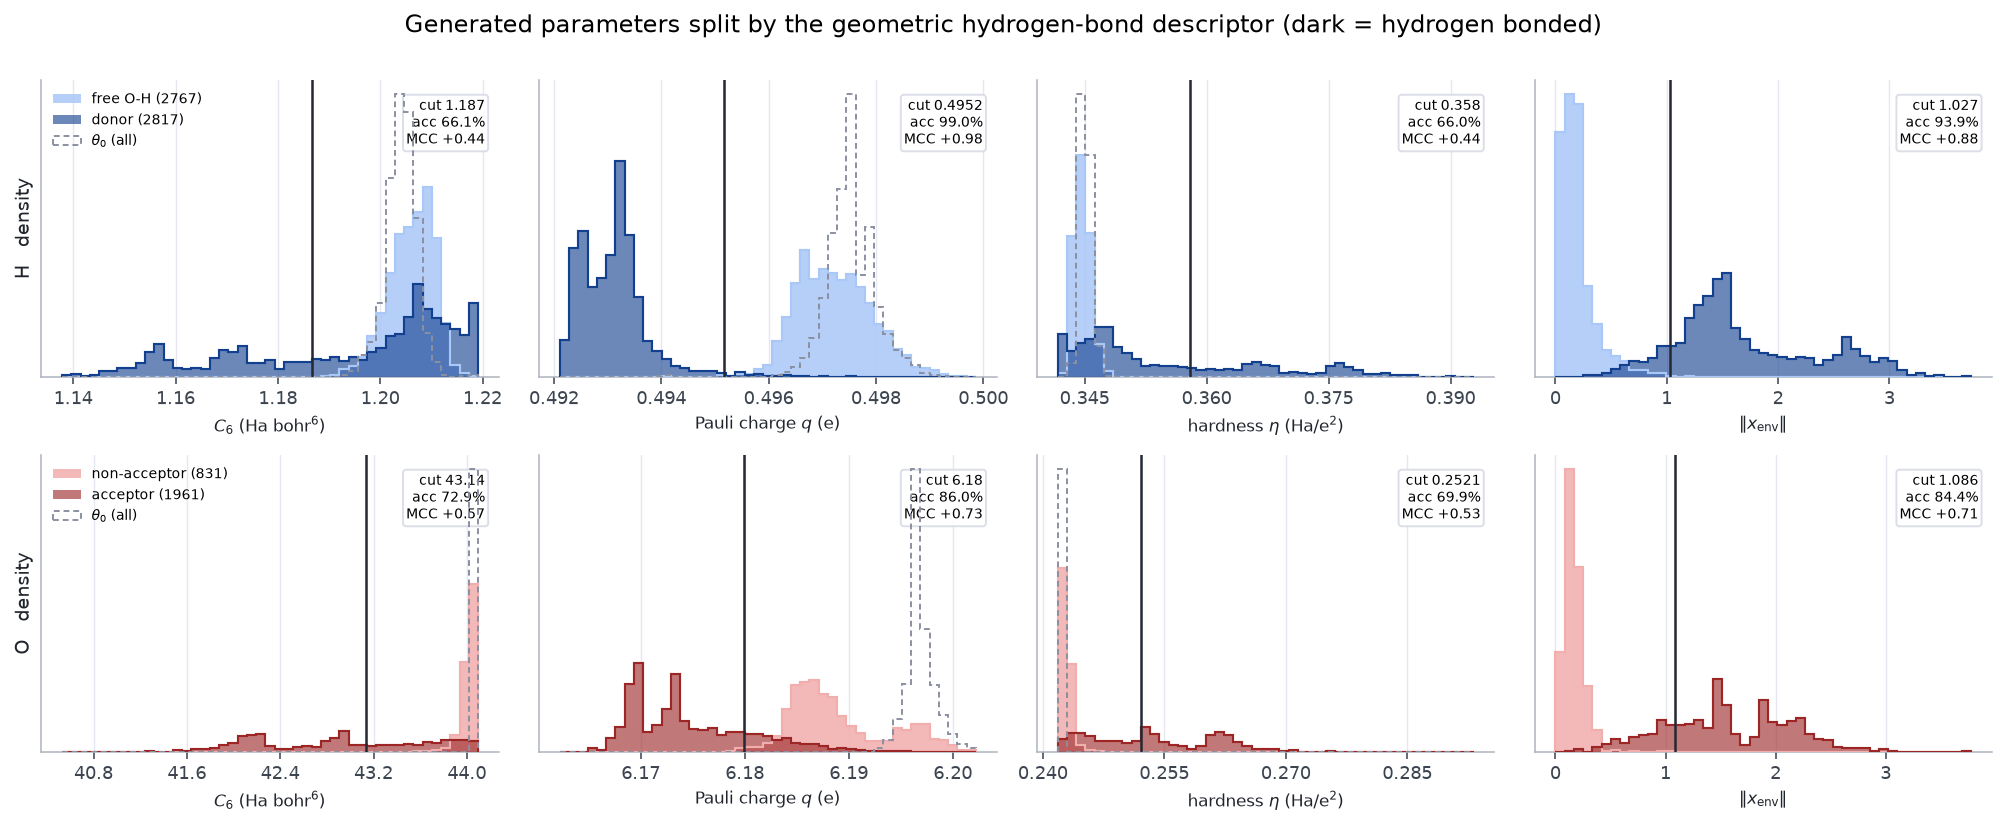

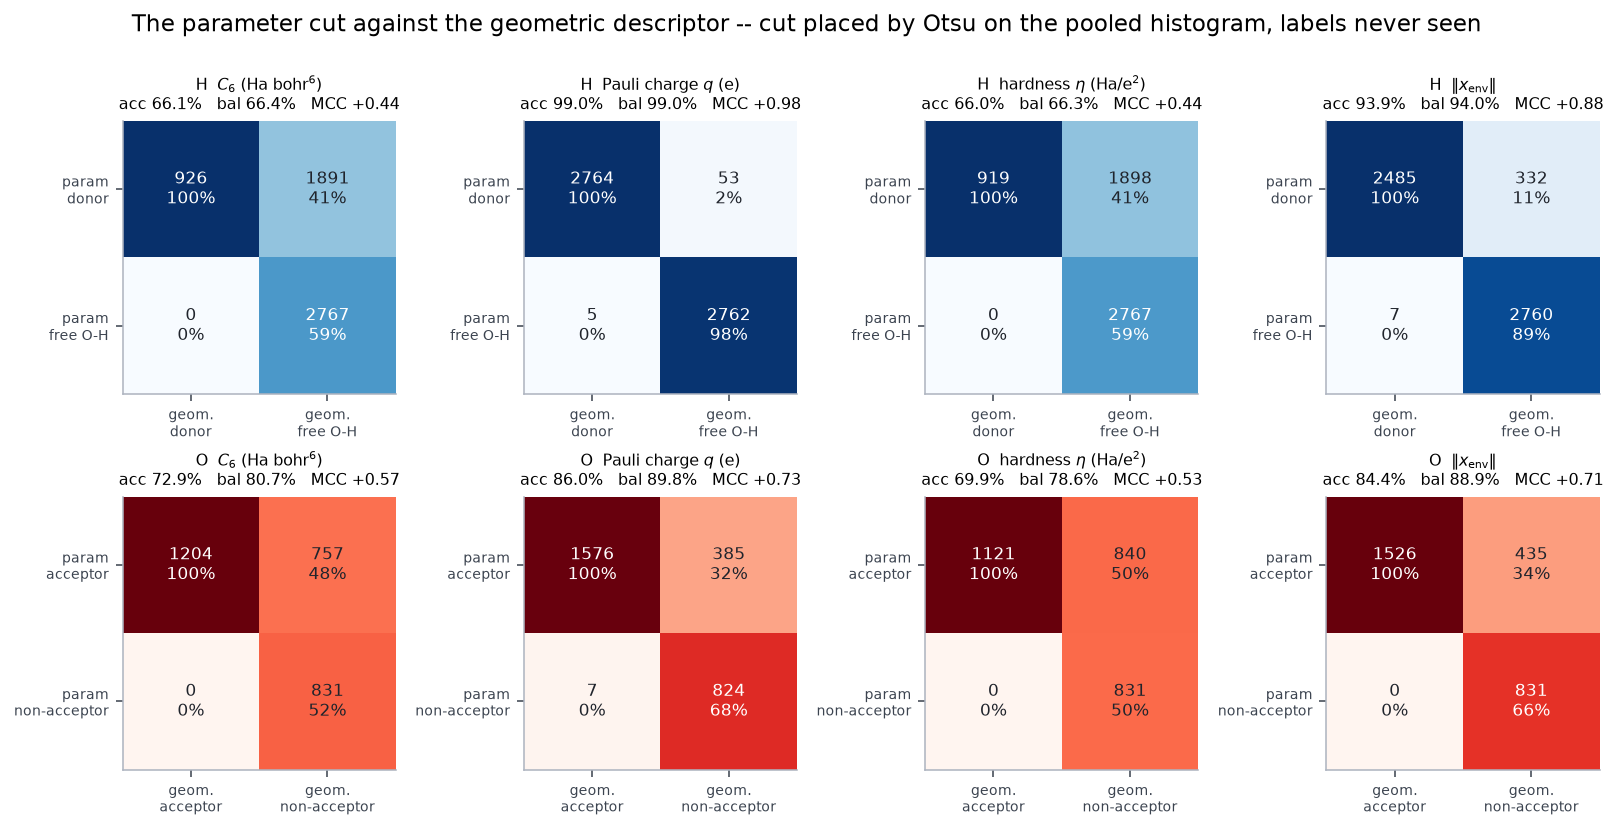

In [289]:
# ---- Are the generated parameters a hydrogen-bond descriptor? ---------------------------
#: (key, axis label, dual?) -- the parameters whose per-atom distribution is visibly bimodal.
HBOND_SPECS = [
    ("c6", "$C_6$ (Ha bohr$^6$)", True),
    ("q_pauli", "Pauli charge $q$ (e)", True),
    ("eta", "hardness $\\eta$ (Ha/e$^2$)", True),
    ("env_norm", "$\\|x_{\\mathrm{env}}\\|$", False),
]

#: (dark = hydrogen bonded, light = not), per element. The dark/light pair *is* the reading.
HBOND_SHADES = {1: ("#12408f", "#a9c7f7"), 8: ("#9c2626", "#f2adad")}

#: what "hydrogen bonded" means for each element, since the descriptor is directional.
HBOND_ROLE = {1: ("donor", "free O-H"), 8: ("acceptor", "non-acceptor")}


def otsu_threshold(values, bins=160):
    """The cut between two populations read off the value histogram alone, no labels used.

    Otsu's criterion -- maximize the between-class variance of the two sides of a cut -- is
    the quantitative form of "read off the dividing line between the two distributions": on a
    bimodal histogram it lands in the valley, and it never sees the hydrogen-bond label, which
    is what keeps the confusion matrix below an actual test rather than a fitted threshold.

    Returns the cut and the between/total variance ratio, which is how bimodal the histogram
    had to be for the cut to mean anything (near 1: two clean lumps; near 0: one blob).
    """
    counts, edges = np.histogram(np.asarray(values, float), bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    w = counts.astype(float)
    total = w.sum()
    if total == 0 or np.ptp(centers) == 0:
        return float(np.mean(values)), 0.0
    w0 = np.cumsum(w)[:-1]
    w1 = total - w0
    mean_lo = np.cumsum(w * centers)[:-1] / np.maximum(w0, 1e-12)
    mean_hi = (np.sum(w * centers) - np.cumsum(w * centers)[:-1]) / np.maximum(w1, 1e-12)
    between = w0 * w1 * (mean_lo - mean_hi) ** 2 / total**2
    between[(w0 == 0) | (w1 == 0)] = -np.inf
    k = int(np.argmax(between))
    variance = float(np.var(np.asarray(values, float)))
    return float(edges[k + 1]), float(between[k] / variance) if variance > 0 else 0.0


def hbond_classifier(values, hbonded, bins=160):
    """Threshold one parameter and score it against the geometric label.

    The *location* of the cut is unsupervised (`otsu_threshold`); only its **direction** --
    which side of the valley is the hydrogen-bonded one -- is taken from the labels, and that
    is one bit. Everything else is a genuine out-of-sample statement about whether the two
    lumps in the parameter histogram are the two hydrogen-bonding populations.
    """
    values = np.asarray(values, float)
    threshold, bimodality = otsu_threshold(values, bins=bins)
    high_is_bonded = values[hbonded].mean() > values[~hbonded].mean()
    predicted = values > threshold if high_is_bonded else values < threshold

    tp = int((predicted & hbonded).sum())
    fp = int((predicted & ~hbonded).sum())
    fn = int((~predicted & hbonded).sum())
    tn = int((~predicted & ~hbonded).sum())
    confusion = np.array([[tp, fn], [fp, tn]], dtype=float)   # rows: predicted, cols: true
    denominator = np.sqrt(float((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)))
    return {
        "threshold": threshold, "bimodality": bimodality, "high_is_bonded": high_is_bonded,
        "confusion": confusion, "predicted": predicted,
        "accuracy": (tp + tn) / max(values.size, 1),
        "balanced": 0.5 * (tp / max(tp + fn, 1) + tn / max(tn + fp, 1)),
        "mcc": (tp * tn - fp * fn) / denominator if denominator > 0 else 0.0,
    }


def hbond_classifiers(atoms, specs=HBOND_SPECS):
    """One classifier per (element, parameter), on the env-dressed `theta` values."""
    out = {}
    for z in sorted(set(int(v) for v in atoms["Z"])):
        mask = atoms["Z"] == z
        bonded = atoms["hb_count"][mask] > 0
        for key, _label, _dual in specs:
            out[(z, key)] = hbond_classifier(atoms[key][mask], bonded)
    return out


def plot_hbond_split(atoms, fits, specs=HBOND_SPECS, path=None):
    """Each parameter's distribution, split by the geometric hydrogen-bond descriptor.

    Dark is hydrogen bonded -- a donating hydrogen, an accepting oxygen -- and light is not.
    Both are densities, not counts, so the shapes stay comparable although the populations are
    not the same size; the grey dashed outline is the same parameter at `theta_0`, which is the
    control: with the environment blocks off there is one lump, so the second mode is not
    something the internal geometry already knew.

    The vertical line is the Otsu cut of the *pooled* histogram, placed without ever seeing the
    labels. How well it falls between the dark and light lumps is exactly what the confusion
    matrices score.
    """
    rows = sorted(set(int(v) for v in atoms["Z"]))
    fig, axes = plt.subplots(len(rows), len(specs), figsize=(3.6 * len(specs), 2.9 * len(rows)),
                             squeeze=False)
    for r, z in enumerate(rows):
        mask = atoms["Z"] == z
        bonded = atoms["hb_count"][mask] > 0
        dark, light = HBOND_SHADES.get(z, ("#3c4450", "#c3c7d0"))
        bonded_name, free_name = HBOND_ROLE.get(z, ("bonded", "free"))
        for c, (key, label, dual) in enumerate(specs):
            ax = axes[r][c]
            vals = atoms[key][mask]
            bins = np.linspace(vals.min(), vals.max(), 46)
            populations = ((~bonded, light, free_name, 0.85, 2),
                           (bonded, dark, bonded_name, 0.62, 3))
            for sub, color, name, alpha, zorder in populations:
                if not sub.any():
                    continue
                ax.hist(vals[sub], bins=bins, density=True, histtype="stepfilled",
                        color=color, alpha=alpha, lw=0, zorder=zorder,
                        label=f"{name} ({int(sub.sum())})")
                ax.hist(vals[sub], bins=bins, density=True, histtype="step",
                        color=color, lw=1.1, zorder=4)
            if dual:
                ax.hist(atoms[f"{key}_iso"][mask], bins=bins, density=True, histtype="step",
                        color="#8a90a0", lw=1.0, ls=(0, (3, 2)), zorder=5,
                        label="$\\theta_0$ (all)")
            fit = fits[(z, key)]
            ax.axvline(fit["threshold"], color="#242934", lw=1.3, zorder=6)
            ax.text(0.97, 0.94,
                    f"cut {fit['threshold']:.4g}\nacc {fit['accuracy']:.1%}"
                    f"\nMCC {fit['mcc']:+.2f}",
                    transform=ax.transAxes, ha="right", va="top", fontsize=7.2,
                    bbox={"boxstyle": "round,pad=0.22", "fc": "white", "ec": "#d6dae3",
                          "alpha": 0.88})
            ax.set_yticks([])
            ax.xaxis.set_major_locator(plt.MaxNLocator(5))
            ax.set_xlabel(label, fontsize=8.5)
            if c == 0:
                ax.set_ylabel(f"{ELEMENT.get(z, z)}   density", fontsize=10)
                ax.legend(frameon=False, fontsize=7, loc="best")
    fig.suptitle(
        "Generated parameters split by the geometric hydrogen-bond descriptor "
        "(dark = hydrogen bonded)", y=1.005, fontsize=12.5,
    )
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


def plot_hbond_confusion(fits, specs=HBOND_SPECS, path=None):
    """Read the cut as a classifier: does the parameter agree with the geometry?

    Rows are what the parameter says, columns what the O-H...O geometry says, and each cell is
    annotated with its count over the column total -- so the diagonal is recall on the bonded
    population and specificity on the free one. A parameter that is genuinely a hydrogen-bond
    descriptor puts its mass on the diagonal from a cut that never saw a single label.
    """
    rows = sorted({z for z, _ in fits})
    fig, axes = plt.subplots(len(rows), len(specs), figsize=(2.9 * len(specs), 2.9 * len(rows)),
                             squeeze=False)
    for r, z in enumerate(rows):
        bonded_name, free_name = HBOND_ROLE.get(z, ("bonded", "free"))
        for c, (key, label, _dual) in enumerate(specs):
            ax = axes[r][c]
            fit = fits[(z, key)]
            counts = fit["confusion"]
            column = counts.sum(axis=0, keepdims=True)
            fraction = counts / np.maximum(column, 1)
            ax.imshow(fraction, cmap="Blues" if z == 1 else "Reds", vmin=0, vmax=1)
            for i in range(2):
                for j in range(2):
                    ax.text(j, i, f"{int(counts[i, j])}\n{fraction[i, j]:.0%}",
                            ha="center", va="center", fontsize=8.5,
                            color="white" if fraction[i, j] > 0.55 else "#20242c")
            ax.set_xticks([0, 1], [f"geom.\n{bonded_name}", f"geom.\n{free_name}"], fontsize=7)
            ax.set_yticks([0, 1], [f"param\n{bonded_name}", f"param\n{free_name}"], fontsize=7)
            ax.grid(False)
            ax.set_title(f"{ELEMENT.get(z, z)}  {label}\n"
                         f"acc {fit['accuracy']:.1%}   bal {fit['balanced']:.1%}   "
                         f"MCC {fit['mcc']:+.2f}", fontsize=8)
    fig.suptitle(
        "The parameter cut against the geometric descriptor -- cut placed by Otsu on the "
        "pooled histogram, labels never seen", y=1.005, fontsize=12,
    )
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


def load_large_datasets(cfg):
    """The large-cluster stream the checkpoint was trained with, or `{}` if it had none.

    `datasets`, and so every other figure in this notebook, is the `data.path` list -- w2 to
    w5. A checkpoint trained with `data.large_path` has also seen w6 to w23, and those are the
    only frames here containing an *interior* water: four hydrogen bonds, no free O-H, the
    environment the descriptor question is really about. The tags are suffixed because the
    large stream repeats w4 and w5 at different geometries.
    """
    paths = getattr(cfg.data, "large_path", None) or []
    dtype = torch.float64 if cfg.dtype == "float64" else torch.float32
    return {f"{cluster_tag(p)}-large": load_extxyz(p, dtype=dtype) for p in paths}


def stack_atom_tables(*tables):
    """Concatenate per-atom tables over the columns all of them carry."""
    keys = set(tables[0]).intersection(*(set(t) for t in tables[1:]))
    return {key: np.concatenate([t[key] for t in tables]) for key in keys}


large_datasets = load_large_datasets(cfg)
if large_datasets:
    large_atoms, *_ = collect_film_parameters(
        model, large_datasets, device, n_frames=HBOND_LARGE_FRAMES_PER_CLUSTER,
    )
    hbond_atoms = stack_atom_tables(atoms, large_atoms)
    print(f"large-cluster stream: {len(large_atoms['Z'])} atoms over "
          f"{len(large_datasets)} files ({', '.join(large_datasets)})")
else:
    hbond_atoms = atoms

hbond_fits = hbond_classifiers(hbond_atoms)
for z in sorted(set(int(v) for v in hbond_atoms["Z"])):
    mask = hbond_atoms["Z"] == z
    counts = np.bincount(hbond_atoms["hb_count"][mask])
    print(f"{ELEMENT.get(z, z)}: {int(mask.sum())} atoms, hydrogen bonds per atom "
          + "  ".join(f"{n}:{c}" for n, c in enumerate(counts)))
print(f"\n{'element':>8}{'parameter':>12}{'cut':>12}{'bimodality':>12}"
      f"{'accuracy':>10}{'balanced':>10}{'MCC':>8}")
for (z, key), fit in hbond_fits.items():
    print(f"{ELEMENT.get(z, z):>8}{key:>12}{fit['threshold']:>12.4g}{fit['bimodality']:>12.2f}"
          f"{fit['accuracy']:>10.1%}{fit['balanced']:>10.1%}{fit['mcc']:>+8.2f}")

fig = plot_hbond_split(hbond_atoms, hbond_fits,
                       path=FIGDIR / f"{FIGPREFIX}_hbond_parameter_split.png")
plt.show()
fig = plot_hbond_confusion(hbond_fits, path=FIGDIR / f"{FIGPREFIX}_hbond_confusion.png")
plt.show()


## Scans through the model's own monomer equilibrium

The distributions above say what each bonded parameter *is* across the dataset; they do not say
what it is a function **of**. These three scans do. One water is relaxed on the model's own
`fragment_energy` surface -- not quoted from experiment, so that zero on every x axis is a
genuine stationary point of *this* checkpoint -- and then displaced along the symmetric stretch,
the antisymmetric stretch, and the bend.

A single fragment means `gate == 0` exactly, so `theta == theta_0` throughout and there is one
curve per parameter rather than two. The rows group by unit: both O-H bonds share every Morse
panel, and the antisymmetric column is the only place their curves separate -- the permutation
symmetry of the head (`z_i + z_j`, `(z_i - z_j)^2`) showing up as an exact mirror about the
origin.

What to look for:

- **the y scales against the grey twin axis.** The heads never see `r` or `theta`; a generated
  `r_eq` that tracked the instantaneous bond length would mean the Morse form is decorative
  bookkeeping around a pair energy. It moves by ~1% of what the coordinate does.
- **the sign of the coupling.** In the antisymmetric column the stretched bond's `r_eq` goes
  *down* while its partner's goes up -- the bond-bond anticooperativity pyCMM needs an explicit
  cross term for, here carried implicitly by the features.
- **the stretch-bend row.** `theta_eq` and `k_theta` move much further under the symmetric
  stretch than anything moves under the bend -- pyCMM's stretch-bend term, again implicit.
- **the shoulder in the symmetric-stretch energy near +0.25 A.** That one is *not* bonded: it
  is the intra classical channels switching on inside the bond. Their Fermi gates are
  referenced to the per-element `r0` table (O-H: 1.23 A elst, 1.22 A pauli, 1.19 A disp), so
  they are ~0 at the 0.96 A equilibrium and cross 1/2 near 1.22 A, where `elst` and `pauli`
  each reach ~300 kJ/mol and cancel to within a few. The intra O-H distance never exceeds
  1.08 A in the cluster data (1.17 A in the monomer anchor), so nothing fitted that region --
  read past ~+0.15 A as extrapolation, not as the model's dissociation behaviour.

In [290]:
# ---- Internal-coordinate scans of one water, on the model's own equilibrium -------------
# A distribution says what a parameter *is*; a scan says what it is a function *of*. The
# bonded heads never see `r` or `theta` -- only the features -- so these curves are the
# direct test of whether "parameter" is meant literally: a generated `r_eq` that tracked the
# instantaneous bond length would be a pair energy wearing a Morse costume. One isolated
# fragment also means `gate == 0` exactly, so `theta == theta_0` here and there is only one
# curve per parameter to draw.

#: (O, H1, H2), the atom order every frame below is built in.
SCAN_Z = (8, 1, 1)


def water_positions(r1, r2, theta):
    """(B, 3, 3) Angstrom for `(r1, r2, theta)` triples -- O at the origin, in the xz plane.

    Bisector along +z, so the two bonds are mirror images across the yz plane and an
    antisymmetric displacement is exactly the swap `1 <-> 2`.
    """
    r1, r2, theta = (torch.as_tensor(t, dtype=torch.get_default_dtype())
                     for t in (r1, r2, theta))
    zero, half = torch.zeros_like(r1), 0.5 * theta
    return torch.stack((
        torch.stack((zero, zero, zero), -1),
        torch.stack((r1 * torch.sin(half), zero, r1 * torch.cos(half)), -1),
        torch.stack((-r2 * torch.sin(half), zero, r2 * torch.cos(half)), -1),
    ), -2)


def monomer_batch(positions, device=None):
    """A `Batch` of isolated waters, one fragment per frame."""
    n = positions.shape[0]
    batch = Batch(
        positions=positions.reshape(-1, 3),
        atomic_numbers=torch.tensor(SCAN_Z, dtype=torch.long).repeat(n),
        batch_idx=torch.arange(n).repeat_interleave(3),
        n_systems=n,
        energy=torch.zeros(n),
        fragment_idx=torch.arange(n).repeat_interleave(3),
        fragment_to_batch=torch.arange(n),
        n_fragments=n,
    )
    return batch if device is None else batch.to(device)


def relax_monomer(model, device, start=(0.9572, 0.9572, 1.8242)):
    """Minimize `fragment_energy` over `(r1, r2, theta)` -- the model's own equilibrium.

    Relaxing on the *model* surface rather than quoting the experimental geometry is what
    makes a scan through the origin a scan through a stationary point; the reference r0/theta0
    the network was initialized at is not where the trained model actually sits.
    """
    q = torch.tensor(start, dtype=torch.get_default_dtype(), requires_grad=True)
    opt = torch.optim.LBFGS([q], lr=0.3, max_iter=250, tolerance_grad=1e-12,
                            tolerance_change=1e-16, line_search_fn="strong_wolfe")

    def closure():
        opt.zero_grad()
        pos = water_positions(q[0:1], q[1:2], q[2:3]).to(device)
        e = model(monomer_batch(pos, device)).fragment_energy.sum()
        e.backward()
        return e

    opt.step(closure)
    return tuple(float(v) for v in q.detach())


def scan_bonded_parameters(model, device, r1, r2, theta, batch_size=BATCH_SIZE):
    """Run a list of internal coordinates through the model; return per-frame parameters.

    Bonds are labelled by the H they contain rather than by row order, so the antisymmetric
    branch stays attached to the bond it stretched no matter how the topology enumerates.
    """
    out_rows = {k: [] for k in ("energy", "r1", "r2", "theta",
                                "r_eq_1", "r_eq_2", "d_1", "d_2", "k_1", "k_2",
                                "beta_1", "beta_2", "theta_eq", "k_theta")}
    r1, r2, theta = (torch.as_tensor(t, dtype=torch.get_default_dtype())
                     for t in (r1, r2, theta))
    for start in range(0, len(r1), batch_size):
        sl = slice(start, start + batch_size)
        pos = water_positions(r1[sl], r2[sl], theta[sl])
        batch = monomer_batch(pos.to(device), device)
        with torch.no_grad():
            out = model(batch)
        p, topo = out.parameters.bonded, out.topology
        # (frame, which-H) placement: atoms are laid out O,H1,H2 per frame, so the local
        # index of a bond's non-oxygen endpoint is 1 or 2.
        local = to_np(topo.bond_index.max(dim=0).values % 3)      # H is the larger index
        order = np.argsort(local.reshape(-1, 2), axis=1)          # -> columns [H1, H2]
        take = lambda t: to_np(t).reshape(-1, 2)[
            np.arange(order.shape[0])[:, None], order
        ]
        r_eq, d, k = take(p.r_eq) * BOHR_ANG, take(p.d), take(p.k)
        beta = np.sqrt(take(p.k) / (2.0 * take(p.d)))
        for col, vals in (("r_eq", r_eq), ("d", d), ("k", k), ("beta", beta)):
            out_rows[f"{col}_1"].append(vals[:, 0])
            out_rows[f"{col}_2"].append(vals[:, 1])
        out_rows["theta_eq"].append(
            np.degrees(to_np(p.cos_theta_eq.clamp(-1, 1).arccos()))
        )
        out_rows["k_theta"].append(to_np(p.k_theta))
        out_rows["energy"].append(to_np(out.fragment_energy))
        out_rows["r1"].append(to_np(r1[sl]))
        out_rows["r2"].append(to_np(r2[sl]))
        out_rows["theta"].append(np.degrees(to_np(theta[sl])))
    return {k: np.concatenate(v) for k, v in out_rows.items()}


#: (key, x label, how the internal coordinates are built from the displacement grid).
SCAN_SPECS = [
    ("sym", "symmetric stretch", "$\\Delta r_1 = \\Delta r_2$ ($\\AA$)",
     np.linspace(-0.15, 0.35, 126),
     lambda re1, re2, te, s: (re1 + s, re2 + s, np.full_like(s, te))),
    ("asym", "antisymmetric stretch", "$\\Delta r_1 = -\\Delta r_2$ ($\\AA$)",
     np.linspace(-0.25, 0.25, 121),
     lambda re1, re2, te, s: (re1 + s, re2 - s, np.full_like(s, te))),
    ("bend", "HOH bend", "$\\Delta\\theta$ (deg)",
     np.linspace(-30.0, 30.0, 121),
     lambda re1, re2, te, s: (np.full_like(s, re1), np.full_like(s, re2),
                              te + np.radians(s))),
]

R1_EQ, R2_EQ, THETA_EQ = relax_monomer(model, device)
print(f"model monomer equilibrium: r(O-H) = {R1_EQ:.5f}, {R2_EQ:.5f} A    "
      f"theta(HOH) = {np.degrees(THETA_EQ):.3f} deg")

scans = {}
for key, _title, _xlabel, grid, build in SCAN_SPECS:
    r1, r2, th = build(R1_EQ, R2_EQ, THETA_EQ, grid)
    scan = scan_bonded_parameters(model, device, r1, r2, th)
    scan["x"] = grid
    scans[key] = scan
    e = (scan["energy"] - scan["energy"].min()) * KJMOL_PER_HARTREE
    print(f"  {key:<5} {len(grid):>4} points   deformation energy spans "
          f"{e.min():.2f} to {e.max():.2f} kJ/mol")

model monomer equilibrium: r(O-H) = 0.96321, 0.96321 A    theta(HOH) = 106.344 deg
  sym    126 points   deformation energy spans 0.00 to 281.21 kJ/mol
  asym   121 points   deformation energy spans 0.00 to 363.31 kJ/mol
  bend   121 points   deformation energy spans 0.00 to 59.44 kJ/mol


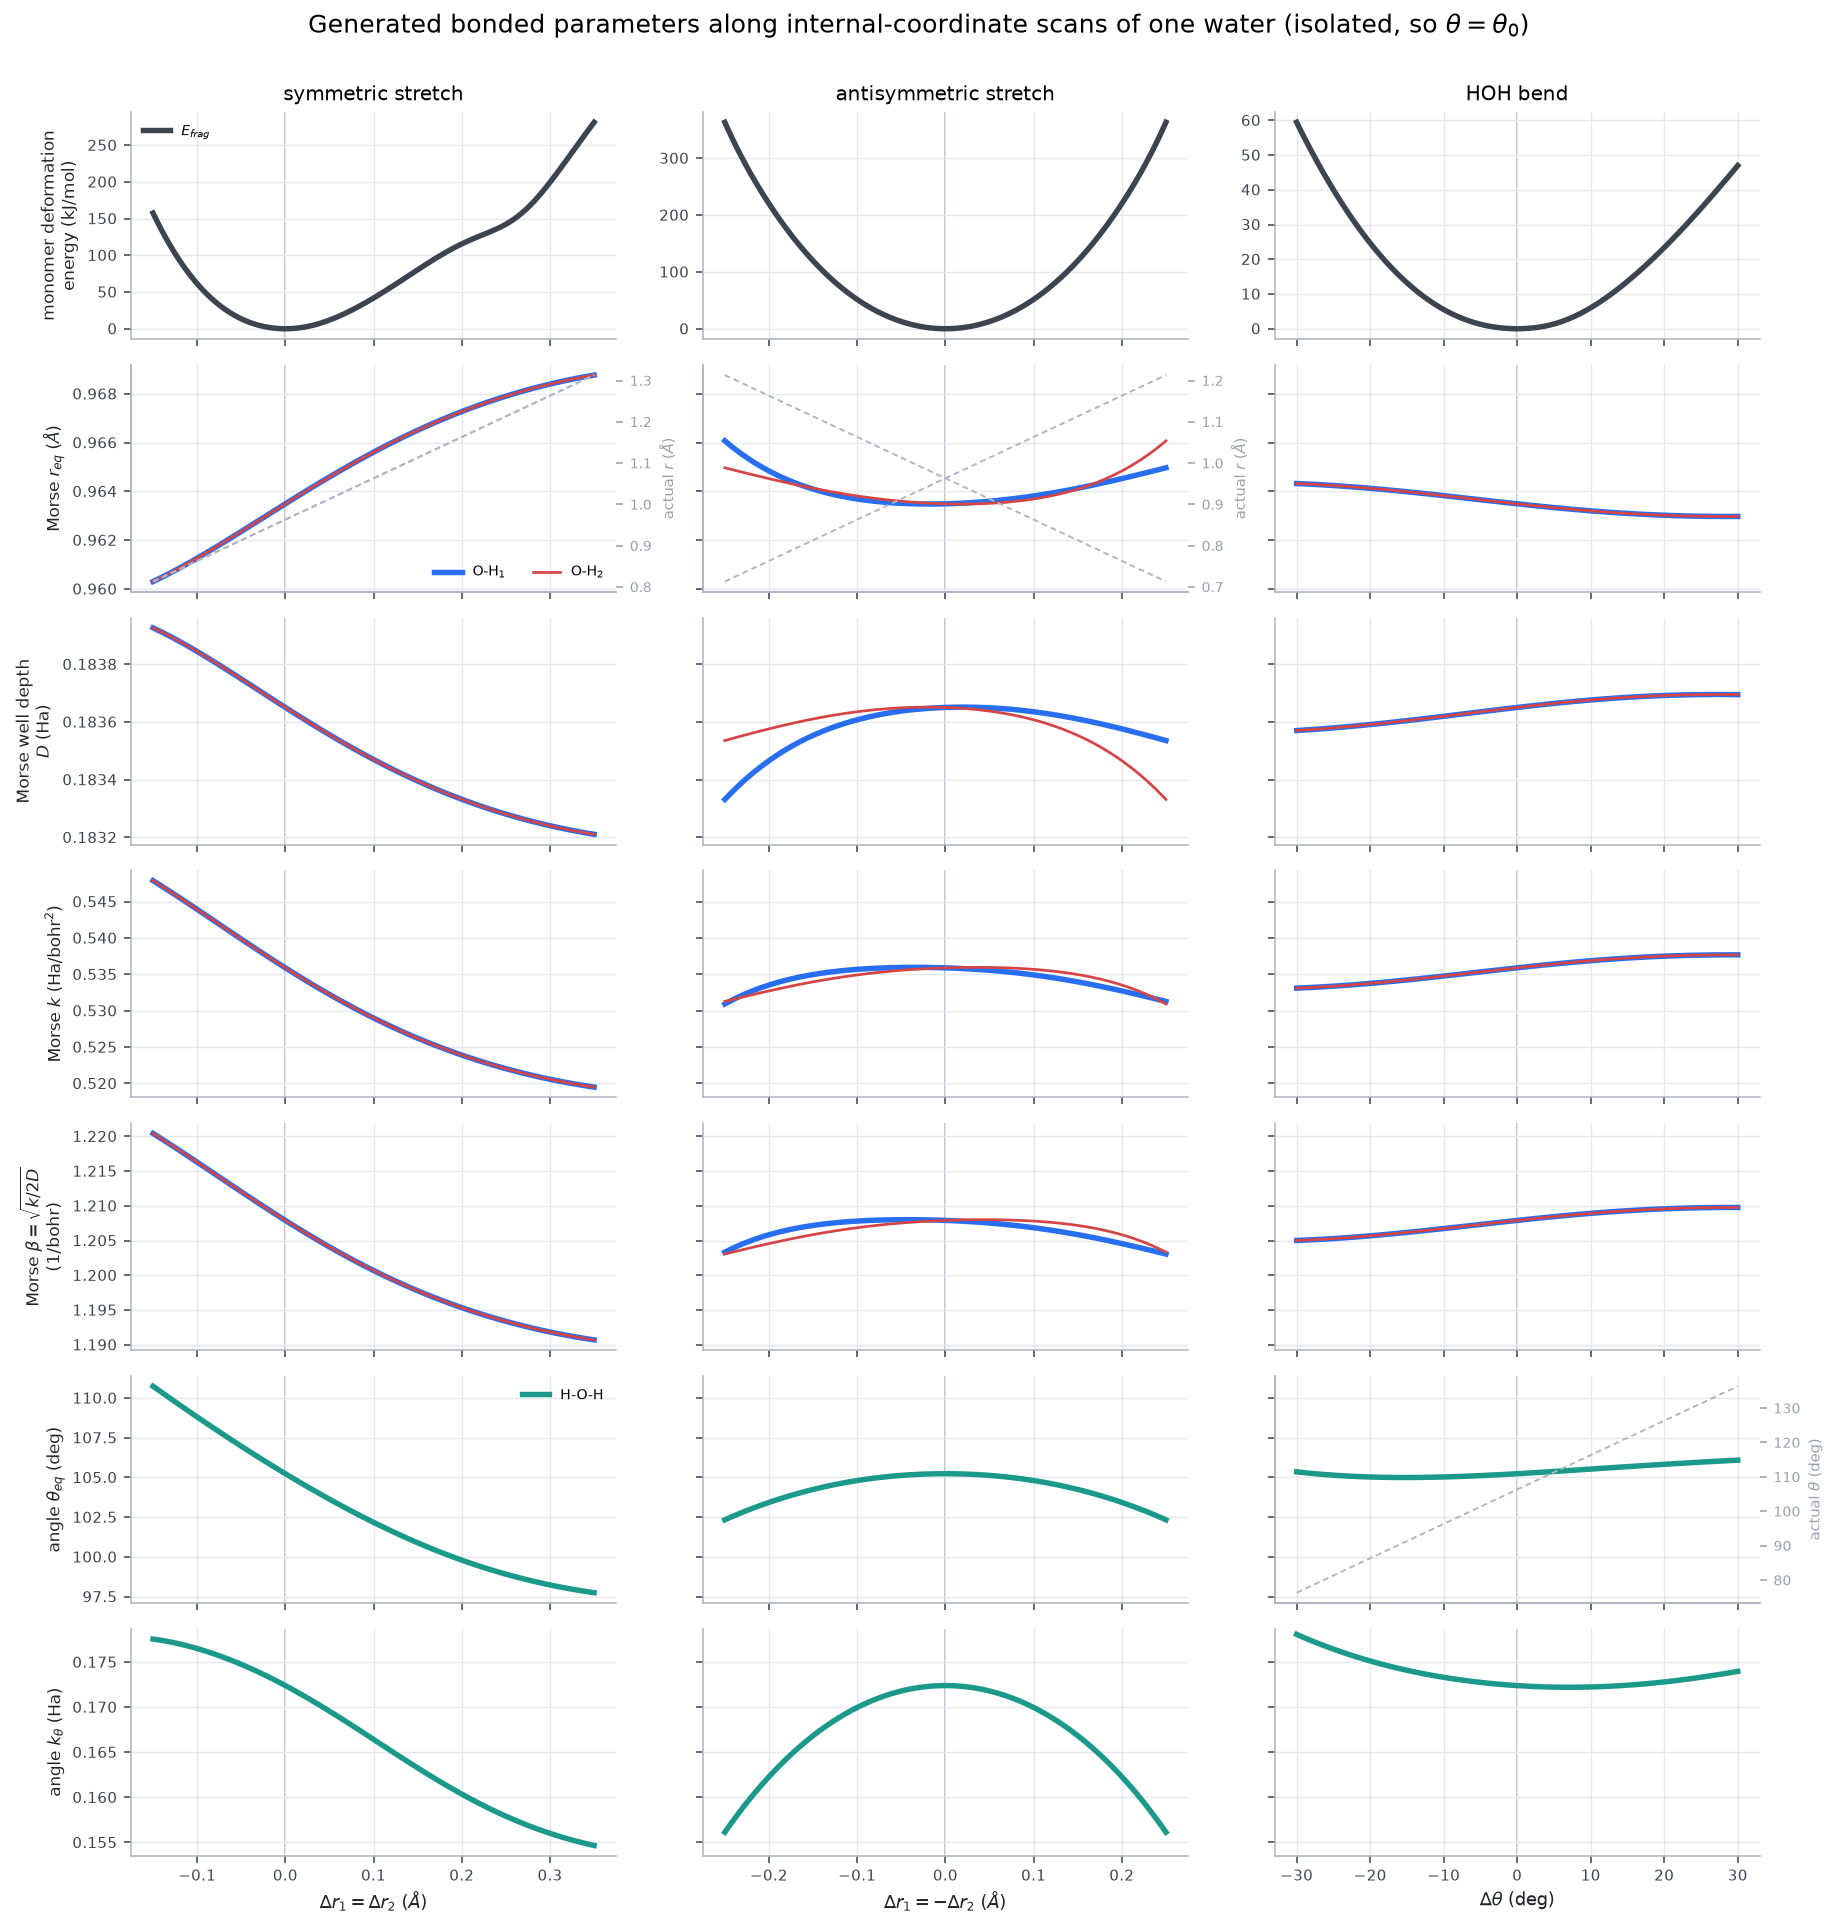

In [291]:
#: (row label, [(key, series label, color), ...], scan keys for the grey twin axis, legend?).
# One row per *unit* rather than per parameter: both O-H bonds share every Morse panel, which
# is what makes the antisymmetric column legible -- the two curves separate there and nowhere
# else. O-H_1 is drawn thick and O-H_2 thin on top, so the degenerate columns show as one
# line with a halo rather than as a single curve hiding its twin.
BOND_COLORS = ("#276ef1", "#d64545")
SCAN_ROWS = [
    ("monomer deformation\nenergy (kJ/mol)",
     [("energy", "$E_{frag}$", "#3c4450")], (), True),
    ("Morse $r_{eq}$ ($\\AA$)",
     [("r_eq_1", "O-H$_1$", BOND_COLORS[0]), ("r_eq_2", "O-H$_2$", BOND_COLORS[1])],
     ("r1", "r2"), True),
    ("Morse well depth\n$D$ (Ha)",
     [("d_1", "O-H$_1$", BOND_COLORS[0]), ("d_2", "O-H$_2$", BOND_COLORS[1])], (), False),
    ("Morse $k$ (Ha/bohr$^2$)",
     [("k_1", "O-H$_1$", BOND_COLORS[0]), ("k_2", "O-H$_2$", BOND_COLORS[1])], (), False),
    ("Morse $\\beta=\\sqrt{k/2D}$\n(1/bohr)",
     [("beta_1", "O-H$_1$", BOND_COLORS[0]), ("beta_2", "O-H$_2$", BOND_COLORS[1])],
     (), False),
    ("angle $\\theta_{eq}$ (deg)", [("theta_eq", "H-O-H", "#1b998b")], ("theta",), True),
    ("angle $k_\\theta$ (Ha)", [("k_theta", "H-O-H", "#1b998b")], (), False),
]

_TWIN_LABEL = {"r1": "actual $r$ ($\\AA$)", "theta": "actual $\\theta$ (deg)"}


def plot_bonded_scans(scans, path=None):
    """The generated bonded parameters along three internal-coordinate scans.

    Columns are the scans; rows are the parameters, grouped so everything sharing a unit
    shares a panel *and* -- except for the energy row, where the antisymmetric branch is an
    order of magnitude steeper than the bend and would flatten it -- a y range across all
    three columns. A parameter that moves under one scan and not another then says so by the
    shape of the row rather than by its axis limits.

    Zero on every x axis is the model's own relaxed monomer. Where the scanned coordinate
    itself belongs on a row (bond length, angle) it is drawn on a grey dashed twin axis, and
    the two scales are the actual diagnostic: the heads never see `r` or `theta`, and a
    generated `r_eq` that tracked the instantaneous bond length would mean the Morse form is
    decorative. It moves by ~1% of what the coordinate does.
    """
    ncols = len(SCAN_SPECS)
    fig, axes = plt.subplots(
        len(SCAN_ROWS), ncols, figsize=(4.4 * ncols, 1.95 * len(SCAN_ROWS)),
        sharex="col", squeeze=False,
    )
    for col, (key, title, xlabel, _grid, _build) in enumerate(SCAN_SPECS):
        scan = scans[key]
        x = scan["x"]
        for row, (ylabel, series, twin_keys, legend) in enumerate(SCAN_ROWS):
            ax = axes[row][col]
            ax.axvline(0.0, color="#b9bfca", lw=1.0, zorder=0)
            # Only twin an axis whose coordinate actually moves: the bend holds `r` fixed and
            # the stretches hold `theta` fixed, and a twin axis over a constant is an
            # offset-notation label with nothing behind it.
            live = [k for k in twin_keys if np.ptp(scan[k]) > 1e-9]
            if live:
                tw = ax.twinx()
                tw.grid(False)
                for tk in live:
                    tw.plot(x, scan[tk], color="#b0b6c2", lw=1.0, ls=(0, (3, 2)), zorder=1)
                tw.tick_params(axis="y", colors="#9aa1ad", labelsize=7)
                tw.set_ylabel(_TWIN_LABEL[live[0]], color="#9aa1ad", fontsize=7.5)
            for width, (skey, slabel, color) in zip((2.8, 1.4), series):
                y = scan[skey]
                if skey == "energy":
                    y = (y - y[np.argmin(np.abs(x))]) * KJMOL_PER_HARTREE
                ax.plot(x, y, color=color, lw=width, label=slabel, zorder=3)
            if col == 0:
                ax.set_ylabel(ylabel, fontsize=8.5)
            if row == 0:
                ax.set_title(title, fontsize=10.5)
            if row == len(SCAN_ROWS) - 1:
                ax.set_xlabel(xlabel, fontsize=9)
            ax.tick_params(labelsize=7.5)
            if col == 0 and legend:
                ax.legend(frameon=False, fontsize=7, ncol=2)

    # Share y per row by hand rather than through `sharey`, so the energy row can opt out.
    for row, (_label, _series, _twin, _legend) in enumerate(SCAN_ROWS):
        if row == 0:
            continue
        lo = min(axes[row][c].get_ylim()[0] for c in range(ncols))
        hi = max(axes[row][c].get_ylim()[1] for c in range(ncols))
        for c in range(ncols):
            axes[row][c].set_ylim(lo, hi)
            if c:
                axes[row][c].set_yticklabels([])

    fig.suptitle(
        "Generated bonded parameters along internal-coordinate scans of one water "
        "(isolated, so $\\theta = \\theta_0$)",
        y=1.004, fontsize=13,
    )
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


fig = plot_bonded_scans(scans, path=FIGDIR / f"{FIGPREFIX}_bonded_parameter_scans.png")
plt.show()

## The dimer: induction, and where the environment actually goes

The monomer scans can only ever show `theta_0` -- a lone fragment has `gate == 0` by
construction, so `theta == theta_0` bitwise. This is the complementary figure. One dimer is
relaxed on the model's own **total** energy, then pulled apart rigidly along O-O with both
monomers' internal geometries frozen, so `theta_0` cannot move (asserted in the cell, not
assumed) and every solid-to-dashed gap is environment dependence and nothing else.

The induction channel splits exactly the way `model.py` assembles it:

    E_ind = [ coupled solve - the same functional at zero response ]   <- direct
          + sum_f [ E_bonded(theta) - E_bonded(theta_0) ]              <- bonded

The second term is the learned analogue of pyCMM's field-dependent Morse, and the first panel
is the only place in this notebook where the two are weighed against each other.

What to look for:

- **the bonded share** (grey twin axis on the first panel). On this checkpoint it is ~65% at
  the minimum: most of the dimer's induction is being booked as a shift in the Morse
  parameters rather than as multipole response. Whether that is the physics or a
  misallocation is a fit question, but the figure is where it becomes visible.
- **the two halves have different ranges.** The bonded term is multiplied by `g(a_env)`, which
  is identically zero past ~5 A, so it switches off completely; the coupled solve runs on the
  `elst` gate and keeps a tail well beyond that. Induction at long range is therefore pure
  multipole response by construction.
- **which bond responds.** The donating O-H is the one that moves -- `r_eq` up ~0.008 A and
  `k` down sharply into the wall -- while the donor's free O-H barely notices. That
  asymmetry is not in the topology anywhere; it comes entirely through the features.
- **the non-monotonic `k` and `beta`.** Both rise above their isolated value around 3.2-3.5 A
  before turning over and collapsing at contact, so the environment stiffens the bond at
  hydrogen-bond distances and softens it only once the monomers are pressed together.
- **the acceptor's two O-H bonds lying exactly on top of each other.** The relaxed dimer is
  Cs, they are mirror images, and the head's permutation symmetry reproduces that with no
  symmetrization anywhere in the loss.

In [292]:
# ---- The water dimer: what the environment does to the bonded parameters ---------------
# The monomer scans above can only ever show `theta_0`; a lone fragment has `gate == 0` by
# construction. This is the other half -- one dimer, relaxed on the model's own total energy,
# then pulled apart rigidly along O-O. Only the *environment* changes along the scan: each
# monomer's internal geometry is frozen, so `theta_0` is constant to machine precision and
# every solid-to-dashed gap in the figure below is environment dependence and nothing else.
#
# The induction channel splits exactly, straight off `FilmOutput` (`model.py`):
#
#     E_ind = [ coupled solve - the same functional at zero response ]   <- direct
#           + sum_f [ E_bonded(theta) - E_bonded(theta_0) ]              <- bonded
#
# the second piece being the learned analogue of pyCMM's field-dependent Morse.

#: canonical dimer atom order: donor O, donating H, free H | acceptor O, H, H.
DIMER_Z = (8, 1, 1, 8, 1, 1)
DIMER_SITES = ["O$_D$", "H$_D$(bonded)", "H$_D$(free)", "O$_A$", "H$_A$", "H$_A'$"]


def dimer_batch(positions, device=None):
    """A `Batch` of dimers in `DIMER_Z` order, two fragments per frame."""
    n = positions.shape[0]
    batch = Batch(
        positions=positions.reshape(-1, 3),
        atomic_numbers=torch.tensor(DIMER_Z, dtype=torch.long).repeat(n),
        batch_idx=torch.arange(n).repeat_interleave(6),
        n_systems=n,
        energy=torch.zeros(n),
        fragment_idx=(torch.tensor([0, 0, 0, 1, 1, 1]).repeat(n)
                      + torch.arange(n).repeat_interleave(6) * 2),
        fragment_to_batch=torch.arange(n).repeat_interleave(2),
        n_fragments=2 * n,
    )
    return batch if device is None else batch.to(device)


def canonical_dimer(dataset):
    """The strongest-binding frame of a w2 set, reordered into `DIMER_Z`.

    Donor and acceptor are identified by the shortest *inter*-fragment O-H contact -- the
    fragment that owns that H is the donor, and that H is its bonded one. Fixing the layout
    here is what lets every later panel label a curve by chemical role instead of by whatever
    order the topology enumeration happened to produce.
    """
    batch = dataset.flat_batch(range(len(dataset)))
    key = batch.eda["int"] if batch.eda and "int" in batch.eda else batch.energy
    frame = dataset.flat_batch([int(to_np(key).argmin())])
    pos, z, frag = frame.positions, frame.atomic_numbers, frame.fragment_idx
    o = torch.nonzero(z == 8).flatten()
    h = torch.nonzero(z == 1).flatten()
    inter = frag[h].unsqueeze(1) != frag[o].unsqueeze(0)
    d = torch.where(inter, torch.cdist(pos[h], pos[o]), torch.full((len(h), len(o)), 1e9))
    donor = int(frag[h[int(torch.argmin(d) // len(o))]])
    h_bonded = int(h[int(torch.argmin(d) // len(o))])
    pick = lambda seq, f: [int(x) for x in seq if int(frag[x]) == f]
    order = ([pick(o, donor)[0], h_bonded]
             + [x for x in pick(h, donor) if x != h_bonded]
             + [pick(o, 1 - donor)[0]] + pick(h, 1 - donor))
    assert tuple(int(v) for v in z[order]) == DIMER_Z
    return pos[order].reshape(1, 6, 3)


def relax_dimer(model, device, positions):
    """Minimize the model's **total** energy over all 6 atoms -- induction included.

    The equilibrium the scan starts from has to be this model's, not a reference geometry:
    the whole figure is about how a quantity behaves around a stationary point, and around
    someone else's stationary point the leading term is a gradient that should not be there.
    """
    q = positions.reshape(-1).clone().to(device).requires_grad_(True)
    opt = torch.optim.LBFGS([q], lr=0.2, max_iter=400, tolerance_grad=1e-11,
                            tolerance_change=1e-16, line_search_fn="strong_wolfe")

    def closure():
        opt.zero_grad()
        e = model(dimer_batch(q.reshape(1, 6, 3), device)).energy.sum()
        e.backward()
        return e

    opt.step(closure)
    return q.detach().reshape(6, 3)


def scan_dimer_separation(model, device, eq_positions, grid, batch_size=BATCH_SIZE):
    """Rigidly translate the acceptor along O-O; return everything both evaluations carry.

    Rigid on purpose. A relaxed scan would let the monomers deform, and the `theta_0` curves
    would move for a reason that has nothing to do with the environment -- exactly the
    confound this figure exists to remove.
    """
    axis = (eq_positions[3] - eq_positions[0])
    axis = axis / axis.norm()
    r_oo_eq = float((eq_positions[3] - eq_positions[0]).norm())
    # Put the exact equilibrium on the grid, so the panel's reference line and the numbers
    # printed below are the same point rather than the nearest sample to it.
    grid = np.union1d(np.asarray(grid, dtype=float), [r_oo_eq])
    offset = torch.as_tensor(grid - r_oo_eq).reshape(-1, 1, 1) * axis.reshape(1, 1, 3)
    positions = eq_positions.reshape(1, 6, 3).repeat(len(grid), 1, 1).clone()
    positions[:, 3:, :] = positions[:, 3:, :] + offset

    cols = {}
    def push(**kv):
        for k, v in kv.items():
            cols.setdefault(k, []).append(v)

    for start in range(0, len(grid), batch_size):
        sl = slice(start, start + batch_size)
        batch = dimer_batch(positions[sl].to(device), device)
        with torch.no_grad():
            out = model(batch)
        n = batch.n_systems
        # The exact split: everything not carried by the bonded shift is the coupled solve.
        bonded = to_np(out.energy_bonded_env - out.energy_bonded).reshape(n, 2).sum(1)
        total = to_np(out.interaction["induction"])
        push(ind_total=total * KJMOL_PER_HARTREE,
             ind_bonded=bonded * KJMOL_PER_HARTREE,
             ind_direct=(total - bonded) * KJMOL_PER_HARTREE,
             gate=to_np(out.parameters.gate).reshape(n, 6))
        for tag, p in (("", out.parameters.bonded), ("0", out.parameters.bonded0)):
            push(**{
                f"r_eq{tag}": to_np(p.r_eq).reshape(n, 4) * BOHR_ANG,
                f"d{tag}": to_np(p.d).reshape(n, 4),
                f"k{tag}": to_np(p.k).reshape(n, 4),
                f"beta{tag}": to_np(torch.sqrt(p.k / (2.0 * p.d))).reshape(n, 4),
                f"theta_eq{tag}": np.degrees(
                    to_np(p.cos_theta_eq.clamp(-1, 1).arccos())).reshape(n, 2),
                f"k_theta{tag}": to_np(p.k_theta).reshape(n, 2),
            })
    scan = {k: np.concatenate(v) for k, v in cols.items()}
    scan["x"] = grid
    scan["r_oo_eq"] = r_oo_eq
    return scan


DIMER_GRID = np.linspace(2.55, 6.0, 139)

dimer_eq = relax_dimer(model, device, canonical_dimer(datasets["w2"]).to(device))
dimer = scan_dimer_separation(model, device, dimer_eq, DIMER_GRID)

_i_eq = int(np.argmin(np.abs(dimer["x"] - dimer["r_oo_eq"])))
print(f"relaxed dimer: R(O-O) = {dimer['r_oo_eq']:.4f} A")
with torch.no_grad():
    _eq_out = model(dimer_batch(dimer_eq.reshape(1, 6, 3), device))
print("  " + "   ".join(f"{k} {float(v) * KJMOL_PER_HARTREE:.3f}"
                        for k, v in _eq_out.interaction.items()) + "  kJ/mol")
print(f"\ninduction at equilibrium: {dimer['ind_total'][_i_eq]:.4f} kJ/mol"
      f"   = direct {dimer['ind_direct'][_i_eq]:.4f}"
      f" + bonded {dimer['ind_bonded'][_i_eq]:.4f}"
      f"  ({100 * dimer['ind_bonded'][_i_eq] / dimer['ind_total'][_i_eq]:.1f}% bonded)")

# The scan is rigid, so the isolated branch must not move at all. Asserted, not assumed:
# a nonzero spread here would mean an environment path had leaked into `theta_0`.
_drift = max(float(np.ptp(dimer[f"{k}0"], axis=0).max())
             for k in ("r_eq", "d", "k", "theta_eq", "k_theta"))
assert _drift < 1e-10, f"theta_0 moved along a rigid scan by {_drift:.2e}"
print(f"theta_0 drift along the rigid scan: {_drift:.1e} (must be ~0)")
print(f"gate g(a_env) at equilibrium: "
      f"{np.array2string(dimer['gate'][_i_eq], precision=3)}   at {DIMER_GRID[-1]:.1f} A: "
      f"{np.array2string(dimer['gate'][-1], precision=3)}")

relaxed dimer: R(O-O) = 2.7887 A
  elst -50.486   pauli 53.348   disp -9.144   induction -17.703  kJ/mol

induction at equilibrium: -17.7025 kJ/mol   = direct -6.0234 + bonded -11.6791  (66.0% bonded)
theta_0 drift along the rigid scan: 1.4e-14 (must be ~0)
gate g(a_env) at equilibrium: [0.803 0.931 0.536 0.882 0.802 0.802]   at 6.0 A: [0. 0. 0. 0. 0. 0.]


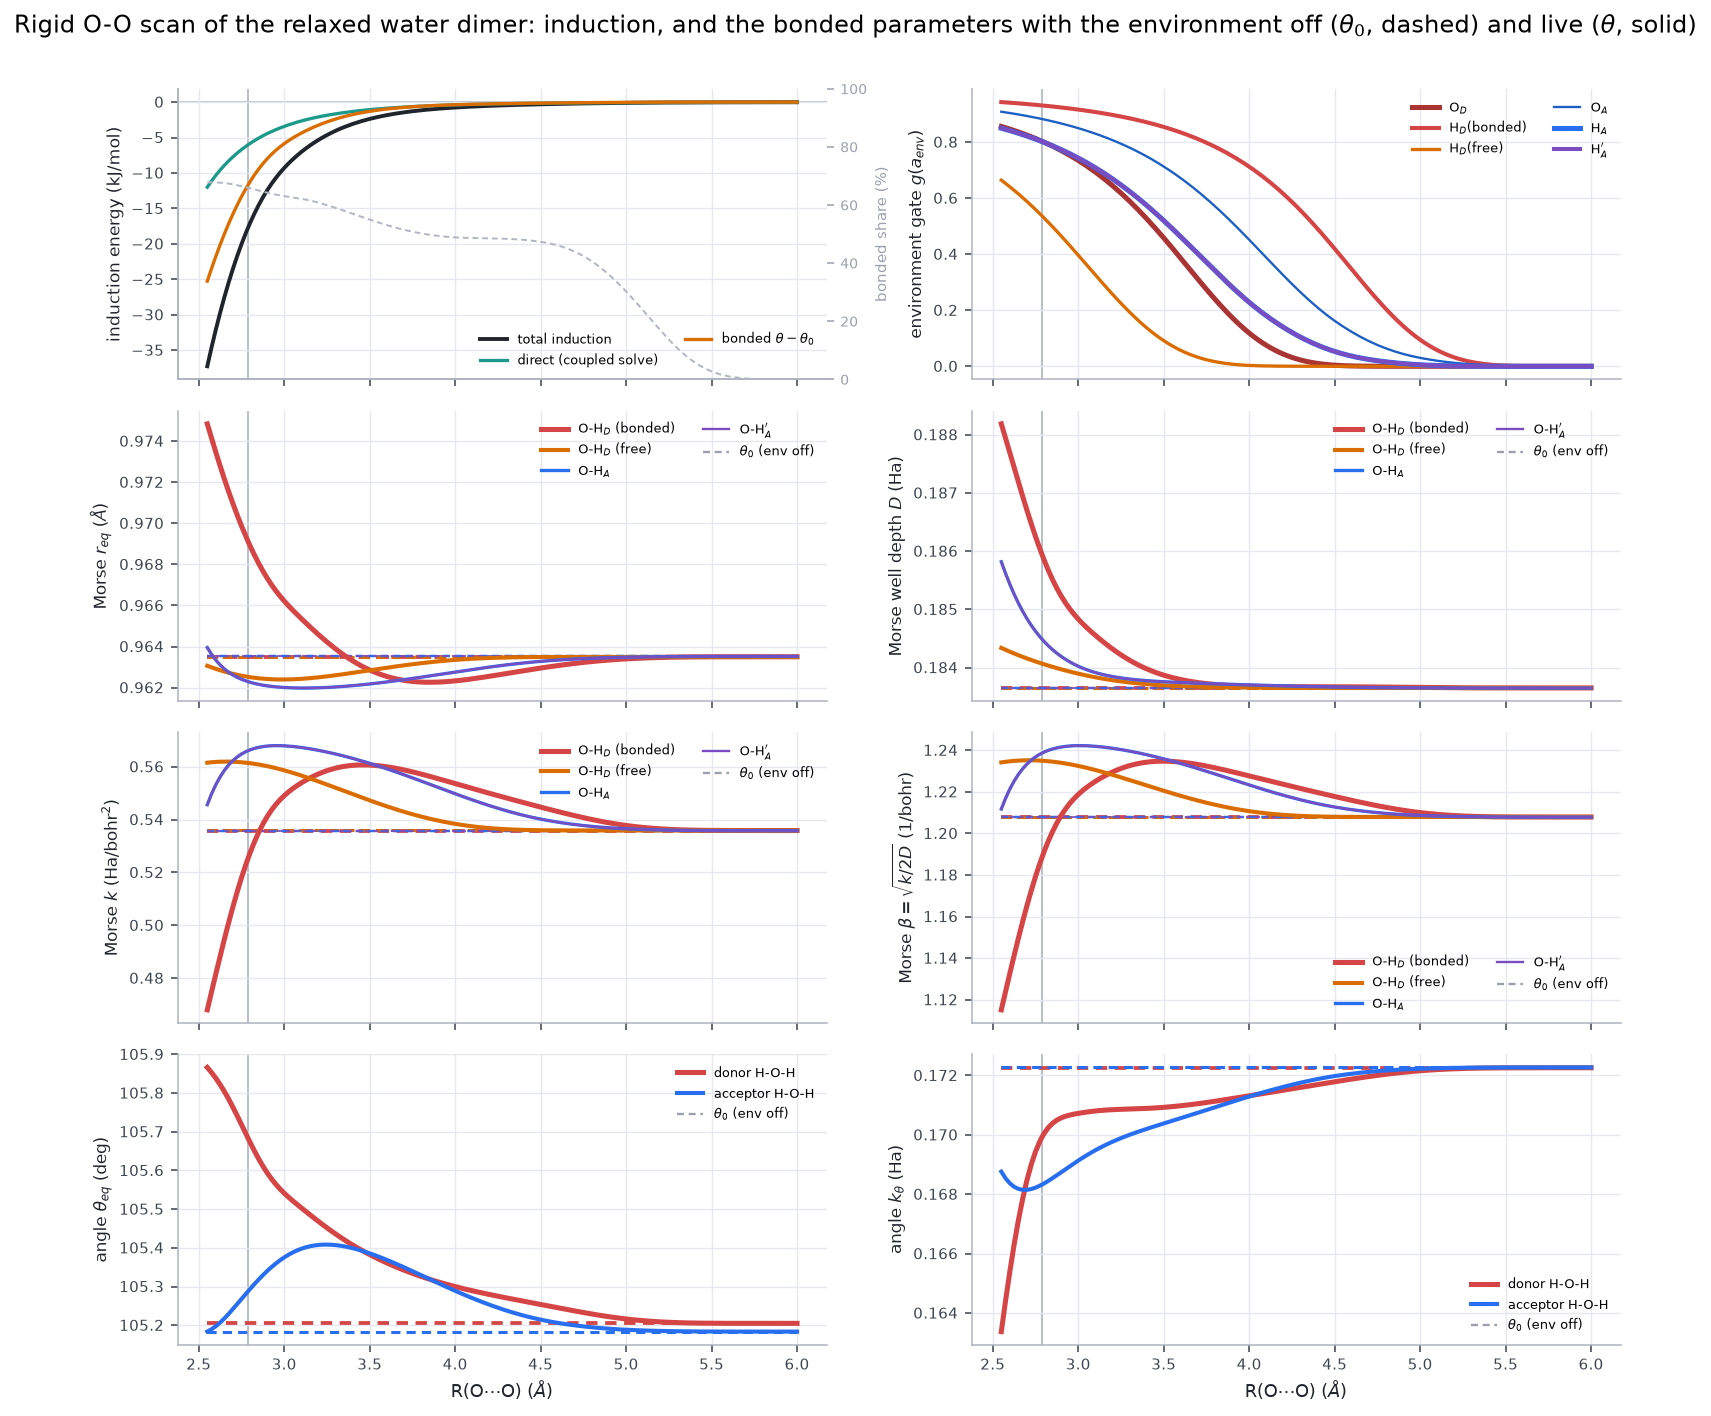

In [293]:
#: the four bonds and two angles, in the fixed order `DIMER_Z` forces on the topology.
DIMER_BONDS = [
    ("O-H$_D$ (bonded)", "#d64545"),
    ("O-H$_D$ (free)", "#db6d00"),
    ("O-H$_A$", "#276ef1"),
    ("O-H$_A'$", "#7a4cc2"),
]
DIMER_ANGLES = [("donor H-O-H", "#d64545"), ("acceptor H-O-H", "#276ef1")]

#: (key, y label, series); `None` marks the two hand-written panels.
DIMER_PANELS = [
    (None, "induction energy (kJ/mol)", "induction"),
    ("gate", "environment gate $g(a_{env})$", DIMER_SITES),
    ("r_eq", "Morse $r_{eq}$ ($\\AA$)", DIMER_BONDS),
    ("d", "Morse well depth $D$ (Ha)", DIMER_BONDS),
    ("k", "Morse $k$ (Ha/bohr$^2$)", DIMER_BONDS),
    ("beta", "Morse $\\beta=\\sqrt{k/2D}$ (1/bohr)", DIMER_BONDS),
    ("theta_eq", "angle $\\theta_{eq}$ (deg)", DIMER_ANGLES),
    ("k_theta", "angle $k_\\theta$ (Ha)", DIMER_ANGLES),
]
SITE_COLORS = ["#a33", "#d64545", "#db6d00", "#1b5fc4", "#276ef1", "#7a4cc2"]

#: descending widths, so a curve that coincides with an earlier one still shows through. The
#: relaxed dimer is Cs, which makes the acceptor's two O-H bonds exact mirror images -- they
#: are *supposed* to lie on top of each other, and the figure has to show that rather than
#: silently paint one over the other.
_STAGGER = (2.6, 2.1, 1.7, 1.2)


def plot_dimer_scan(dimer, path=None, ncols=2):
    """Induction and the bonded parameters along a rigid O-O scan of the relaxed dimer.

    Solid is `theta` (environment live), dashed is `theta_0` (environment off). Because the
    scan is rigid the dashed lines are exactly flat, so the figure reads as one question per
    panel: how far does the environment pull this parameter off its isolated value, and how
    fast does that decay with separation.

    The first panel is where it lands energetically -- the induction channel split into the
    coupled-solve response and the bonded-parameter shift, the two terms `model.py` actually
    adds together. The grey twin axis is the bonded share, which is the quickest read on
    whether this model is doing its polarization through the multipoles or through the bonds.
    """
    nrows = int(np.ceil(len(DIMER_PANELS) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.6 * ncols, 2.5 * nrows),
                             sharex=True, squeeze=False)
    x, r_eq_oo = dimer["x"], dimer["r_oo_eq"]
    for ax, (key, ylabel, series) in zip(axes.ravel(), DIMER_PANELS):
        ax.axvline(r_eq_oo, color="#b9bfca", lw=1.0, zorder=0)
        if key is None:
            for name, label, color in (
                ("ind_total", "total induction", "#20242c"),
                ("ind_direct", "direct (coupled solve)", "#1b998b"),
                ("ind_bonded", "bonded $\\theta-\\theta_0$", "#db6d00"),
            ):
                ax.plot(x, dimer[name], color=color, lw=2.0 if name == "ind_total" else 1.7,
                        label=label, zorder=3)
            ax.axhline(0.0, color="#aeb4c0", lw=0.8, zorder=1)
            tw = ax.twinx()
            tw.grid(False)
            share = 100 * dimer["ind_bonded"] / np.where(
                np.abs(dimer["ind_total"]) > 1e-6, dimer["ind_total"], np.nan)
            tw.plot(x, share, color="#b0b6c2", lw=1.0, ls=(0, (3, 2)), zorder=1)
            tw.set_ylim(0, 100)
            tw.set_ylabel("bonded share (%)", color="#9aa1ad", fontsize=7.5)
            tw.tick_params(axis="y", colors="#9aa1ad", labelsize=7)
        elif key == "gate":
            # Single-valued by definition: g(a_env) *is* the environment, and there is no
            # isolated counterpart to dash against.
            for col, (label, color) in enumerate(zip(series, SITE_COLORS)):
                ax.plot(x, dimer["gate"][:, col], color=color,
                        lw=_STAGGER[col % len(_STAGGER)], label=label, zorder=3)
        else:
            for col, (label, color) in enumerate(series):
                lw = _STAGGER[col % len(_STAGGER)]
                ax.plot(x, dimer[key][:, col], color=color, lw=lw, label=label, zorder=3)
                ax.plot(x, dimer[f"{key}0"][:, col], color=color, lw=0.75 * lw,
                        ls=(0, (3, 2)), zorder=2, label="_nolegend_")
            ax.plot([], [], color="#9aa1ad", lw=1.2, ls=(0, (3, 2)),
                    label="$\\theta_0$ (env off)")
        ax.set_ylabel(ylabel, fontsize=8.5)
        ax.tick_params(labelsize=7.5)
        ax.legend(frameon=False, fontsize=6.8, ncol=2 if len(series) > 3 else 1)
    for ax in axes[-1]:
        ax.set_xlabel("R(O$\\cdots$O) ($\\AA$)", fontsize=9)
    fig.suptitle(
        "Rigid O-O scan of the relaxed water dimer: induction, and the bonded parameters "
        "with the environment off ($\\theta_0$, dashed) and live ($\\theta$, solid)",
        y=1.005, fontsize=12.5,
    )
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


fig = plot_dimer_scan(dimer, path=FIGDIR / f"{FIGPREFIX}_dimer_induction_scan.png")
plt.show()

In [294]:
class EnergyTermModel(torch.nn.Module):
    def __init__(self, model, term):
        super().__init__()
        self.model = model
        self.term = term

    def forward(self, batch):
        out = self.model(batch)
        if self.term == "total":
            # For the MBE plot, the total binding contribution beyond pairwise is the
            # interaction sum. One-body deformation cancels only if singleton terms are
            # included; this helper's convention is E(singleton) = 0.
            energy = out.energy.new_zeros(out.energy.shape)
            for value in out.interaction.values():
                energy = energy + value
        elif self.term == "onebody":
            energy = pool_fragments_to_frames(out.fragment_energy, batch)
        else:
            energy = out.interaction[self.term]
        return SimpleNamespace(energy=energy)


def strongest_indices(dataset, n, key=MBE_SORT_KEY):
    batch = dataset.flat_batch(range(len(dataset)))
    if batch.eda is not None and key in batch.eda:
        values = to_np(batch.eda[key])
    else:
        values = to_np(batch.energy)
    return np.argsort(values)[:min(n, len(values))].tolist()


def collect_many_body_by_term(model, datasets, terms=None, per_cluster=MBE_PER_CLUSTER):
    if terms is None:
        terms = ["elst", "pauli", "disp"]
        if model.induction:
            terms.append("induction")
        terms.append("total")
    rows = []
    for term in terms:
        if term != "total" and term not in model.classical and term not in ("induction", "onebody"):
            continue
        wrapped = EnergyTermModel(model, term).to(next(model.parameters()).device)
        # Every one of the 2^N fragment subsets is evaluated, so this has to stay on the
        # small clusters -- w6 is already 57 subsets per frame, w23 is 8 million. Selected by
        # size rather than by a hardcoded tag list, which stopped matching once colliding
        # tags grew a directory suffix (`w4` -> `w4/original`).
        small = [t for t in datasets if 3 <= cluster_size(t) <= MBE_MAX_FRAGMENTS]
        for tag in sorted(small, key=cluster_size):
            ds = datasets[tag]
            idx = strongest_indices(ds, per_cluster)
            res = mbe_dataset(wrapped, ds, idx, split_components=False, progress_every=0)
            k = KJMOL_PER_HARTREE
            for i in range(len(idx)):
                row = {
                    "term": term,
                    "tag": tag,
                    "n_fragments": int(res.n_fragments[i]),
                    "total": float(res.total[i]) * k,
                    "two_body": float(res.two_body[i]) * k,
                    "many_body": float(res.many_body[i]) * k,
                }
                for order in (3, 4, 5):
                    vals = res.by_order.get(order)
                    row[f"e{order}"] = float(vals[i]) * k if vals is not None else 0.0
                rows.append(row)
    return rows


mbe_rows = collect_many_body_by_term(model, datasets)
print(f"many-body rows: {len(mbe_rows)}")
for term in sorted({r['term'] for r in mbe_rows}):
    vals = np.array([r["many_body"] for r in mbe_rows if r["term"] == term])
    per = np.array([r["many_body"] / r["n_fragments"] for r in mbe_rows if r["term"] == term])
    print(f"{term:<8} mean={vals.mean():>9.4f} kJ/mol   mean abs={np.abs(vals).mean():>9.4f}"
          f"   per molecule: mean={per.mean():>8.4f}  mean abs={np.abs(per).mean():>8.4f}")


many-body rows: 620
disp     mean=   0.2005 kJ/mol   mean abs=   0.2005   per molecule: mean=  0.0459  mean abs=  0.0459
elst     mean=   0.0000 kJ/mol   mean abs=   0.0000   per molecule: mean=  0.0000  mean abs=  0.0000
induction mean= -14.4270 kJ/mol   mean abs=  14.4270   per molecule: mean= -3.3340  mean abs=  3.3340
pauli    mean=  -0.5829 kJ/mol   mean abs=   0.6227   per molecule: mean= -0.1371  mean abs=  0.1491
total    mean= -14.8095 kJ/mol   mean abs=  14.8095   per molecule: mean= -3.4252  mean abs=  3.4252


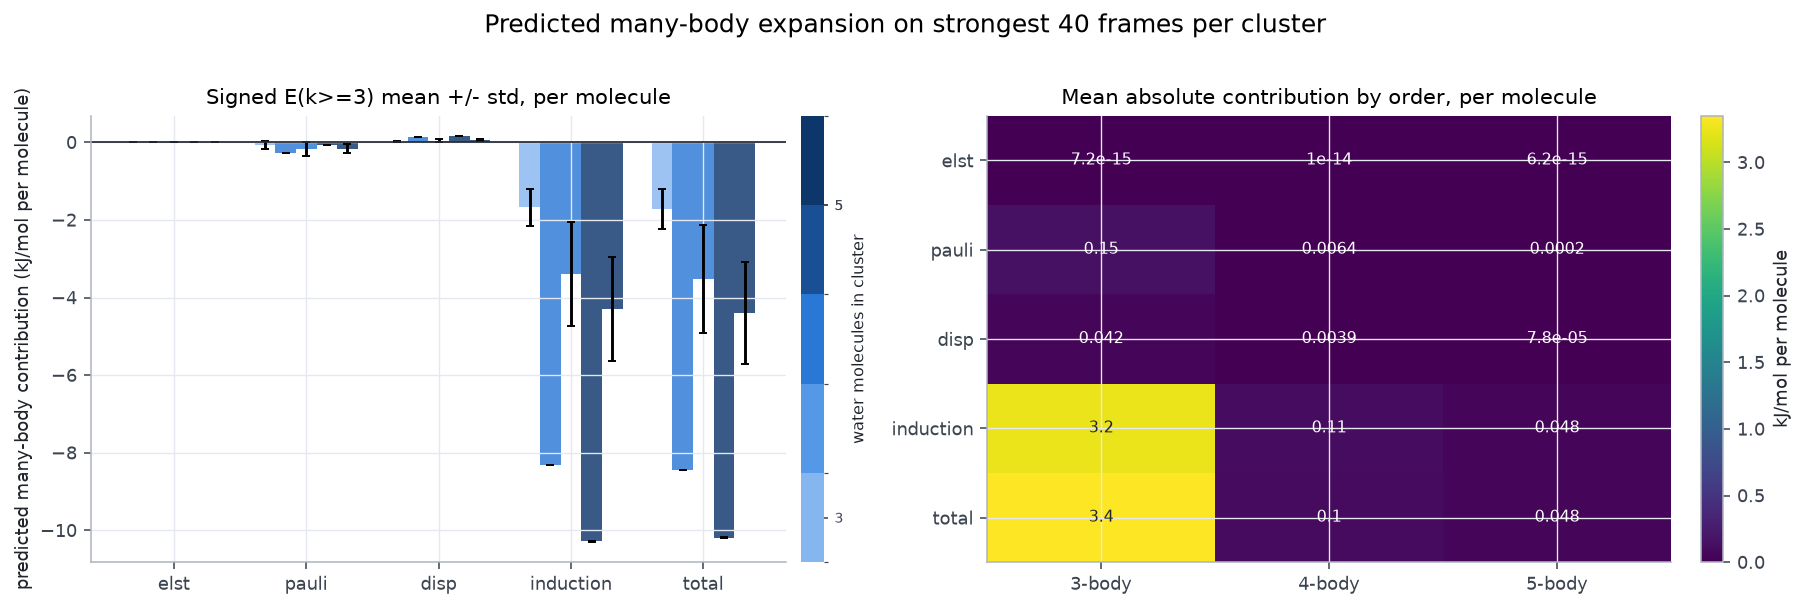

In [295]:
def plot_many_body(rows, path=None):
    terms = [t for t in ["elst", "pauli", "disp", "induction", "total"] if any(r["term"] == t for r in rows)]
    # The MBE evaluates every one of the 2^N fragment subsets, so `collect_many_body_by_term`
    # keeps to the small clusters; this just takes whatever it produced, size-ordered.
    tags = sorted({r["tag"] for r in rows}, key=cluster_size)
    scale = size_scale(tags)
    x = np.arange(len(terms))
    width = 0.78 / max(1, len(tags))
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.2))

    ax = axes[0]
    for j, tag in enumerate(tags):
        means, stds = [], []
        for term in terms:
            # Per molecule: `many_body` is a sum over every subset of size >= 3, so it grows
            # with the cluster on its own and the bars would compare sizes, not physics.
            vals = np.array([r["many_body"] / r["n_fragments"]
                             for r in rows if r["term"] == term and r["tag"] == tag])
            means.append(np.mean(vals) if len(vals) else 0.0)
            stds.append(np.std(vals) if len(vals) else 0.0)
        ax.bar(x + (j - (len(tags) - 1) / 2) * width, means, width=width,
               yerr=stds, capsize=2, color=tag_color(tag, scale), alpha=0.82)
    ax.axhline(0.0, color="#242934", lw=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(terms)
    ax.set_ylabel("predicted many-body contribution (kJ/mol per molecule)")
    ax.set_title("Signed E(k>=3) mean +/- std, per molecule")
    add_size_colorbar(fig, ax, scale, fraction=0.05, pad=0.02, aspect=20)

    ax = axes[1]
    orders = ["e3", "e4", "e5"]
    image = np.zeros((len(terms), len(orders)))
    for i, term in enumerate(terms):
        for j, order in enumerate(orders):
            vals = np.array([r[order] / r["n_fragments"]
                             for r in rows if r["term"] == term])
            image[i, j] = np.mean(np.abs(vals)) if len(vals) else 0.0
    im = ax.imshow(image, aspect="auto", cmap="viridis")
    ax.set_yticks(np.arange(len(terms)))
    ax.set_yticklabels(terms)
    ax.set_xticks(np.arange(len(orders)))
    ax.set_xticklabels(["3-body", "4-body", "5-body"])
    ax.set_title("Mean absolute contribution by order, per molecule")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("kJ/mol per molecule")
    for i in range(len(terms)):
        for j in range(len(orders)):
            # viridis runs dark-purple (low) to yellow (high), so the ink has to go light on
            # LOW cells and dark on HIGH ones. The inverse of this put dark text on the dark
            # end and white text on the yellow -- both unreadable.
            ax.text(j, i, f"{image[i, j]:.2g}", ha="center", va="center",
                    color="#20242c" if image[i, j] > image.max() * 0.55 else "white",
                    fontsize=8)

    fig.suptitle(f"Predicted many-body expansion on strongest {MBE_PER_CLUSTER} frames per cluster", y=1.02, fontsize=13)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig

fig = plot_many_body(mbe_rows, path=FIGDIR / f"{FIGPREFIX}_many_body_by_term.png")
plt.show()


In [296]:
def collect_force_predictions(model, datasets, cfg, device, n_frames=FORCE_FRAMES_PER_CLUSTER):
    ref_parts, pred_parts, tags = [], [], []
    for tag, ds in datasets.items():
        if not ds.has_forces:
            print(f"{tag}: no force labels; skipping")
            continue
        indices = frame_indices(ds, cfg)[:min(n_frames, len(ds))]
        for idx in indices:
            batch = ds.flat_batch([idx]).to(device)
            batch.positions.requires_grad_(True)
            out = model(batch)
            forces = compute_forces(out.energy, batch.positions, create_graph=False)
            ref = to_np(batch.forces) * KJMOL_PER_HARTREE
            pred = to_np(forces) * KJMOL_PER_HARTREE
            ref_parts.append(ref.reshape(-1))
            pred_parts.append(pred.reshape(-1))
            tags.extend([tag] * ref.size)
    return {
        "ref": np.concatenate(ref_parts),
        "pred": np.concatenate(pred_parts),
        "tag": np.asarray(tags),
    }


forces = collect_force_predictions(model, datasets, cfg, device)
mae, rmse, r2 = metrics(forces["ref"], forces["pred"])
print(f"force components: n={len(forces['ref'])}  MAE={mae:.5g}  RMSE={rmse:.5g}  R2={r2:.5f}  unit=kJ/mol/A")


force components: n=15048  MAE=11.45  RMSE=18.316  R2=0.85584  unit=kJ/mol/A


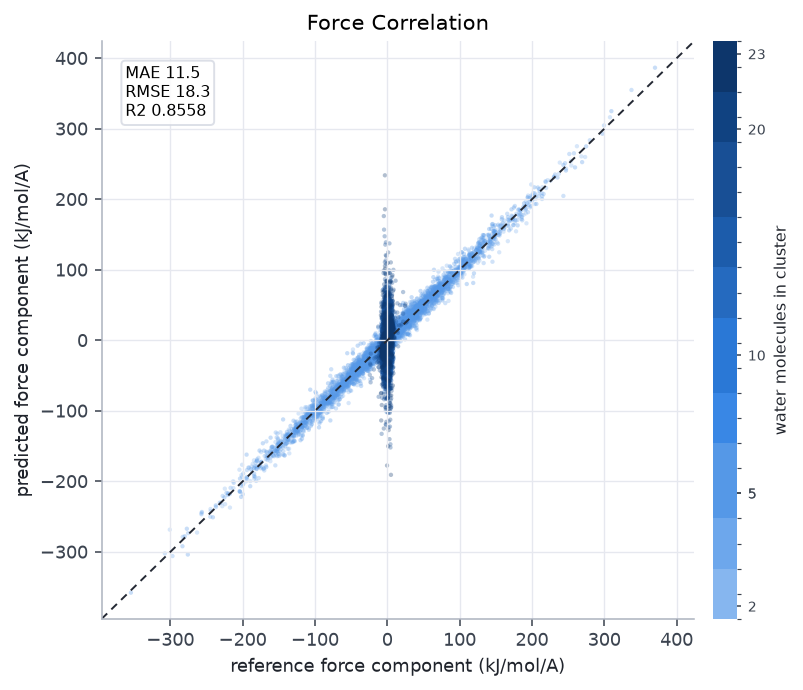

 cluster  |F_ref| med      MAE  MAE/|F_ref|   (kJ/mol/A)
      w2        98.48     5.54         0.06
      w3       104.01     6.26         0.06
w4/original       103.26     6.11         0.06
w4/benchmark         6.91     7.75         1.12
w5/benchmark         7.25    11.05         1.52
w5/original        96.54     6.64         0.07
      w6         6.68    10.05         1.50
      w7         6.81    11.31         1.66
      w8         6.73    11.21         1.67
      w9         6.32    11.23         1.78
     w10         6.79    13.85         2.04
     w11         6.77    12.90         1.91
     w12         6.69    11.02         1.65
     w13         6.53    12.10         1.85
     w14         6.93    12.64         1.82
     w16         6.69    10.37         1.55
     w17        15.09    19.58         1.30
     w18         6.78    14.35         2.12
     w19         6.67    21.28         3.19
     w20         6.71    15.81         2.36
     w21         6.70    21.14         3.16
     

In [297]:
def plot_force_correlation(forces, path=None):
    """Parity of force components, coloured by cluster size.

    **Not** normalized by cluster size, unlike every energy panel here: a force is a per-atom
    derivative, so it is already intensive and dividing it by the fragment count would be
    wrong. What the colour shows instead is the population structure -- the relaxed benchmark
    clusters sit in a tight knot near the origin where the reference force is nearly zero, and
    the thermally sampled w2-w5 frames spread out along the diagonal.
    """
    fig, ax = plt.subplots(figsize=(5.8, 5.0))
    ref, pred, tags = forces["ref"], forces["pred"], forces["tag"]
    scale = size_scale(tags)
    lo = min(ref.min(), pred.min())
    hi = max(ref.max(), pred.max())
    pad = 0.05 * (hi - lo if hi > lo else 1.0)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="#242934", lw=1, ls=(0, (4, 3)))
    order = np.argsort([cluster_size(t) for t in tags], kind="stable")
    ax.scatter(ref[order], pred[order], s=5, alpha=0.32, lw=0,
               color=[tag_color(t, scale) for t in tags[order]], rasterized=True)
    mae, rmse, r2 = metrics(ref, pred)
    ax.text(0.04, 0.96, f"MAE {mae:.3g}\nRMSE {rmse:.3g}\nR2 {r2:.4f}",
            transform=ax.transAxes, ha="left", va="top", fontsize=8,
            bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
    ax.set_xlabel("reference force component (kJ/mol/A)")
    ax.set_ylabel("predicted force component (kJ/mol/A)")
    ax.set_title("Force Correlation")
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    add_size_colorbar(fig, ax, scale, fraction=0.045, pad=0.03, aspect=24)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


def force_population_table(forces):
    """Per cluster, the reference force magnitude against the model's error on it.

    This is the table that explains the vertical spray at `reference ~ 0` in the panel above:
    the benchmark clusters are near-stationary structures whose reference forces are an order
    of magnitude smaller than the thermally sampled w2-w5 frames, while the model's absolute
    error on them is *larger*. The ratio, not the error, is what blows up.
    """
    tags = sorted(set(forces["tag"]), key=cluster_size)
    print(f"{'cluster':>8}{'|F_ref| med':>13}{'MAE':>9}{'MAE/|F_ref|':>13}   (kJ/mol/A)")
    for tag in tags:
        m = forces["tag"] == tag
        # Components are stored flat; |F| per atom needs them back in threes.
        mag = np.linalg.norm(forces["ref"][m].reshape(-1, 3), axis=1)
        mae = float(np.abs(forces["pred"][m] - forces["ref"][m]).mean())
        med = float(np.median(mag))
        print(f"{tag:>8}{med:>13.2f}{mae:>9.2f}{mae / max(med, 1e-12):>13.2f}")


fig = plot_force_correlation(forces, path=FIGDIR / f"{FIGPREFIX}_force_correlation.png")
plt.show()
force_population_table(forces)


## Badger's rule: does the force constant follow the bond length?

Every other figure in this notebook scores an energy. This one scores a *derivative* of the
potential surface, and it is the one diagnostic here that binding energies and force parities
cannot substitute for. Badger's rule -- the O-H stretching frequency falls linearly with the
O-H bond length, across every hydrogen-bonding environment water finds itself in -- couples the
curvature of the bond to its equilibrium length. A model can place `r_eq` perfectly and still
get the curvature at that point wrong, and in the film generation those are literally different
generated parameters: `r_eq` and `k` come out of separate heads on the same latent.

The frequencies are **isotopically decoupled local modes**, not normal modes. Substituting
every hydrogen but one drops the neighbouring stretches out of resonance and leaves a single
local oscillator, which is the object the rule is a statement about; it is also the
computational form of the HOD-in-D2O experiment the rule was established with. Normal modes on
these same structures give R2 = 0.22, and nearly all of that loss is delocalization rather than
model error -- above about four waters the stretches mix into ring and cage combinations and no
single bond length belongs to them.

The fits cover the hydrogen-bonded O-H only. Free O-H is a non-donating O-H, which is to say a
monomer: those points sit in a knot at the origin by construction and would inflate R2 without
saying anything about the slope. They are still drawn, as the check that they land where they
must.

Donors are then fitted again on each side of `SHORT_HBOND_CUTOFF`, and that split is where the
model's actual failure shows up. Above the cutoff the rule is obeyed cleanly; below it -- the
strong, short hydrogen bonds -- the points leave the line as a group, with `r_OH` still
lengthening while the frequency stops following. A bond stretched without the matching loss of
curvature is a bond whose generated `r_eq` moved further than its generated `k` agreed to, which
is the specific thing this figure exists to catch. The cutoff is a knob because *where* that
break happens is the measurement: slide it and watch which side keeps the slope.

Regenerate `LOCAL_MODES_CSV` from the same checkpoint before reading this:

```
python scripts/optimize_clusters.py <checkpoint> data/kristina_clusters/all_clusters.xyz \
    --out-xyz data/kristina_clusters/all_clusters_<tag>_opt.xyz --out-csv data/kristina_clusters/all_clusters_<tag>_opt.csv
python scripts/badger_analysis.py <checkpoint> data/kristina_clusters/all_clusters_<tag>_opt.xyz
```


monomer reference: r_OH = 0.96171 A, HOD nu = 3877.19 cm^-1      lowest localization 0.9919
  all donors       n =  460   slope =     12112 cm^-1/A   R^2 = 0.3069   RMS = 125.4 cm^-1
  H···O < 1.75 Å   n =   92   slope =     47555 cm^-1/A   R^2 = 0.8621   RMS =  43.5 cm^-1
  H···O ≥ 1.75 Å   n =  368   slope =    -23944 cm^-1/A   R^2 = 0.8863   RMS =  28.3 cm^-1


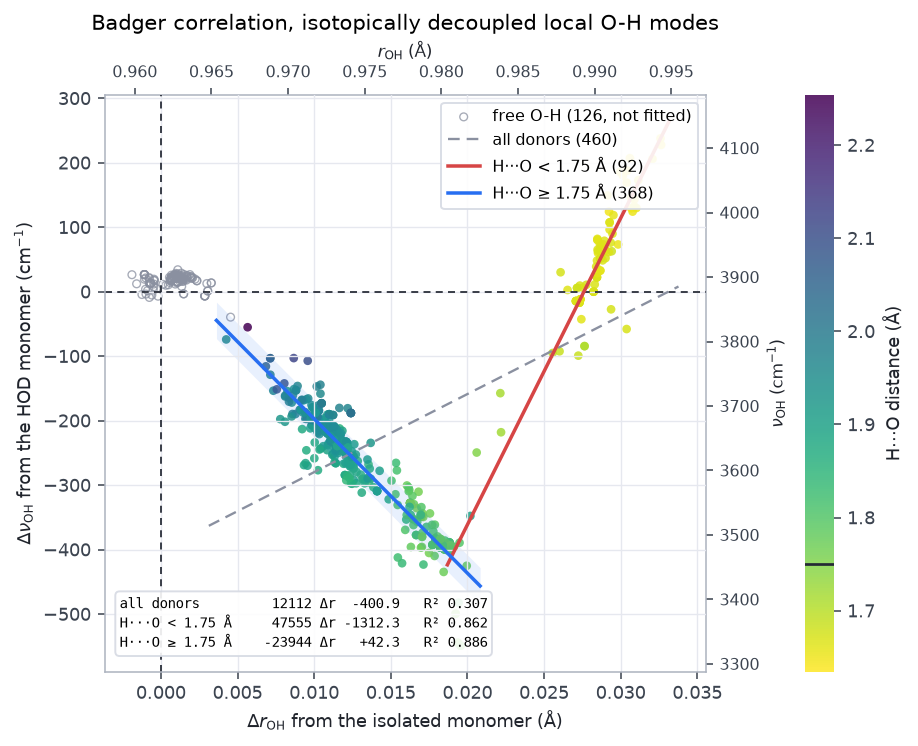

In [298]:
# ---- Badger correlation from the decoupled local O-H modes -----------------------------
def load_local_modes(path=LOCAL_MODES_CSV):
    """The per-O-H table `scripts/badger_analysis.py` writes, as arrays.

    One row per O-H bond, each frequency taken from a Hessian re-diagonalized with every
    *other* hydrogen mass-substituted, so the mode is a genuine local oscillator rather than a
    delocalized cluster stretch. That distinction is the whole reason this plot is readable:
    assigning normal modes to bonds gives R2 = 0.22 on the same structures, and essentially
    all of that loss is delocalization rather than model error.
    """
    with open(path, newline="") as handle:
        rows = list(csv.DictReader(handle))
    columns = {
        "dr": "delta_r_oh_angstrom", "dnu": "delta_frequency_cm1",
        "r": "r_oh_angstrom", "nu": "local_frequency_cm1",
        "d_hbond": "h_bond_o_distance_angstrom", "angle": "h_bond_angle_degrees",
        "localization": "localization",
    }
    data = {k: np.array([float(row[c]) for row in rows]) for k, c in columns.items()}
    data["donor"] = np.array([int(row["is_donor"]) for row in rows], dtype=bool)
    data["n_waters"] = np.array([int(row["n_waters"]) for row in rows])
    data["label"] = np.array([row["label"] for row in rows])
    return data


def badger_fit(dr, dnu):
    """Least squares through one population, with the scatter it leaves behind."""
    if dr.size < 3:
        return {"n": int(dr.size), "slope": np.nan, "intercept": np.nan,
                "r2": np.nan, "rms": np.nan}
    slope, intercept = np.polyfit(dr, dnu, 1)
    residual = dnu - (slope * dr + intercept)
    return {
        "n": int(dr.size), "slope": float(slope), "intercept": float(intercept),
        "r2": float(1.0 - residual.var() / dnu.var()),
        "rms": float(np.sqrt((residual**2).mean())),
    }


def badger_populations(data, short_cutoff=SHORT_HBOND_CUTOFF):
    """The three fits: every donor, and the two sides of the H...O cutoff.

    Splitting on the hydrogen-bond length rather than on anything about the frequency keeps the
    partition a statement about *geometry*, so the two fits stay independent tests rather than
    two halves of a curve cut where it bends. Which side is the interesting one depends on what
    the model is doing: here the short-H...O population is the group that has broken away from
    the line, and the cutoff is a knob precisely because where it breaks away is the thing being
    measured.
    """
    donor = data["donor"]
    short = donor & (data["d_hbond"] < short_cutoff)
    long = donor & (data["d_hbond"] >= short_cutoff)
    return {
        "all donors": (donor, badger_fit(data["dr"][donor], data["dnu"][donor])),
        f"H···O < {short_cutoff:g} Å": (short, badger_fit(data["dr"][short], data["dnu"][short])),
        f"H···O ≥ {short_cutoff:g} Å": (long, badger_fit(data["dr"][long], data["dnu"][long])),
    }


def plot_badger(data, short_cutoff=SHORT_HBOND_CUTOFF, path=None):
    """Frequency shift against bond-length shift, fitted over the hydrogen-bonded O-H only.

    Free O-H is drawn and not fitted. A non-donating O-H is a monomer, so those points sit in a
    knot at the origin by construction and would inflate R2 without saying anything about the
    slope; keeping them visible is the check that they land where they must.

    Three fit lines, each over its own population's range: the whole donor set in grey, and the
    two sides of `short_cutoff` in colour. The grey line is what a single fit through all
    hydrogen-bonded O-H claims; the two coloured ones are whether that claim survives being
    asked separately about weak and strong hydrogen bonds.
    """
    populations = badger_populations(data, short_cutoff)
    free = ~data["donor"]
    r_0 = float(np.mean(data["r"] - data["dr"]))
    nu_0 = float(np.mean(data["nu"] - data["dnu"]))

    fig, ax = plt.subplots(figsize=(6.8, 5.4))
    ax.scatter(data["dr"][free], data["dnu"][free], s=16, lw=0.7, alpha=0.75,
               facecolor="none", edgecolor="#8a90a0",
               label=f"free O-H ({int(free.sum())}, not fitted)")
    points = ax.scatter(data["dr"][data["donor"]], data["dnu"][data["donor"]],
                        c=data["d_hbond"][data["donor"]], s=20, lw=0, alpha=0.85,
                        cmap="viridis_r")
    bar = fig.colorbar(points, ax=ax, pad=0.12)
    bar.set_label("H$\\cdots$O distance (Å)")
    bar.outline.set_visible(False)
    bar.ax.axhline(short_cutoff, color="#242934", lw=1.4)

    styles = {0: ("#8a90a0", 1.2, (0, (5, 3))), 1: ("#d64545", 1.8, "-"),
              2: ("#276ef1", 1.8, "-")}
    for index, (name, (mask, fit)) in enumerate(populations.items()):
        if not np.isfinite(fit["slope"]):
            continue
        color, width, dashes = styles[index]
        pad = 0.04 * (np.ptp(data["dr"][mask]) or 0.01)
        span = np.array([data["dr"][mask].min() - pad, data["dr"][mask].max() + pad])
        ax.plot(span, fit["slope"] * span + fit["intercept"], color=color, lw=width,
                ls=dashes, label=f"{name} ({fit['n']})", zorder=3)
        if index == 2:
            line = fit["slope"] * span + fit["intercept"]
            ax.fill_between(span, line - fit["rms"], line + fit["rms"], color=color,
                            alpha=0.10, lw=0)

    ax.axhline(0.0, color="#242934", lw=0.9, ls=(0, (4, 3)))
    ax.axvline(0.0, color="#242934", lw=0.9, ls=(0, (4, 3)))
    table = "\n".join(
        f"{name:<15s} {fit['slope']:>8.0f} Δr {fit['intercept']:>+7.1f}   R² {fit['r2']:.3f}"
        for name, (_m, fit) in populations.items() if np.isfinite(fit["slope"])
    )
    ax.text(0.025, 0.035, table, transform=ax.transAxes, ha="left", va="bottom",
            fontsize=7.4, family="monospace",
            bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "#d6dae3", "alpha": 0.9})
    ax.set_xlabel("$\\Delta r_{\\mathrm{OH}}$ from the isolated monomer (Å)")
    ax.set_ylabel("$\\Delta\\nu_{\\mathrm{OH}}$ from the HOD monomer (cm$^{-1}$)")
    ax.set_title("Badger correlation, isotopically decoupled local O-H modes")
    ax.legend(loc="upper right", fontsize=8.2, frameon=True, facecolor="white",
              edgecolor="#d6dae3", framealpha=0.9)

    # Absolute scales on the far axes: the same data, read as r_OH and nu rather than shifts.
    top = ax.secondary_xaxis("top", functions=(lambda v: v + r_0, lambda v: v - r_0))
    top.set_xlabel("$r_{\\mathrm{OH}}$ (Å)", fontsize=8.5)
    top.tick_params(labelsize=8)
    right = ax.secondary_yaxis("right", functions=(lambda v: v + nu_0, lambda v: v - nu_0))
    right.set_ylabel("$\\nu_{\\mathrm{OH}}$ (cm$^{-1}$)", fontsize=8.5)
    right.tick_params(labelsize=8)

    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig, populations


local_modes = load_local_modes()
fig, badger = plot_badger(local_modes, short_cutoff=SHORT_HBOND_CUTOFF,
                          path=FIGDIR / f"{FIGPREFIX}_badger_correlation.png")
print(f"monomer reference: r_OH = {np.mean(local_modes['r'] - local_modes['dr']):.5f} A, "
      f"HOD nu = {np.mean(local_modes['nu'] - local_modes['dnu']):.2f} cm^-1      "
      f"lowest localization {local_modes['localization'].min():.4f}")
for name, (_mask, fit) in badger.items():
    print(f"  {name:<16s} n = {fit['n']:4d}   slope = {fit['slope']:9.0f} cm^-1/A   "
          f"R^2 = {fit['r2']:.4f}   RMS = {fit['rms']:5.1f} cm^-1")
plt.show()

## Notes

- To regenerate these diagnostics for a different model, edit `COMMITTEE` (and, to change which
  member drives the figures, `COMMITTEE_MEMBER`) at the top. Each member is rebuilt from the
  config its own checkpoint carries, so there is no stage to select and no way for the notebook
  to build something other than what the weights came from. Figure names carry both the
  committee directory and the member index, so two runs do not overwrite each other.
- `committee_members` resolves a manifest, then `member_NN/<stage>/best.pt`, then
  `member_NN/best.pt`. The nested form is what a **staged** fit writes, and the last sorted
  stage per member is the fitted one -- `_full` sorts after `_isolated`, which is the point:
  an `_isolated` checkpoint has an untrained environment path and would read as a bad fit
  rather than as the wrong file. `Committee.load` in the active-learning package only globs
  the flat form, so it cannot load a staged committee directory without a manifest.
- **`environment_off` needs two switches in this model** -- zeroing the env/cross embedders
  makes the joined trunk latent equal the isolated one, and suppressing the gate kills the
  bonded delta branch, which reads the (now identical) latent through its own zero-init head
  times `g(a_env)`. The split cell asserts the iso run's `env_shift` is an exact zero, so a
  future env path that both switches miss fails loudly rather than skewing the bars.
- `elst` must show `env = 0`, and in the film model this is doubly structural: the permanent
  multipoles have no environment columns anywhere, and the penetration parameters are
  per-element tables. Pauli and dispersion should not be zero; that is their many-body
  content. Read panel (b) for how the share behaves with cluster size -- growth from w2 to w5
  is real many-body physics; a share already large on w2 means the environment sector is doing
  two-body work that belongs in `theta_0`, and `film.env_penalty_weight` is the dial.
- `induction` is one channel fitted against `eda_pol + eda_ct`. Its `bonded half` column is
  `E_bonded(theta) - E_bonded(theta_0)`: the part carried by the Morse/angle parameters
  shifting in the medium rather than by the coupled solve relaxing the multipoles. Both are
  physical -- the environment-dependence of bonding *is* the charge-transfer mechanism here,
  and pyCMM implements the same physics as its field-dependent Morse -- but if it is most of
  `env` while the solve contributes nothing, induction has become a network wearing the label.
  Two earlier charge-transfer channels failed exactly that way.
- The bonded-parameter figure is the film design's own readout. Three things to check on it:
  the dashed `theta_0` distributions should be *narrow* around their means (that is
  `bonded_variance_weight` working -- wide means the Morse "parameters" are absorbing PES
  error as a disguised pair energy); their means may sit off the gray pyCMM lines (the
  learnable tables moved, which is fine and printed at the top); and the dashed-to-filled gap
  should be small on w2-dominated distributions and grow with coordination.
- The compliance panel splits by endpoint pair. The O-H channels are the covalent charge-flow
  topology; the H-H channels sitting well below them is the model recovering the covalent
  graph from the complete intra-fragment enumeration, the `s -> 0` closure the SQE
  parameterization is built around.
- Monomer deformation and cluster binding energies use `REFERENCE_SPECIES` from
  `ISOLATED_SPECIES_REFERENCE` as the zero of energy. The same constant is subtracted from the
  reference and the prediction, so it shifts both axes and not the residuals.
- The Badger figure reads `LOCAL_MODES_CSV` rather than computing anything, because its input
  is a *relaxed* structure set: a Hessian at a non-stationary geometry has no harmonic meaning,
  so the geometries have to be optimized on this checkpoint first. The two script lines above
  the figure do that. Two numbers to read on it: the slope over the hydrogen-bonded O-H (the
  rule's own content) and the scatter about it. A right slope with wide scatter means `r_eq`
  and `k` are being generated independently rather than as one bond -- which is invisible in
  every energy panel in this notebook, since an O-H at the right length with the wrong
  curvature costs almost nothing at equilibrium.
